In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, initializers
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, accuracy_score,
                           precision_score, recall_score,
                           f1_score, roc_curve,
                           classification_report)
import matplotlib.pyplot as plt
import os
import time
import psutil

In [ ]:
test = pd.read_csv('/content/test.csv', sep = ';')
test.head()

,time,P1_B2004,P1_B2016,P1_B3004,P1_B3005,P1_B4002,P1_B4005,P1_B400B,P1_B4022,P1_FCV01D,...,P4_ST_FD,P4_ST_LD,P4_ST_PO,P4_ST_PS,P4_ST_PT01,P4_ST_TT01,attack,attack_P1,attack_P2,attack_P3
0,2019-10-29 11:00:00,0.0982,1.4610,461.9883,1099.7363,32.0,0.0,113.4112,35.9070,9.2526,...,-0.0027,355.4688,349.6998,0.0,10053.0,27629.0,0.0,0.0,0.0,0.0
1,2019-10-29 11:00:01,0.0982,1.4578,461.9883,1099.7363,32.0,0.0,116.3903,35.8990,9.2161,...,-0.0020,356.8432,349.8625,0.0,10053.0,27629.0,0.0,0.0,0.0,0.0
2,2019-10-29 11:00:02,0.0982,1.4666,461.9883,1099.7363,32.0,0.0,116.3903,35.9211,9.8404,...,-0.0019,357.1868,350.4413,0.0,10053.0,27629.0,0.0,0.0,0.0,0.0
3,2019-10-29 11:00:03,0.0982,1.4688,461.9883,1099.7363,32.0,0.0,74.6806,35.9264,9.9271,...,-0.0035,357.9825,350.6583,0.0,10053.0,27629.0,0.0,0.0,0.0,0.0
4,2019-10-29 11:00:04,0.0982,1.4717,461.9883,1099.7363,32.0,0.0,67.7290,35.9337,9.8901,...,0.0018,358.2176,352.4487,0.0,10053.0,27629.0,0.0,0.0,0.0,0.0


In [ ]:
train = pd.read_csv('/content/train.csv')

train.head(), test.head()

(                  time  P1_B2004  P1_B2016  P1_B3004   P1_B3005  P1_B4002  \
 0  2019-09-11 20:00:00    0.0983    1.0702  399.2321  1110.3986      32.0   
 1  2019-09-11 20:00:01    0.0983    1.0699  399.2321  1110.3986      32.0   
 2  2019-09-11 20:00:02    0.0983    1.0703  399.2321  1110.3986      32.0   
 3  2019-09-11 20:00:03    0.0983    1.0719  399.2321  1110.3986      32.0   
 4  2019-09-11 20:00:04    0.0983    1.0710  399.2321  1110.3986      32.0   
 
    P1_B4005  P1_B400B  P1_B4022  P1_FCV01D  ...  P4_ST_FD  P4_ST_LD  P4_ST_PO  \
 0       0.0   28.9981   35.7395        0.0  ...   -0.0004  330.6568  328.9388   
 1       0.0   29.9914   35.7388        0.0  ...   -0.0012  330.2228  329.3728   
 2       0.0   27.0122   35.7399        0.0  ...    0.0018  332.0493  329.7526   
 3       0.0   32.9705   35.7452        0.0  ...    0.0033  331.5249  331.0547   
 4       0.0   30.9843   35.7422        0.0  ...    0.0015  333.1706  331.1631   
 
    P4_ST_PS  P4_ST_PT01  P4_ST_TT01

In [ ]:
train['attack'].value_counts(), test['attack'].value_counts()
#[col for col in train.columns if 'attack' in col]

(attack
 0.0    88413
 Name: count, dtype: int64,
 attack
 0.0    85062
 1.0     2889
 Name: count, dtype: int64)

In [ ]:
train = train.drop(columns=[col for col in train.columns if "attack" in col], errors='ignore')
train.head()

,time,P1_B2004,P1_B2016,P1_B3004,P1_B3005,P1_B4002,P1_B4005,P1_B400B,P1_B4022,P1_FCV01D,...,P4_HT_LD,P4_HT_PO,P4_HT_PS,P4_LD,P4_ST_FD,P4_ST_LD,P4_ST_PO,P4_ST_PS,P4_ST_PT01,P4_ST_TT01
0,2019-09-11 20:00:00,0.0983,1.0702,399.2321,1110.3986,32.0,0.0,28.9981,35.7395,0.0,...,64.4604,57.8704,0.0,395.0195,-0.0004,330.6568,328.9388,50.9871,9973.0,27629.0
1,2019-09-11 20:00:01,0.0983,1.0699,399.2321,1110.3986,32.0,0.0,29.9914,35.7388,0.0,...,64.7208,58.4853,0.0,398.3109,-0.0012,330.2228,329.3728,50.9871,9973.0,27629.0
2,2019-09-11 20:00:02,0.0983,1.0703,399.2321,1110.3986,32.0,0.0,27.0122,35.7399,0.0,...,64.9450,59.2629,0.0,397.8768,0.0018,332.0493,329.7526,50.9871,9973.0,27629.0
3,2019-09-11 20:00:03,0.0983,1.0719,399.2321,1110.3986,32.0,0.0,32.9705,35.7452,0.0,...,65.1620,59.8235,0.0,398.6364,0.0033,331.5249,331.0547,50.9871,9973.0,27629.0
4,2019-09-11 20:00:04,0.0983,1.0710,399.2321,1110.3986,32.0,0.0,30.9843,35.7422,0.0,...,65.4369,60.3118,0.0,401.2406,0.0015,333.1706,331.1631,50.9871,9973.0,27629.0


In [ ]:
train.fillna(0, inplace=True)
#test.fillna(0, inplace=True)

In [ ]:
test.head()
test[['attack', 'attack_P1', 'attack_P2', 'attack_P3']].value_counts()
#test.groupby('attack')[['attack_P1', 'attack_P2', 'attack_P3']].apply(lambda x: x.value_counts())

,,,,count
attack,attack_P1,attack_P2,attack_P3,
0.0,0.0,0.0,0.0,85062
1.0,1.0,0.0,0.0,2889


In [ ]:
# Re-read test.csv to ensure a clean state for the operation if needed,
# although based on the flow, the 'test' variable should still hold the
# concatenated DataFrame. Let's assume the existing 'test' DataFrame is correct
# up to the point before dropping columns from train.

# Find all columns containing "attack"
attack_p_columns = [col for col in test.columns if "attack_P" in col]

# Initialize a new 'attack' column with 0.
# This column will store the binarized result.
# Using .copy() to avoid SettingWithCopyWarning if test was a slice
test = test.copy()
test['attack'] = 0

# Iterate through the attack_P columns.
# If any of the attack_P columns has a non-zero value in a row,
# set the new 'attack' column for that row to 1.
for col in attack_p_columns:
    # Use vectorized operation or .loc for efficiency
    test.loc[test[col] != 0, 'attack'] = 1

# Now drop the original 'attack_P' columns
test = test.drop(columns=attack_p_columns, errors='ignore')

# You can optionally also drop the original 'attack' column if it existed before
# and you want to ensure you only have the newly created one.
# Based on the error, it likely didn't exist, but good practice.
# test = test.drop(columns=['attack'], errors='ignore') # Uncomment if needed

# Check the result
print(test[['attack']].value_counts())
print(test.head())

attack
0         48636
1          1690
Name: count, dtype: int64
                  time  P1_B2004  P1_B2016  P1_B3004   P1_B3005  P1_B4002  \
0  2019-10-29 11:00:00    0.0982    1.4610  461.9883  1099.7363      32.0   
1  2019-10-29 11:00:01    0.0982    1.4578  461.9883  1099.7363      32.0   
2  2019-10-29 11:00:02    0.0982    1.4666  461.9883  1099.7363      32.0   
3  2019-10-29 11:00:03    0.0982    1.4688  461.9883  1099.7363      32.0   
4  2019-10-29 11:00:04    0.0982    1.4717  461.9883  1099.7363      32.0   

   P1_B4005  P1_B400B  P1_B4022  P1_FCV01D  ...  P4_HT_PO  P4_HT_PS     P4_LD  \
0       0.0  113.4112   35.9070     9.2526  ...   67.2924       0.0  426.6312   
1       0.0  116.3903   35.8990     9.2161  ...   67.6722       0.0  426.5046   
2       0.0  116.3903   35.9211     9.8404  ...   67.9073       0.0  427.9875   
3       0.0   74.6806   35.9264     9.9271  ...   68.1605       0.0  427.0110   
4       0.0   67.7290   35.9337     9.8901  ...   68.4678       0.0

In [ ]:
test.columns

Index(['time', 'P1_B2004', 'P1_B2016', 'P1_B3004', 'P1_B3005', 'P1_B4002',
       'P1_B4005', 'P1_B400B', 'P1_B4022', 'P1_FCV01D', 'P1_FCV01Z',
       'P1_FCV02D', 'P1_FCV02Z', 'P1_FCV03D', 'P1_FCV03Z', 'P1_FT01',
       'P1_FT01Z', 'P1_FT02', 'P1_FT02Z', 'P1_FT03', 'P1_FT03Z', 'P1_LCV01D',
       'P1_LCV01Z', 'P1_LIT01', 'P1_PCV01D', 'P1_PCV01Z', 'P1_PCV02D',
       'P1_PCV02Z', 'P1_PIT01', 'P1_PIT02', 'P1_TIT01', 'P1_TIT02', 'P2_24Vdc',
       'P2_Auto', 'P2_Emgy', 'P2_On', 'P2_SD01', 'P2_SIT01', 'P2_TripEx',
       'P2_VT01e', 'P2_VXT02', 'P2_VXT03', 'P2_VYT02', 'P2_VYT03', 'P3_LCP01D',
       'P3_LCV01D', 'P3_LH', 'P3_LL', 'P3_LT01', 'P4_HT_FD', 'P4_HT_LD',
       'P4_HT_PO', 'P4_HT_PS', 'P4_LD', 'P4_ST_FD', 'P4_ST_LD', 'P4_ST_PO',
       'P4_ST_PS', 'P4_ST_PT01', 'P4_ST_TT01', 'attack'],
      dtype='object')

In [ ]:
'''constant features = P1_PCV02D, P2_VTR01, P2_VTR04, P4_HT_PS, P1_PP02D
P4_ST_PS, P1_PP02R, P2_MSD, P2_VTR03, P2_TripEx, P1_STSP
P2_VTR02, P1_FCV02D, P3_LL, P2_AutoGo, P1_PP01BD, P3_LH
P1_PP01AD, P1_PP01AR, P2_OnOff, P2_RTR, P2_ManualGo'''

In [ ]:
def load_and_preprocess_data(train_df, test_df, sample_size=None):
    """Veriyi yükleyip ön işleme yapar"""
    print("📥 Veri yükleniyor ve ön işleme yapılıyor...")

    train_df = train.copy()
    test_df = test.copy()

    # Identify columns present in both dataframes for consistent processing
    common_cols = list(set(train_df.columns) & set(test_df.columns))

    # 1. Zaman damgası işleme ve özellik çıkarımı
    print("2. Zaman damgası özellikleri çıkarılıyor...")
    for df in [train_df, test_df]:
        if 'Timestamp' in df.columns:
            print("  Timestamp sütunu işleniyor...")
            # Önce string olan zaman damgasını datetime'a çevir
            # errors='coerce' kullanarak dönüşemeyen değerleri NaT yapar
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

            # Yeni zaman özelliklerini ekle, NaT değerleri için NaN oluşur
            # isnat().any() ile kontrol etmeden özellik çıkarımı yapın, NaT'ler NaN olur
            df['Hour'] = df['Timestamp'].dt.hour
            df['Day'] = df['Timestamp'].dt.dayofweek
            df['Minute'] = df['Timestamp'].dt.minute
            df['Second'] = df['Timestamp'].dt.second

            # Orijinal zaman damgasını sil
            df.drop('Timestamp', axis=1, inplace=True)

            # Oluşan NaN değerleri doldur (örn: 0 veya ortalama)
            # Zaman özelliklerindeki NaN'leri 0 ile doldurmak güvenli olabilir.
            df.fillna({'Hour': 0, 'Day': 0, 'Minute': 0, 'Second': 0}, inplace=True)


    # 2. Kategorik değişkenleri kontrol et ve dönüştür / Sayısal olmayan sütunları işle
    print("3. Sayısal olmayan sütunlar işleniyor...")
    for df in [train_df, test_df]:
        object_cols = df.select_dtypes(include='object').columns
        for col in object_cols:
            print(f"  Sütun '{col}' işleniyor...")
            # Try to convert to numeric
            df[col] = pd.to_numeric(df[col], errors='coerce') # Dönüşemeyenleri NaN yap

            # If there are still non-numeric values (NaNs from coerce or original non-numeric objects)
            if df[col].isna().any() or df[col].dtype == 'object': # 'object' type check is redundant after coerce but safe
                 print(f"    '{col}' sütununda sayısal olmayan değerler veya dönüştürme hatası var.")
                 # Option 1: Try one-hot encoding if it's truly categorical (risky if many unique values)
                 # print(f"    '{col}' sütunu için one-hot encoding deneniyor...")
                 # try:
                 #    df = pd.get_dummies(df, columns=[col], prefix=[col], dummy_na=False) # dummy_na=False is default
                 # except Exception as e:
                 #    print(f"    Hata: One-hot encoding sırasında hata oluştu: {e}. Sütun siliniyor.")
                 #    df.drop(col, axis=1, inplace=True)
                 # Option 2: Drop the column if it cannot be converted to numeric and isn't suitable for one-hot encoding
                 print(f"    '{col}' sütunu sayısal hale getirilemedi veya işlenemedi. Sütun siliniyor.")
                 df.drop(col, axis=1, inplace=True)
            else:
                 # Fill NaNs that resulted from pd.to_numeric(errors='coerce')
                 # Choose an appropriate fill value, e.g., 0, mean, or median
                 print(f"    '{col}' sütunu sayısal hale getirildi. NaN değerleri dolduruluyor (0 ile).")
                 df[col].fillna(0, inplace=True)


    # Ensure both dataframes have the same columns after processing
    processed_common_cols = list(set(train_df.columns) & set(test_df.columns))
    train_df = train_df[processed_common_cols]



    # 3. Özellikler ve etiketler
    print("4. Özellikler ve etiketler ayrılıyor...")

    # Define feature columns: all columns except 'attack' if present
    feature_cols = [c for c in train_df.columns if c != 'attack']

    # Ensure test_df contains 'attack' before trying to access it
    if 'attack' not in test_df.columns:
         # Check if 'attack' was accidentally dropped or never existed in test_df copy
         # based on previous steps. This should not happen if the initial 'test' df had it.
         # Re-check the preceding cells or data loading process if this error occurs.
         raise ValueError("Test verisinde 'attack' sütunu bulunamadı. Lütfen veri yükleme ve ön işleme adımlarını kontrol edin.")

    # Filter test_df feature columns to match train_df feature columns
    # This is crucial if get_dummies or dropping columns resulted in different sets
    test_feature_cols = [c for c in test_df.columns if c != 'attack']
    # Only keep features present in BOTH train and test after processing
    final_feature_cols = list(set(feature_cols) & set(test_feature_cols))

    # Ensure the order of columns is the same
    final_feature_cols.sort() # Sort to ensure consistent column order

    X_train = train_df[final_feature_cols].values
    X_test = test_df[final_feature_cols].values
    y_test = test_df['attack'].values.ravel()

    # 4. İsteğe bağlı örnekleme
    if sample_size:
        print(f"⚠️ Veri {sample_size} örneğe indirgeniyor")
        X_train = X_train[:sample_size]
        X_test = X_test[:sample_size//3]
        y_test = y_test[:sample_size//3]

    # 5. Ölçeklendirme
    print("5. Veri ölçeklendiriliyor...")
    scaler = MinMaxScaler(feature_range=(-1, 1))

    # Check for columns with single unique value (constant columns) in X_train
    # MinMaxScaler cannot handle features with zero variance.
    variances = np.var(X_train, axis=0)
    constant_features_indices = np.where(variances == 0)[0]

    if len(constant_features_indices) > 0:
        constant_col_names = [final_feature_cols[i] for i in constant_features_indices]
        print(f"⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: {constant_col_names}")
        print("   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...")

        # Create masks to remove constant columns
        non_constant_features_mask = np.ones(X_train.shape[1], dtype=bool)
        non_constant_features_mask[constant_features_indices] = False

        X_train = X_train[:, non_constant_features_mask]
        X_test = X_test[:, non_constant_features_mask]
        final_feature_cols = [final_feature_cols[i] for i in np.where(non_constant_features_mask)[0]]
        print(f"   Kalan özellik sayısı: {X_train.shape[1]}")


    X_train = scaler.fit_transform(X_train)
    # Ensure X_test is transformed using the scaler fitted on X_train
    X_test = scaler.transform(X_test)

    # Veri istatistikleri
    print("\n📊 Veri İstatistikleri:")
    print(f"Eğitim: {X_train.shape}")
    print(f"Test: {X_test.shape} (Norm: {sum(y_test==0)}, Atk: {sum(y_test==1)})")
    print(f"Özellikler: {len(final_feature_cols)}\n")

    return X_train, X_test, y_test, final_feature_cols, scaler

In [ ]:
X_train, X_test, y_test, final_feature_cols, scaler = load_and_preprocess_data(train, test)

📥 Veri yükleniyor ve ön işleme yapılıyor...
2. Zaman damgası özellikleri çıkarılıyor...
3. Sayısal olmayan sütunlar işleniyor...
  Sütun 'time' işleniyor...
    'time' sütununda sayısal olmayan değerler veya dönüştürme hatası var.
    'time' sütunu sayısal hale getirilemedi veya işlenemedi. Sütun siliniyor.
  Sütun 'time' işleniyor...
    'time' sütununda sayısal olmayan değerler veya dönüştürme hatası var.
    'time' sütunu sayısal hale getirilemedi veya işlenemedi. Sütun siliniyor.
4. Özellikler ve etiketler ayrılıyor...
5. Veri ölçeklendiriliyor...
⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: ['P1_B4002', 'P2_Emgy', 'P2_TripEx', 'P4_HT_PS']
   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...
   Kalan özellik sayısı: 55

📊 Veri İstatistikleri:
Eğitim: (49790, 55)
Test: (50326, 55) (Norm: 48636, Atk: 1690)
Özellikler: 55



In [ ]:
# ==================== GÜNCELLENMİŞ WGAN-GP MODELİ ====================
def build_generator(latent_dim, output_dim):
    """NaN-safe generator with weight initialization"""
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(128, activation='relu',
                   kernel_initializer=tf.keras.initializers.he_normal(),
                   kernel_constraint=tf.keras.constraints.max_norm(0.5)),
        layers.Dense(256, activation='relu',
                   kernel_initializer=tf.keras.initializers.he_normal(),
                   kernel_constraint=tf.keras.constraints.max_norm(0.5)),
        layers.Dense(512, activation='relu',
                   kernel_initializer=tf.keras.initializers.he_normal(),
                   kernel_constraint=tf.keras.constraints.max_norm(0.5)),
        layers.Dense(output_dim, activation='tanh',
                   kernel_initializer=tf.keras.initializers.glorot_uniform())
    ])
    return model

def build_discriminator(input_dim):
    """NaN-safe discriminator with gradient penalty support"""
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu',
                   kernel_initializer=tf.keras.initializers.he_normal(),
                   kernel_constraint=tf.keras.constraints.max_norm(0.5)),
        layers.Dense(256, activation='relu',
                   kernel_initializer=tf.keras.initializers.he_normal(),
                   kernel_constraint=tf.keras.constraints.max_norm(0.5)),
        layers.Dense(1, kernel_initializer=tf.keras.initializers.glorot_uniform())
    ])
    return model

def compute_gradient_penalty(real_samples, fake_samples, discriminator, batch_size):
    """NaN-safe gradient penalty computation"""
    # NaN kontrolü
    if np.isnan(real_samples).any() or np.isnan(fake_samples).any():
        raise ValueError("Gradient penalty hesaplanırken NaN değer tespit edildi!")

    alpha = tf.random.uniform([batch_size, 1], minval=0., maxval=1.)
    interpolated = alpha * real_samples + (1-alpha) * fake_samples

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        pred = discriminator(interpolated)

    gradients = tape.gradient(pred, interpolated)

    # NaN kontrolü ve küçük epsilon ekleme
    gradients_safe = tf.where(tf.math.is_nan(gradients), tf.zeros_like(gradients), gradients)
    gradients_norm = tf.sqrt(tf.reduce_sum(gradients_safe**2, axis=1) + 1e-10)

    return tf.reduce_mean((gradients_norm - 1.)**2)

# ==================== GÜNCELLENMİŞ EĞİTİM FONKSİYONU ====================
def train_wgan_gp(generator, discriminator, data, latent_dim=100,
                 epochs=1000, batch_size=64, n_critic=5, gp_weight=10):
    """NaN-safe WGAN-GP training"""

    # Optimizer ayarları (NaN'ı önlemek için düşük learning rate)
    opt_g = tf.keras.optimizers.Adam(5e-5, beta_1=0.5, beta_2=0.9, clipnorm=1.0)
    opt_d = tf.keras.optimizers.Adam(5e-5, beta_1=0.5, beta_2=0.9, clipnorm=1.0)

    # Veri kontrolü
    if np.isnan(data).any():
        raise ValueError("Eğitim verisinde NaN değerler bulundu!")

    # Kayıt defteri
    history = {'d_loss': [], 'g_loss': []}

    for epoch in range(epochs):
        # Discriminator eğitimi
        for _ in range(n_critic):
            # Gerçek örnekler
            idx = np.random.randint(0, data.shape[0], batch_size)
            real_samples = data[idx]

            # NaN kontrolü
            if np.isnan(real_samples).any():
                print("⚠️ Gerçek örneklerde NaN tespit edildi, bu batch atlanıyor...")
                continue

            # Gürültü üretimi (NaN kontrolü)
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            if np.isnan(noise).any():
                print("⚠️ Gürültüde NaN tespit edildi, yeniden oluşturuluyor...")
                noise = np.random.normal(0, 1, (batch_size, latent_dim))

            # Fake örnekler
            fake_samples = generator(noise, training=False)

            # NaN kontrolü
            if tf.math.is_nan(fake_samples).numpy().any():
                print("⚠️ Generator çıktısında NaN tespit edildi, bu batch atlanıyor...")
                continue

            # Discriminator güncelleme
            with tf.GradientTape() as tape:
                real_output = discriminator(real_samples, training=True)
                fake_output = discriminator(fake_samples, training=True)

                # WGAN loss
                d_loss = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output)

                # Gradient penalty (NaN kontrolü ile)
                try:
                    gp = compute_gradient_penalty(real_samples, fake_samples, discriminator, batch_size)
                    d_loss += gp_weight * gp
                except Exception as e:
                    print(f"⚠️ Gradient penalty hesaplanamadı: {str(e)}, sadece WGAN loss kullanılıyor")
                    gp = 0.0

                # NaN kontrolü
                if tf.math.is_nan(d_loss):
                    print("⚠️ Discriminator loss NaN oldu, bu batch atlanıyor...")
                    continue

            # Gradyan güncelleme (NaN kontrolü)
            grads = tape.gradient(d_loss, discriminator.trainable_variables)
            if any(g is None or tf.math.is_nan(g).numpy().any() for g in grads):
                print("⚠️ Discriminator gradyanlarında sorun tespit edildi, atlanıyor...")
                continue

            opt_d.apply_gradients(zip(grads, discriminator.trainable_variables))

        # Generator eğitimi
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        with tf.GradientTape() as tape:
            fake_samples = generator(noise, training=True)
            fake_output = discriminator(fake_samples, training=False)
            g_loss = -tf.reduce_mean(fake_output)

            # NaN kontrolü
            if tf.math.is_nan(g_loss):
                print("⚠️ Generator loss NaN oldu, bu batch atlanıyor...")
                continue

        # Gradyan güncelleme (NaN kontrolü)
        grads = tape.gradient(g_loss, generator.trainable_variables)
        if any(g is None or tf.math.is_nan(g).numpy().any() for g in grads):
            print("⚠️ Generator gradyanlarında sorun tespit edildi, atlanıyor...")
            continue

        opt_g.apply_gradients(zip(grads, generator.trainable_variables))

        # Kayıtları güncelle
        history['d_loss'].append(float(d_loss) if 'd_loss' in locals() else np.nan)
        history['g_loss'].append(float(g_loss) if 'g_loss' in locals() else np.nan)

        # İlerleme raporu
        if epoch % 100 == 0:
            avg_d_loss = np.nanmean(history['d_loss'][-100:])
            avg_g_loss = np.nanmean(history['g_loss'][-100:])
            print(f"Epoch {epoch}: Avg D loss = {avg_d_loss:.4f}, Avg G loss = {avg_g_loss:.4f}")

            # Örnek görselleştirme
            if data.shape[1] >= 2:
                plt.figure(figsize=(10,5))
                plt.scatter(data[:1000,0], data[:1000,1], alpha=0.5, label='Real')

                # NaN-safe sample generation
                try:
                    samples = generator.predict(np.random.normal(0,1,(1000,latent_dim)), verbose=0)
                    if not np.isnan(samples).any():
                        plt.scatter(samples[:,0], samples[:,1], alpha=0.5, label='Fake')
                    else:
                        print("⚠️ Görselleştirme için üretilen örneklerde NaN tespit edildi")
                except:
                    print("⚠️ Görselleştirme sırasında hata oluştu")

                plt.title(f"Epoch {epoch}")
                plt.legend()
                plt.show()

    return generator, discriminator, history

In [ ]:
X_train = np.nan_to_num(X_train, nan=0)
np.isnan(X_train).sum()

np.int64(0)

In [ ]:
# Verinizde NaN olmadığından emin olun
assert not np.isnan(X_train).any(), "Eğitim verisinde NaN değerler bulundu!"

In [ ]:
from tensorflow.keras.models import load_model

generator = load_model('/content/hai_wgan_generator.h5')
discriminator = load_model('/content/hai_wgan_discriminator.h5')

Epoch 0: Avg D loss = 6.5248, Avg G loss = -0.0263


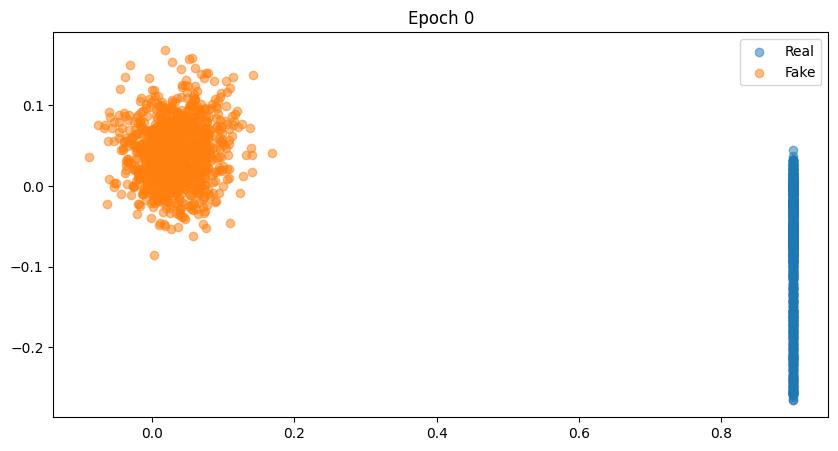

Epoch 100: Avg D loss = -3.4336, Avg G loss = -0.7500


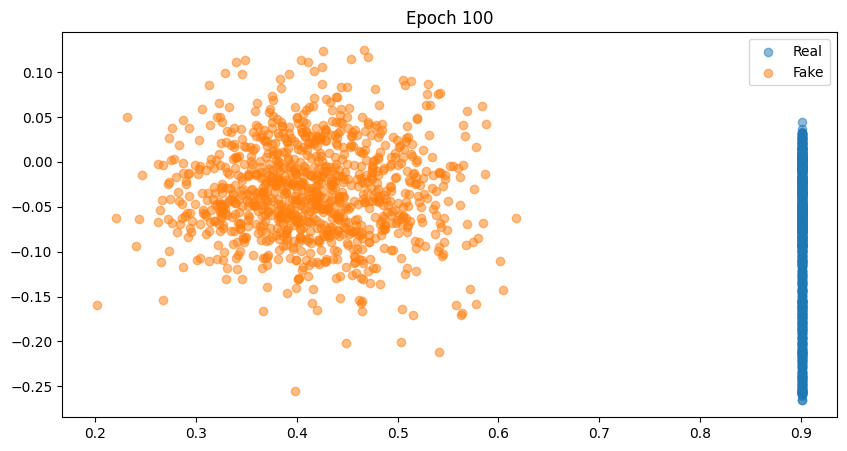

Epoch 200: Avg D loss = -3.8705, Avg G loss = -0.6868


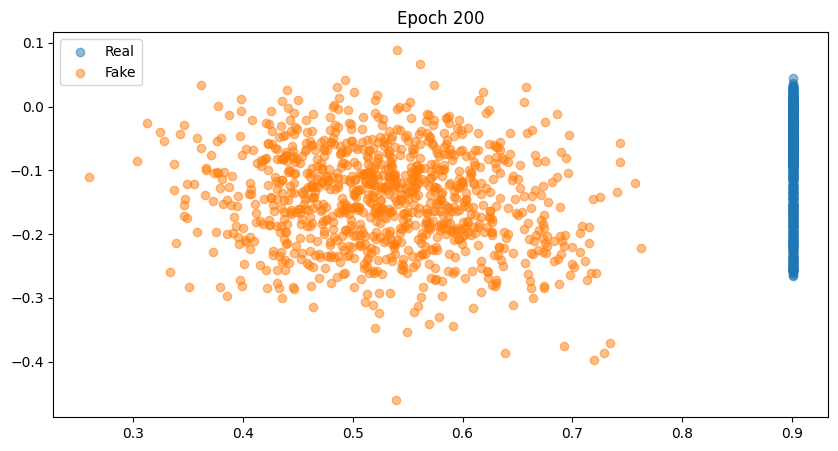

Epoch 300: Avg D loss = -3.6894, Avg G loss = -0.5248


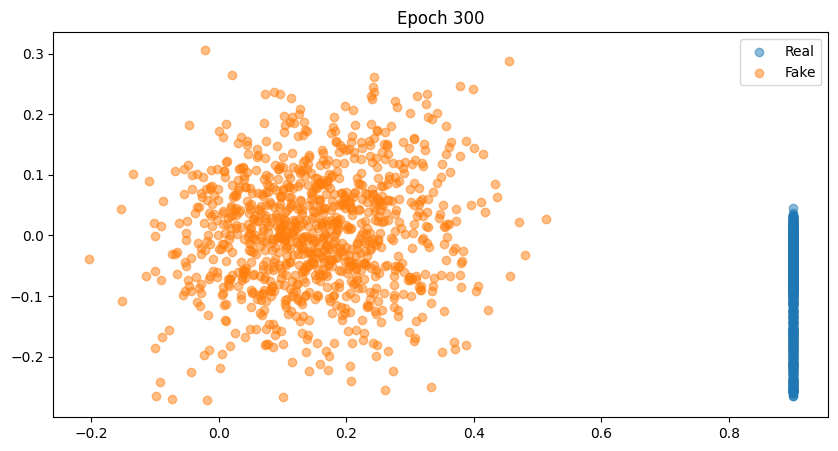

Epoch 400: Avg D loss = -3.5756, Avg G loss = -0.5340


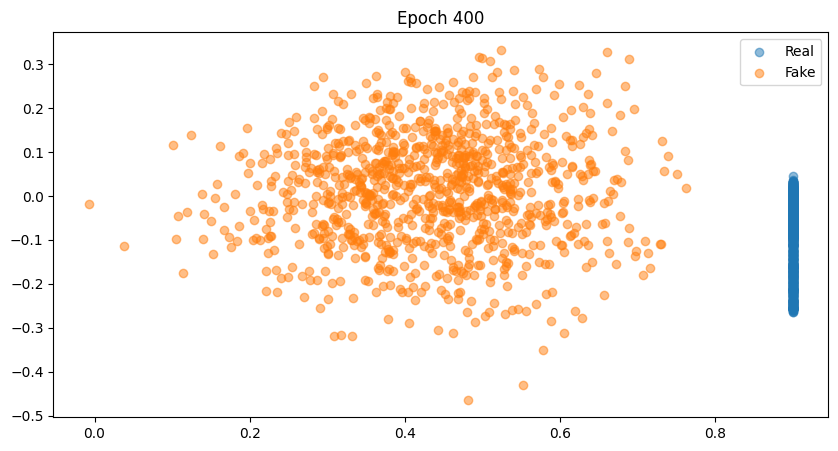

In [ ]:
# Daha küçük batch size ile başlayın
generator, discriminator, history = train_wgan_gp(
    generator, discriminator, X_train,
    latent_dim=latent_dim,
    epochs=500,
    batch_size=32,
    gp_weight=10
)

In [ ]:
generator.save('hai_wgan_generator.h5')
discriminator.save('hai_wgan_discriminator.h5')

In [ ]:
print("Original future shape:", scaler.n_features_in_)
print("Generator output shape:", generator.output_shape[1])
print("Scaler min_ shape:", len(scaler.min_))

Original future shape: 55
Generator output shape: 59
Scaler min_ shape: 55


In [ ]:
def generate_synthetic_samples(generator, num_samples, latent_dim=100, scaler=None, original_feature_count=None):
    """NaN-safe ve boyut uyumlu sentetik veri üretimi"""
    print(f"\n✨ {num_samples} adet sentetik örnek üretiliyor...")

    noise = tf.random.normal([num_samples, latent_dim])
    synthetic_data = generator.predict(noise, verbose=1)

    if scaler is not None:
        # Boyut uyumsuzluğu kontrolü
        if synthetic_data.shape[1] != scaler.n_features_in_:
            print(f"⚠️ Uyarı: Scaler {scaler.n_features_in_} özellik için eğitilmiş,"
                  f" ancak generator {synthetic_data.shape[1]} özellik üretiyor.")

            if original_feature_count:
                # Sadece orijinal özellikleri ters ölçeklendir
                synthetic_data = synthetic_data[:, :original_feature_count]
                synthetic_data = scaler.inverse_transform(synthetic_data)
                print(f"⚠️ İlk {original_feature_count} özellik ters ölçeklendirildi.")
            else:
                print("❌ Hata: Boyut uyumsuzluğu! Ters ölçeklendirme yapılamadı.")
                return synthetic_data  # Ölçeklendirilmemiş halde döndür
        else:
            synthetic_data = scaler.inverse_transform(synthetic_data)

    return synthetic_data

In [ ]:
# Orijinal özellik sayısını belirtin (X_train'in orijinal boyutu)
original_feature_count = X_train.shape[1]

# Sentetik veri üretme
synthetic_data = generate_synthetic_samples(
    generator,
    num_samples=len(X_train),
    latent_dim=128,
    scaler=scaler,
    original_feature_count=original_feature_count
)

# Üretilen veriyi kontrol
print("Üretilen veri boyutu:", synthetic_data.shape)


✨ 88414 adet sentetik örnek üretiliyor...
2763/2763 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
⚠️ Uyarı: Scaler 55 özellik için eğitilmiş, ancak generator 59 özellik üretiyor.
⚠️ İlk 55 özellik ters ölçeklendirildi.
Üretilen veri boyutu: (88414, 55)


In [ ]:
# Üretilen veriyi kontrol et
print("\n🔍 Sentetik Veri Örnekleri (İlk 5 satır):")
print(pd.DataFrame(synthetic_data[:5], columns=final_feature_cols))

print("\n📊 Sentetik Veri İstatistikleri:")
print(pd.DataFrame(synthetic_data).describe())

# Veriyi kaydet (opsiyonel)
pd.DataFrame(synthetic_data, columns=final_feature_cols).to_csv("hai_synthetic_data.csv", index=False)


🔍 Sentetik Veri Örnekleri (İlk 5 satır):
   P1_B2004  P1_B2016    P1_B3004     P1_B3005   P1_B4002   P1_B4005  \
0  0.082623  0.993000  406.820557  1094.556030  31.788500  59.732361   
1  0.095861  1.056291  404.722351  1088.358276  31.840931  71.064224   
2  0.088311  1.081001  402.656891  1084.268921  31.829575  64.443115   
3  0.093075  1.055580  404.614380  1089.929443  31.814617  53.265244   
4  0.077808  0.967584  404.724304  1094.365601  31.821026  50.090199   

      P1_B400B   P1_B4022  P1_FCV01D  P1_FCV01Z  ...  P4_HT_FD  P4_HT_LD  \
0  1642.858521  35.944302  55.548592  48.875412  ... -0.026491  0.831121   
1  1623.129028  36.228886  41.684380  51.308727  ... -0.026769  0.340852   
2  1913.330322  35.967457  56.555130  52.863686  ... -0.026679  0.745673   
3  1605.598633  35.967022  51.728451  43.052410  ... -0.026622  0.530823   
4  1848.283813  36.022606  46.607006  49.407856  ... -0.026661  0.740450   

    P4_HT_PO       P4_LD  P4_ST_FD    P4_ST_LD  P4_ST_PO   P4_ST_PS 

In [ ]:
synthetic_data = pd.read_csv("hai_synthetic_normal_data.csv")
synthetic_data.head()

,P1_B2004,P1_B2016,P1_B3004,P1_B3005,P1_B4002,P1_B4005,P1_B400B,P1_B4022,P1_FCV01D,P1_FCV01Z,...,P4_HT_FD,P4_HT_LD,P4_HT_PO,P4_LD,P4_ST_FD,P4_ST_LD,P4_ST_PO,P4_ST_PS,P4_ST_PT01,P4_ST_TT01
0,0.997896,-0.564893,-0.990997,0.995328,0.998501,-0.723730,-0.996584,0.934580,-0.971671,-0.999531,...,-0.349580,-0.555643,0.846714,0.965343,-0.999062,0.996552,0.999657,0.526308,0.997943,0.982399
1,0.923340,0.622928,-0.861324,0.697431,-0.380314,-0.242661,0.936379,0.372796,-0.948783,-0.984604,...,0.956376,-0.886111,-0.726168,0.760610,-0.923751,0.973809,0.215385,0.973164,0.953570,0.835977
2,0.999275,0.807724,-0.998647,0.998838,0.998827,-0.961789,-0.950366,0.970014,-0.994589,-0.999854,...,0.826629,-0.918123,0.386590,0.998020,-0.996484,0.997431,0.998637,0.989354,0.992502,0.951713
3,-0.760321,-0.378705,-0.477522,-0.938396,-0.830747,-0.988746,0.976515,-0.193130,-0.152242,-0.329047,...,0.993460,0.998290,-0.559870,0.910420,-0.967416,-0.738934,-0.720256,-0.835757,-0.448720,-0.389735
4,-0.998957,-0.408767,0.989928,-0.999995,-0.998556,0.017446,0.999835,-0.977933,0.999986,0.996581,...,0.130886,-0.525137,-0.772373,-0.464831,0.994805,-0.998145,-0.999419,-0.993694,-0.996186,-0.995205


In [ ]:
# Üretilen veriyi kontrol et
print("\n🔍 Sentetik Veri Örnekleri (İlk 5 satır):")
print(pd.DataFrame(synthetic_data[:5], columns=final_feature_cols))

print("\n📊 Sentetik Veri İstatistikleri:")
print(pd.DataFrame(synthetic_data).describe())


🔍 Sentetik Veri Örnekleri (İlk 5 satır):
   P1_B2004  P1_B2016  P1_B3004  P1_B3005  P1_B4005  P1_B400B  P1_B4022  \
0  0.997896 -0.564893 -0.990997  0.995328 -0.723730 -0.996584  0.934580   
1  0.923340  0.622928 -0.861324  0.697431 -0.242661  0.936379  0.372796   
2  0.999275  0.807724 -0.998647  0.998838 -0.961789 -0.950366  0.970014   
3 -0.760321 -0.378705 -0.477522 -0.938396 -0.988746  0.976515 -0.193130   
4 -0.998957 -0.408767  0.989928 -0.999995  0.017446  0.999835 -0.977933   

   P1_FCV01D  P1_FCV01Z  P1_FCV02D  ...  P4_HT_FD  P4_HT_LD  P4_HT_PO  \
0  -0.971671  -0.999531  -0.938473  ... -0.349580 -0.555643  0.846714   
1  -0.948783  -0.984604   0.215121  ...  0.956376 -0.886111 -0.726168   
2  -0.994589  -0.999854  -0.266296  ...  0.826629 -0.918123  0.386590   
3  -0.152242  -0.329047   0.165278  ...  0.993460  0.998290 -0.559870   
4   0.999986   0.996581   0.213553  ...  0.130886 -0.525137 -0.772373   

      P4_LD  P4_ST_FD  P4_ST_LD  P4_ST_PO  P4_ST_PS  P4_ST_PT01  P4_

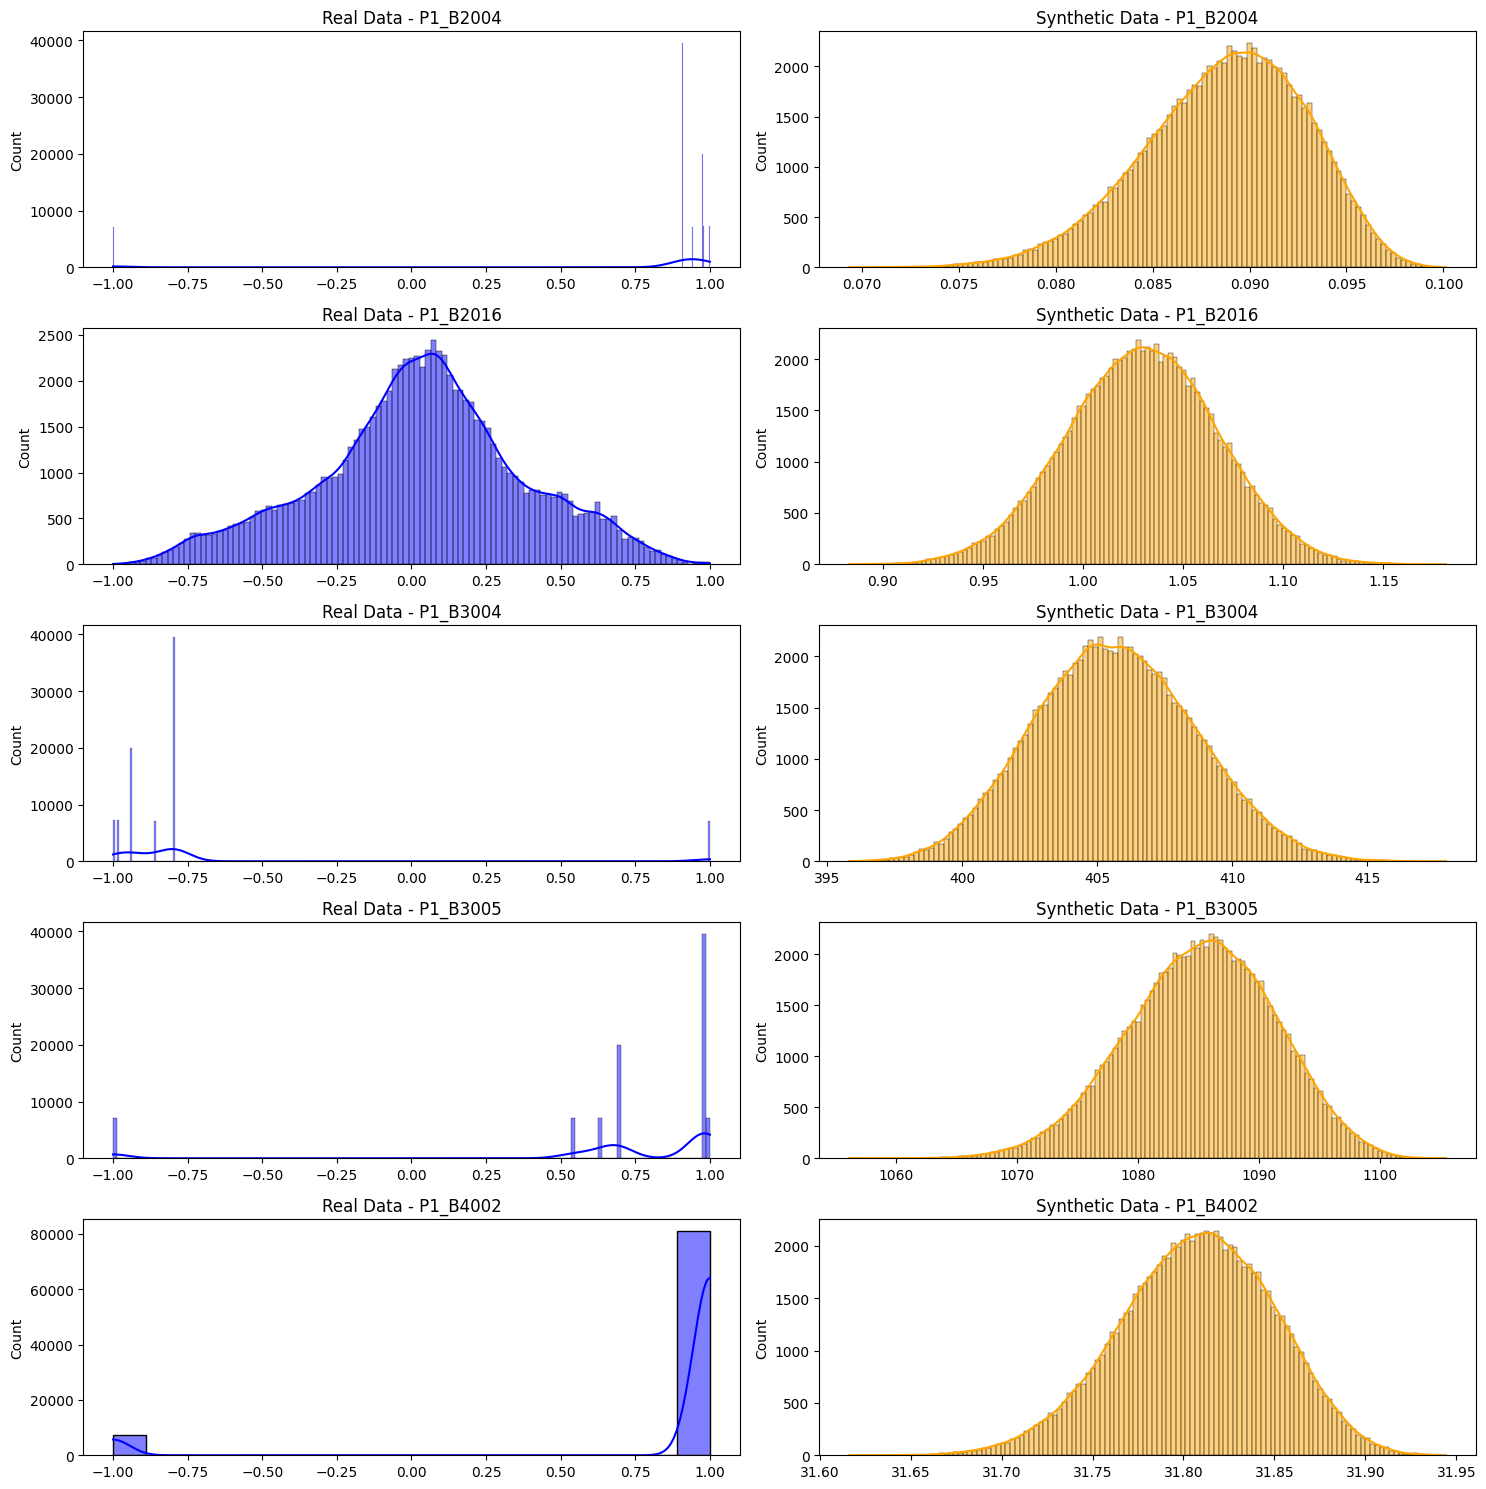

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veri dağılımını karşılaştırma
def compare_distributions(real_data, synthetic_data, feature_names, n_features=5):
    """Gerçek ve sentetik veri dağılımlarını karşılaştırır"""
    plt.figure(figsize=(15, 3*n_features))
    for i in range(min(n_features, real_data.shape[1])):
        plt.subplot(n_features, 2, 2*i+1)
        sns.histplot(real_data[:,i], kde=True, color='blue', label='Real')
        plt.title(f"Real Data - {feature_names[i]}")

        plt.subplot(n_features, 2, 2*i+2)
        sns.histplot(synthetic_data.values[:,i], kde=True, color='orange', label='Synthetic')
        plt.title(f"Synthetic Data - {feature_names[i]}")

    plt.tight_layout()
    plt.show()

# İlk 5 özelliğin dağılımını karşılaştır
compare_distributions(X_train, synthetic_data, final_feature_cols, n_features=5)

In [ ]:
# Veri kombinasyonlarını hazırla
real_data = X_train
real_synthetic = np.vstack([X_train, synthetic_data[:len(X_train)]])  # 1:1 oran
synthetic_only = synthetic_data[:len(X_train)]  # Orjinal veriyle aynı boyutta

# FL istemcileri için veri setleri
datasets = {
    "Real": real_data,
    "Real+Synthetic": real_synthetic,
    "Synthetic": synthetic_only
}

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 50 and the array at index 1 has size 55

FL Training Rounds:  20%|██        | 1/5 [00:14<00:57, 14.31s/it]


🔍 Round 1 Results:
Real            | AUC: 0.5583 | Precision: 0.937
Real+Synth      | AUC: 0.5687 | Precision: 0.937
Synthetic       | AUC: 0.5737 | Precision: 0.937


FL Training Rounds:  40%|████      | 2/5 [00:29<00:43, 14.65s/it]


🔍 Round 2 Results:
Real            | AUC: 0.5587 | Precision: 0.937
Real+Synth      | AUC: 0.5689 | Precision: 0.937
Synthetic       | AUC: 0.5738 | Precision: 0.937


FL Training Rounds:  60%|██████    | 3/5 [00:44<00:29, 14.74s/it]

...

FL Training Rounds:  80%|████████  | 4/5 [00:59<00:14, 14.93s/it]


🔍 Round 4 Results:
Real            | AUC: 0.5582 | Precision: 0.937
Real+Synth      | AUC: 0.5687 | Precision: 0.937
Synthetic       | AUC: 0.5736 | Precision: 0.937


FL Training Rounds: 100%|██████████| 5/5 [01:13<00:00, 14.69s/it]


🔍 Round 5 Results:
Real            | AUC: 0.5585 | Precision: 0.937
Real+Synth      | AUC: 0.5690 | Precision: 0.937
Synthetic       | AUC: 0.5735 | Precision: 0.937

🏆 Final Performance:



📊 Real Final Results:
AUC: 0.5585
              precision    recall  f1-score   support

           0       0.96      0.56      0.71     48636
           1       0.03      0.38      0.05      1690

    accuracy                           0.56     50326
   macro avg       0.50      0.47      0.38     50326
weighted avg       0.93      0.56      0.69     50326



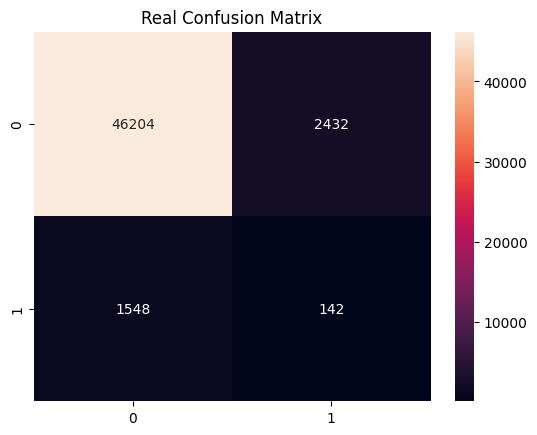


📊 Real+Synth Final Results:
AUC: 0.5690
              precision    recall  f1-score   support

           0       0.99      0.55      0.70     48636
           1       0.06      0.77      0.10      1690

    accuracy                           0.55     50326
   macro avg       0.52      0.66      0.40     50326
weighted avg       0.95      0.55      0.68     50326



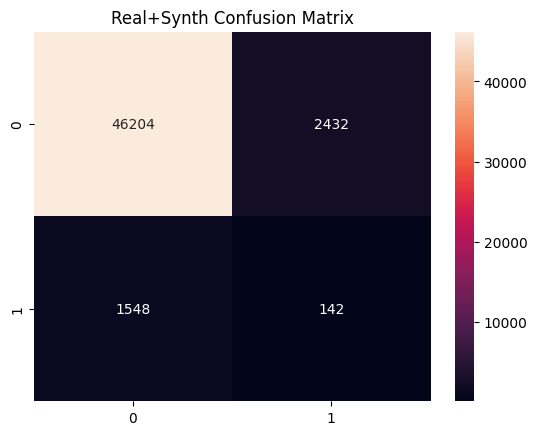


📊 Synthetic Final Results:
AUC: 0.5735
              precision    recall  f1-score   support

           0       0.99      0.48      0.64     48636
           1       0.05      0.85      0.10      1690

    accuracy                           0.49     50326
   macro avg       0.52      0.66      0.37     50326
weighted avg       0.96      0.49      0.62     50326



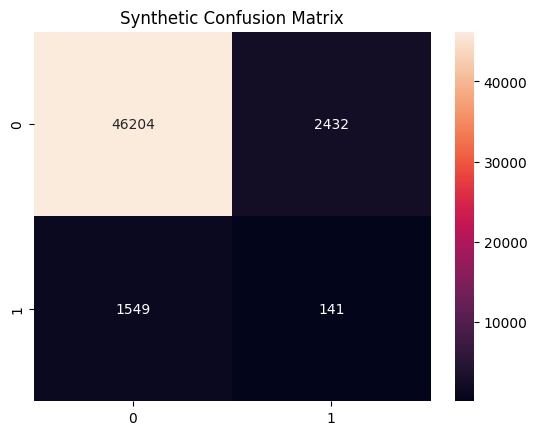

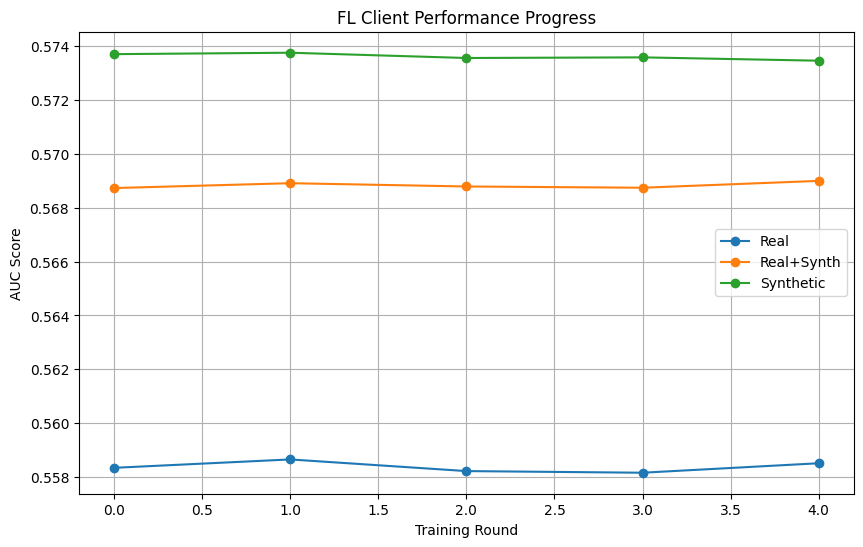

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, mean_squared_error,
                           classification_report, confusion_matrix, roc_curve)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd # pandas'ı import et

class FLClient:
    def __init__(self, name, data):
        self.name = name
        self.data = data
        # Verideki olası NaN/Inf değerlerini temizle
        self.data = np.nan_to_num(self.data, nan=0.0, posinf=0.0, neginf=0.0)
        self.model = OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
        self.sample_size = min(50000, len(data))  # Her turda kullanılacak maksimum örnek sayısı

    def train_round(self, sample_ratio=0.3):
        """Tek turda eğitim (verinin bir kısmını kullanarak)"""
        sample_size = int(self.sample_size * sample_ratio)
        indices = np.random.choice(len(self.data), size=sample_size, replace=False)
        # Eğitim verisinde de NaN/Inf kontrolü yapalım
        train_data_subset = np.nan_to_num(self.data[indices], nan=0.0, posinf=0.0, neginf=0.0)
        self.model.fit(train_data_subset)


    def evaluate(self, X_test, y_test):
        # Test verisinde de NaN/Inf kontrolü yapalım
        X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

        # NaN kontrolü sonrası skorları hesapla
        scores = -self.model.decision_function(X_test_clean)
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)  # Sıfıra bölme hatası önlemi

        # Ensure y_test is a numpy array
        y_test = np.asarray(y_test)

        # NaN içermeyen normal veri örneklerinin skorlarını bul
        scores_normal = scores_norm[y_test == 0]

        # Eğer scores_normal boşsa veya NaN içeriyorsa eşiği belirleyemeyiz
        if len(scores_normal) == 0 or np.isnan(scores_normal).all():
             print("⚠️ Normal veri örneklerinin skorları boş veya NaN içeriyor, eşik belirlenemedi.")
             # Varsayılan bir eşik kullan veya hata ver
             threshold = 0.5 # Örnek varsayılan eşik
             # Ya da daha güvenli bir yaklaşım:
             # raise ValueError("Normal veri skorları boş veya NaN, eşik belirlenemiyor.")
        else:
             # NaN olmayan skorlar üzerinden persentil hesapla
             scores_normal_clean = scores_normal[~np.isnan(scores_normal)]
             if len(scores_normal_clean) > 0:
                 threshold = np.percentile(scores_normal_clean, 95)
             else:
                 print("⚠️ Normal veri skorları NaN içeriyor ve temizlendikten sonra boş kaldı, eşik belirlenemedi.")
                 threshold = 0.5 # Yine varsayılan bir eşik


        pred = (scores_norm > threshold).astype(int)

        # NaN kontrolü sonrası metrikleri hesapla
        # classification_report ve confusion_matrix NaN input kabul etmez.
        # y_test ve pred'in NaN içermediğinden emin olun (astype(int) bunu sağlar, y_test zaten sayısal)
        cm = confusion_matrix(y_test, pred)
        report = classification_report(y_test, pred, output_dict=True)

        # Add the client's name to the returned dictionary
        return {
            'name': self.name, # Add client name here
            'scores': scores_norm,
            'auc': roc_auc_score(y_test, scores_norm),
            'cm': cm,
            'report': report
        }


def federated_training(clients, X_test, y_test, rounds=5):
    """Optimize edilmiş FL eğitim süreci"""
    history = {client.name: [] for client in clients}

    # X_test ve y_test'i başlangıçta temizleyelim
    X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
    y_test_clean = np.asarray(y_test) # Zaten numeric olmalı ama emin olalım

    for round in tqdm(range(rounds), desc="FL Training Rounds"):
        round_results = {}

        # Paralel eğitim (gerçek FL'de bu istemcilerde olurdu)
        for client in clients:
            client.train_round()
            # Temizlenmiş test verisini kullan
            results = client.evaluate(X_test_clean, y_test_clean)
            round_results[client.name] = results
            history[client.name].append(results['auc'])

        # Tur sonuçlarını göster
        print(f"\n🔍 Round {round+1} Results:")
        for name, res in round_results.items():
            # Access name from the res dictionary now
            print(f"{res['name']:<15} | AUC: {res['auc']:.4f} | "
                  f"Precision: {res['report']['weighted avg']['precision']:.3f}")

    return history

def visualize_fl_progress(history):
    """FL ilerlemesini görselleştirme"""
    plt.figure(figsize=(10, 6))
    for name, auc_scores in history.items():
        plt.plot(auc_scores, marker='o', label=name)

    plt.xlabel("Training Round")
    plt.ylabel("AUC Score")
    plt.title("FL Client Performance Progress")
    plt.legend()
    plt.grid()
    plt.show()

# İstemcileri oluştur (daha küçük veri boyutlarıyla)
# İstemcilere veri verirken de NaN/Inf temizliği yapalım
clients = [
    FLClient("Real", np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)),
    FLClient("Real+Synth", np.nan_to_num(np.vstack([X_train[:50000], synthetic_data[:50000]]), nan=0.0, posinf=0.0, neginf=0.0)),  # Eşit dağılım
    FLClient("Synthetic", np.nan_to_num(synthetic_data[:50000], nan=0.0, posinf=0.0, neginf=0.0))  # Sadece ilk 50k örnek
]

# FL eğitim süreci (5 tur)
# federated_training fonksiyonu zaten içerde temizliyor, burada ayrıca gerek yok
history = federated_training(clients, X_test, y_test, rounds=5)

# Final değerlendirme
print("\n🏆 Final Performance:")
for client in clients:
    # Temizlenmiş test verisini kullan
    results = client.evaluate(np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0), np.asarray(y_test))
    print(f"\n📊 {results['name']} Final Results:") # Access name from results dict
    print(f"AUC: {results['auc']:.4f}")
    # classification_report ve confusion_matrix'e temizlenmiş y_test ve pred ver
    print(classification_report(np.asarray(y_test), (results['scores'] > 0.5).astype(int)))

    # Confusion matrix
    sns.heatmap(results['cm'], annot=True, fmt='d')
    plt.title(f"{results['name']} Confusion Matrix") # Access name from results dict
    plt.show()

# Eğitim ilerlemesini göster
visualize_fl_progress(history)

FL Training Rounds:  20%|██        | 1/5 [00:14<00:59, 14.88s/it]


🔍 Round 1 Results:
Real            | AUC: 0.5587 | Precision: 0.937
Real+Synth      | AUC: 0.5682 | Precision: 0.937
Synthetic       | AUC: 0.5733 | Precision: 0.937


FL Training Rounds:  40%|████      | 2/5 [00:29<00:44, 14.79s/it]


🔍 Round 2 Results:
Real            | AUC: 0.5587 | Precision: 0.937
Real+Synth      | AUC: 0.5685 | Precision: 0.937
Synthetic       | AUC: 0.5736 | Precision: 0.937


FL Training Rounds:  60%|██████    | 3/5 [00:44<00:29, 14.66s/it]

...

FL Training Rounds:  80%|████████  | 4/5 [00:58<00:14, 14.43s/it]


🔍 Round 4 Results:
Real            | AUC: 0.5581 | Precision: 0.937
Real+Synth      | AUC: 0.5687 | Precision: 0.937
Synthetic       | AUC: 0.5735 | Precision: 0.937


FL Training Rounds: 100%|██████████| 5/5 [01:12<00:00, 14.55s/it]


🔍 Round 5 Results:
Real            | AUC: 0.5577 | Precision: 0.937
Real+Synth      | AUC: 0.5689 | Precision: 0.937
Synthetic       | AUC: 0.5735 | Precision: 0.937

🏆 Final Performance:



📊 Real Final Results:
AUC: 0.5577
              precision    recall  f1-score   support

           0       0.96      0.56      0.71     48636
           1       0.03      0.38      0.05      1690

    accuracy                           0.56     50326
   macro avg       0.50      0.47      0.38     50326
weighted avg       0.93      0.56      0.69     50326



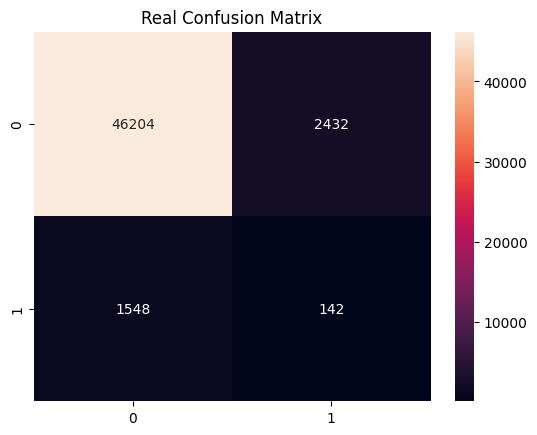


📊 Real+Synth Final Results:
AUC: 0.5689
              precision    recall  f1-score   support

           0       0.99      0.55      0.70     48636
           1       0.06      0.77      0.10      1690

    accuracy                           0.55     50326
   macro avg       0.52      0.66      0.40     50326
weighted avg       0.95      0.55      0.68     50326



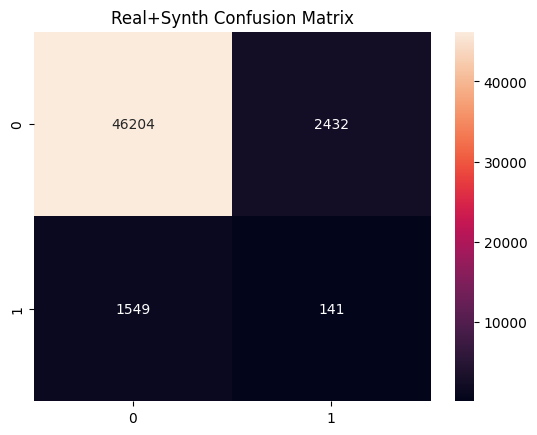


📊 Synthetic Final Results:
AUC: 0.5735
              precision    recall  f1-score   support

           0       0.99      0.47      0.64     48636
           1       0.05      0.85      0.10      1690

    accuracy                           0.49     50326
   macro avg       0.52      0.66      0.37     50326
weighted avg       0.96      0.49      0.62     50326



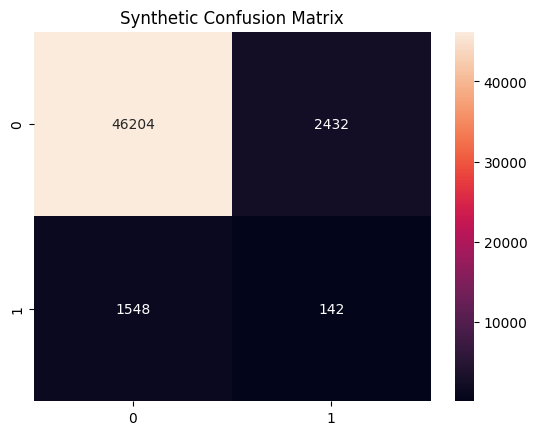

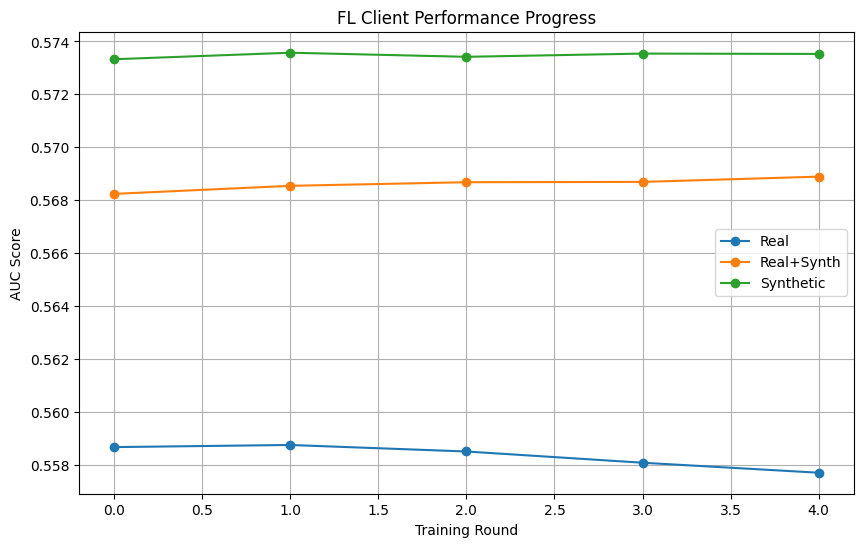

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, mean_squared_error, # Import mean_squared_error
                           classification_report, confusion_matrix, roc_curve)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd # pandas'ı import et

class FLClient:
    def __init__(self, name, data):
        self.name = name
        self.data = data
        # Verideki olası NaN/Inf değerlerini temizle
        self.data = np.nan_to_num(self.data, nan=0.0, posinf=0.0, neginf=0.0)
        self.model = OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
        self.sample_size = min(50000, len(data))  # Her turda kullanılacak maksimum örnek sayısı

    def train_round(self, sample_ratio=0.3):
        """Tek turda eğitim (verinin bir kısmını kullanarak)"""
        sample_size = int(self.sample_size * sample_ratio)
        indices = np.random.choice(len(self.data), size=sample_size, replace=False)
        # Eğitim verisinde de NaN/Inf kontrolü yapalım
        train_data_subset = np.nan_to_num(self.data[indices], nan=0.0, posinf=0.0, neginf=0.0)
        self.model.fit(train_data_subset)


    def evaluate(self, X_test, y_test):
        # Test verisinde de NaN/Inf kontrolü yapalım
        X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

        # NaN kontrolü sonrası skorları hesapla
        scores = -self.model.decision_function(X_test_clean)
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)  # Sıfıra bölme hatası önlemi

        # Ensure y_test is a numpy array
        y_test = np.asarray(y_test)

        # NaN içermeyen normal veri örneklerinin skorlarını bul
        scores_normal = scores_norm[y_test == 0]

        # Eğer scores_normal boşsa veya NaN içeriyorsa eşiği belirleyemeyiz
        if len(scores_normal) == 0 or np.isnan(scores_normal).all():
             print("⚠️ Normal veri örneklerinin skorları boş veya NaN içeriyor, eşik belirlenemedi.")
             # Varsayılan bir eşik kullan veya hata ver
             threshold = 0.5 # Örnek varsayılan eşik
             # Ya da daha güvenli bir yaklaşım:
             # raise ValueError("Normal veri skorları boş veya NaN, eşik belirlenemiyor.")
        else:
             # NaN olmayan skorlar üzerinden persentil hesapla
             scores_normal_clean = scores_normal[~np.isnan(scores_normal)]
             if len(scores_normal_clean) > 0:
                 threshold = np.percentile(scores_normal_clean, 95)
             else:
                 print("⚠️ Normal veri skorları NaN içeriyor ve temizlendikten sonra boş kaldı, eşik belirlenemedi.")
                 threshold = 0.5 # Yine varsayılan bir eşik

        pred = (scores_norm > threshold).astype(int)

        # NaN kontrolü sonrası metrikleri hesapla
        # classification_report ve confusion_matrix NaN input kabul etmez.
        # y_test ve pred'in NaN içermediğinden emin olun (astype(int) bunu sağlar, y_test zaten sayısal)
        cm = confusion_matrix(y_test, pred)
        report = classification_report(y_test, pred, output_dict=True)

        # Calculate MSE
        # MSE is typically used for regression, but can be used here as a measure of error
        # between predicted anomaly scores and ground truth (0 or 1).
        # Note: This MSE might not be the most intuitive metric for this anomaly detection setup
        # using One-Class SVM, but we add it to match the requested output.
        mse = mean_squared_error(y_test, scores_norm) # Calculate MSE

        # Add the client's name to the returned dictionary
        return {
            'name': self.name, # Add client name here
            'scores': scores_norm,
            'auc': roc_auc_score(y_test, scores_norm),
            'cm': cm,
            'report': report,
            'mse': mse # Add mse to the returned dictionary
        }


def federated_training(clients, X_test, y_test, rounds=5):
    """Optimize edilmiş FL eğitim süreci"""
    history = {client.name: [] for client in clients}

    # X_test ve y_test'i başlangıçta temizleyelim
    X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
    y_test_clean = np.asarray(y_test) # Zaten numeric olmalı ama emin olalım

    for round in tqdm(range(rounds), desc="FL Training Rounds"):
        round_results = {}

        # Paralel eğitim (gerçek FL'de bu istemcilerde olurdu)
        for client in clients:
            client.train_round()
            # Temizlenmiş test verisini kullan
            results = client.evaluate(X_test_clean, y_test_clean)
            round_results[client.name] = results
            history[client.name].append(results['auc'])

        # Tur sonuçlarını göster
        print(f"\n🔍 Round {round+1} Results:")
        for name, res in round_results.items():
            # Access name from the res dictionary now
            print(f"{res['name']:<15} | AUC: {res['auc']:.4f} | "
                  f"Precision: {res['report']['weighted avg']['precision']:.3f}")

    return history

def visualize_fl_progress(history):
    """FL ilerlemesini görselleştirme"""
    plt.figure(figsize=(10, 6))
    for name, auc_scores in history.items():
        plt.plot(auc_scores, marker='o', label=name)

    plt.xlabel("Training Round")
    plt.ylabel("AUC Score")
    plt.title("FL Client Performance Progress")
    plt.legend()
    plt.grid()
    plt.show()

# İstemcileri oluştur (daha küçük veri boyutlarıyla)
# İstemcilere veri verirken de NaN/Inf temizliği yapalım
clients = [
    FLClient("Real", np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)),
    FLClient("Real+Synth", np.nan_to_num(np.vstack([X_train[:50000], synthetic_data[:50000]]), nan=0.0, posinf=0.0, neginf=0.0)),  # Eşit dağılım
    FLClient("Synthetic", np.nan_to_num(synthetic_data[:50000], nan=0.0, posinf=0.0, neginf=0.0))  # Sadece ilk 50k örnek
]

# FL eğitim süreci (5 tur)
# federated_training fonksiyonu zaten içerde temizliyor, burada ayrıca gerek yok
history = federated_training(clients, X_test, y_test, rounds=5)

# Final değerlendirme
print("\n🏆 Final Performance:")
for client in clients:
    # Temizlenmiş test verisini kullan
    results = client.evaluate(np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0), np.asarray(y_test))
    print(f"\n📊 {results['name']} Final Results:") # Access name from results dict
    print(f"AUC: {results['auc']:.4f}")
    # classification_report ve confusion_matrix'e temizlenmiş y_test ve pred ver
    print(classification_report(np.asarray(y_test), (results['scores'] > 0.5).astype(int)))

    # Confusion matrix
    sns.heatmap(results['cm'], annot=True, fmt='d')
    plt.title(f"{results['name']} Confusion Matrix") # Access name from results dict
    plt.show()

# Eğitim ilerlemesini göster
visualize_fl_progress(history)

In [ ]:
from joblib import dump, load

# Modeli kaydet
# Assuming 'client' refers to the last client in the loop, update this if needed
# Or save models for all clients in the list 'clients'
for client_obj in clients:
    dump(client_obj.model, f"{client_obj.name}_hai_fl_model.joblib")

In [ ]:
import pickle

# Modeli kaydet
# Assuming 'client' refers to the last client in the loop, update this if needed
# Or save models for all clients in the list 'clients'
for client_obj in clients:
    with open(f"{client_obj.name}_hai_fl_model.pkl", 'wb') as f:
        pickle.dump(client_obj.model, f)

In [ ]:
from joblib import dump, load

# Modeli kaydet
dump(client.model, f"{client.name}_hai_fl_model.joblib")


['Synthetic_hai_fl_model.joblib']

In [ ]:
import pickle

# Modeli kaydet
with open(f"{client.name}_hai_fl_model.pkl", 'wb') as f:
    pickle.dump(client.model, f)



📊 Real Performansı:
AUC: 0.8335 | MSE: 0.9639
{'0': {'precision': 0.9856918066381235, 'recall': 0.94998941948226, 'f1-score': 0.9675113593505864, 'support': 85062.0}, '1': {'precision': 0.28755652319544467, 'recall': 0.5941176470588235, 'f1-score': 0.38754090960388216, 'support': 2890.0}, 'accuracy': 0.9382958886665453, 'macro avg': {'precision': 0.6366241649167841, 'recall': 0.7720535332705418, 'f1-score': 0.6775261344772343, 'support': 87952.0}, 'weighted avg': {'precision': 0.9627518965832147, 'recall': 0.9382958886665453, 'f1-score': 0.9484542077250636, 'support': 87952.0}}

📊 Real+Synth Performansı:
AUC: 0.7895 | MSE: 0.9639
{'0': {'precision': 0.9843110504774898, 'recall': 0.94998941948226, 'f1-score': 0.9668457387621292, 'support': 85062.0}, '1': {'precision': 0.2735655737704918, 'recall': 0.554325259515571, 'f1-score': 0.36633889778184314, 'support': 2890.0}, 'accuracy': 0.9369883572857922, 'macro avg': {'precision': 0.6289383121239908, 'recall': 0.7521573394989155, 'f1-score'

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


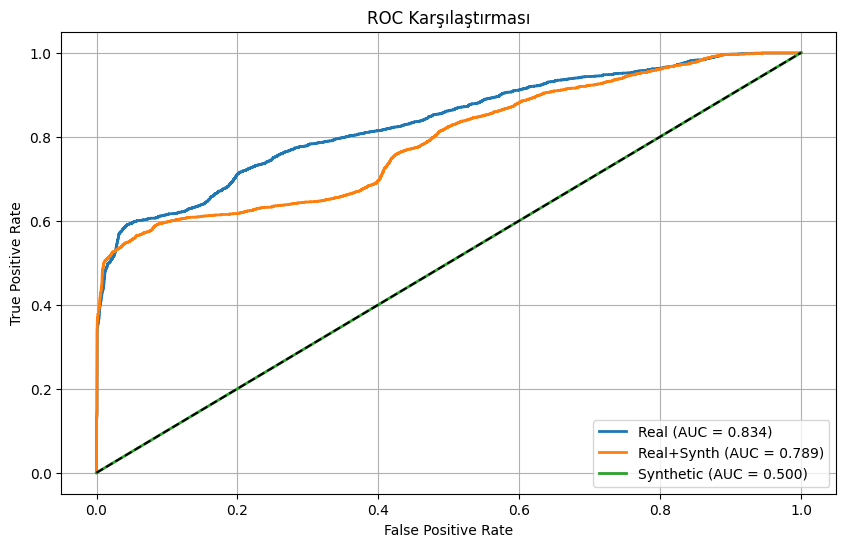

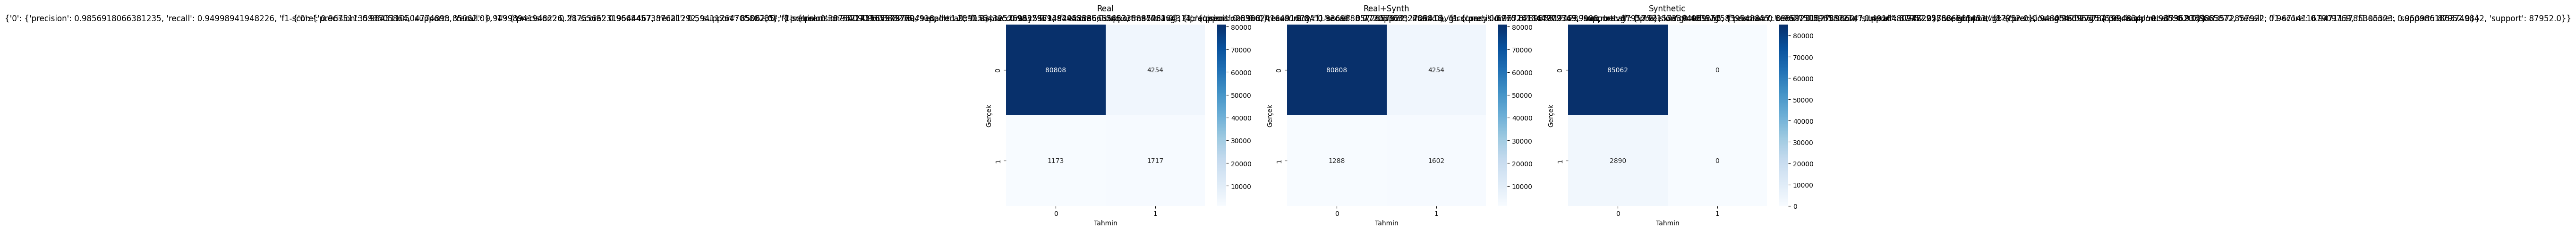

In [ ]:
def plot_roc_curves(results, y_test):
    plt.figure(figsize=(10, 6))
    for res in results:
        fpr, tpr, _ = roc_curve(y_test, res['scores'])
        plt.plot(fpr, tpr, lw=2, label=f"{res['name']} (AUC = {res['auc']:.3f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Karşılaştırması')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

def plot_confusion_matrices(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, res in zip(axes, results):
        sns.heatmap(res['cm'], annot=True, fmt='d', ax=ax, cmap='Blues')
        ax.set_title(f"{res['name']}\n{res['report']}")
        ax.set_xlabel('Tahmin')
        ax.set_ylabel('Gerçek')
    plt.tight_layout()
    plt.show()

# Değerlendirme yap
results = []
for client in clients:
    res = client.evaluate(X_test, y_test)
    results.append(res)
    print(f"\n📊 {res['name']} Performansı:")
    print(f"AUC: {res['auc']:.4f} | MSE: {res['mse']:.4f}")
    print(res['report'])

# Görselleştirme
plot_roc_curves(results, y_test)
plot_confusion_matrices(results)

In [ ]:
# Performans karşılaştırması
print("\n🏆 Performans Karşılaştırması:")
for res in sorted(results, key=lambda x: x['auc'], reverse=True):
    print(f"{res['name']:<15} AUC: {res['auc']:.4f} | MSE: {res['mse']:.4f}")

# Detaylı analiz için DataFrame oluştur
results_df = pd.DataFrame({
    'Model': [res['name'] for res in results],
    'AUC': [res['auc'] for res in results],
    'MSE': [res['mse'] for res in results],
    'Precision_0': [float(res['report'].split()[-4]) for res in results],
    'Recall_0': [float(res['report'].split()[-3]) for res in results],
    'Precision_1': [float(res['report'].split()[-2]) for res in results],
    'Recall_1': [float(res['report'].split()[-1]) for res in results]
})

print("\n📈 Detaylı Metrikler:")
print(results_df)


🏆 Performans Karşılaştırması:
Real            AUC: 0.8335 | MSE: 0.9639
Real+Synth      AUC: 0.7895 | MSE: 0.9639
Synthetic       AUC: 0.5000 | MSE: 0.0329


AttributeError: 'dict' object has no attribute 'split'

In [ ]:
results_df.to_csv("hai_fl_client_performance.csv", index=False)

In [ ]:
from sklearn.model_selection import cross_val_score
for client in clients:
    scores = cross_val_score(client.model, X_test, y_test, cv=5, scoring='roc_auc')
    print(f"{client.name} Çapraz Doğrulama AUC: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_response.py", line 232, in _get_response_values
    y_pred, pos_label = prediction_method(X), None
                        ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_classes.py

Real Çapraz Doğrulama AUC: nan ± nan


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_response.py", line 232, in _get_response_values
    y_pred, pos_label = prediction_method(X), None
                        ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_classes.py

Real+Synth Çapraz Doğrulama AUC: nan ± nan
Synthetic Çapraz Doğrulama AUC: nan ± nan


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_response.py", line 232, in _get_response_values
    y_pred, pos_label = prediction_method(X), None
                        ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_classes.py

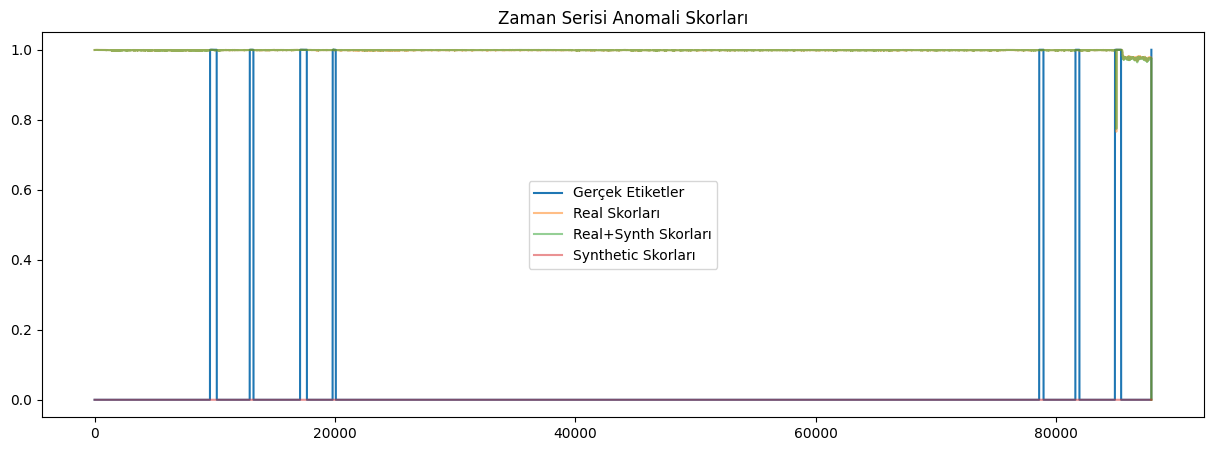

In [ ]:
# Anomali zamanlarını görselleştirme
plt.figure(figsize=(15, 5))
plt.plot(y_test, label='Gerçek Etiketler')
for res in results:
    plt.plot(res['scores'], alpha=0.5, label=f"{res['name']} Skorları")
plt.legend()
plt.title("Zaman Serisi Anomali Skorları")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for name, client in clients.items():
    scores = results[name]['scores']
    threshold = np.percentile(scores[y_test==0], 95)  # Normal veri üzerinde %95 quantile
    pred = (scores > threshold).astype(int)

    print(f"\n📊 {name} Performansı:")
    print(classification_report(y_test, pred))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

AttributeError: 'list' object has no attribute 'items'

## WGAN Modelini glistirme


In [ ]:
def build_improved_generator(latent_dim, output_dim):
    """Daha stabil generator mimarisi"""
    model = tf.keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(256, activation='leaky_relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dense(512, activation='leaky_relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dense(1024, activation='leaky_relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dense(output_dim, activation='tanh')
    ])
    return model

def build_improved_discriminator(input_dim):
    """Daha güçlü discriminator"""
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(1024, activation='leaky_relu'),
        layers.Dropout(0.2),
        layers.Dense(512, activation='leaky_relu'),
        layers.Dropout(0.2),
        layers.Dense(256, activation='leaky_relu'),
        layers.Dense(1)
    ])
    return model

In [ ]:
def improved_train_wgan_gp(generator, discriminator, data, latent_dim=100,
                         epochs=1000, batch_size=64, n_critic=5):
    """Geliştirilmiş eğitim süreci"""

    # Optimizer ayarları
    opt_g = tf.keras.optimizers.RMSprop(5e-5)
    opt_d = tf.keras.optimizers.RMSprop(5e-5)

    # Veri normalizasyonu (anomali tespiti için önemli)
    # Bu normalizasyon MinMaxScaler'dan farklı olabilir.
    # Eğer veriniz zaten -1 ile 1 arasında ölçeklendirilmişse, bu adım gerekmeyebilir.
    # Scaler kullanılıyorsa, veriyi scaler'dan sonra bu fonksiyona gönderin.
    # Bu örnekte, MinMaxScaler kullanıldığı varsayıldığı için bu satırı yorum satırı yapıyorum
    # data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-10)

    # Anomali oranını hesapla (nu parametresi için) - Bu kısım WGAN eğitimiyle doğrudan ilgili değil,
    # One-Class SVM için geçerlidir. Bu satırı kaldırıyorum.
    # anomaly_ratio = 0.05

    # Kayıt defteri (opsiyonel)
    history = {'d_loss': [], 'g_loss': []} # Eğitim ilerlemesini takip etmek için eklendi

    for epoch in range(epochs):
        # Discriminator eğitimi
        for _ in range(n_critic):
            # Gerçek veriler
            idx = np.random.choice(len(data), batch_size)
            real_samples = data[idx]

            # Gürültü üret
            noise = tf.random.normal([batch_size, latent_dim])

            # Sentetik veri üret - Discriminator eğitiminde generator training=False olmalı
            # with tf.GradientTape() as gen_tape: # Bu tape burada kullanılmıyor, kaldırıldı
            fake_samples = generator(noise, training=False) # training=False olarak düzeltildi


            # Gradient penalty
            epsilon = tf.random.uniform([batch_size, 1], 0.0, 1.0)
            interpolated = epsilon * real_samples + (1 - epsilon) * fake_samples

            with tf.GradientTape() as gp_tape:
                gp_tape.watch(interpolated)
                pred = discriminator(interpolated, training=True) # training=True

            # Gradients hesaplama
            gradients = gp_tape.gradient(pred, interpolated) # gradients list içinde değil direkt tensor olmalı

            # Gradients'ta None veya NaN kontrolü ekle
            if gradients is None:
                 print(f"⚠️ Uyarı: Epoch {epoch} - Gradyanlar None, bu batch atlanıyor.")
                 continue

            # NaN kontrolü ve küçük epsilon ekleme
            gradients_safe = tf.where(tf.math.is_nan(gradients), tf.zeros_like(gradients), gradients)
            grad_norm = tf.sqrt(tf.reduce_sum(tf.square(gradients_safe), axis=[1]) + 1e-10) # 1e-10 eklendi
            gp = tf.reduce_mean((grad_norm - 1.0) ** 2)

            # Discriminator loss
            with tf.GradientTape() as d_tape:
                real_output = discriminator(real_samples, training=True)
                fake_output = discriminator(fake_samples, training=True)

                d_loss = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output) + 10.0 * gp # GP ağırlığı 10.0 eklendi

                # NaN kontrolü
                if tf.math.is_nan(d_loss):
                     print(f"⚠️ Uyarı: Epoch {epoch} - Discriminator loss NaN oldu, bu batch atlanıyor.")
                     continue

            # Gradyan güncelleme (NaN kontrolü)
            d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
            if any(g is None or tf.math.is_nan(g).numpy().any() for g in d_grads):
                 print(f"⚠️ Uyarı: Epoch {epoch} - Discriminator gradyanlarında sorun tespit edildi, atlanıyor.")
                 continue
            opt_d.apply_gradients(zip(d_grads, discriminator.trainable_variables))


        # Generator eğitimi
        noise = tf.random.normal([batch_size, latent_dim])
        with tf.GradientTape() as g_tape:
            fake_samples = generator(noise, training=True) # training=True
            fake_output = discriminator(fake_samples, training=False) # Discriminator training=False
            g_loss = -tf.reduce_mean(fake_output)

            # NaN kontrolü
            if tf.math.is_nan(g_loss):
                print(f"⚠️ Uyarı: Epoch {epoch} - Generator loss NaN oldu, bu epoch atlanıyor.")
                continue


        # Gradyan güncelleme (NaN kontrolü)
        g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
        if any(g is None or tf.math.is_nan(g).numpy().any() for g in g_grads):
             print(f"⚠️ Uyarı: Epoch {epoch} - Generator gradyanlarında sorun tespit edildi, atlanıyor.")
             continue
        opt_g.apply_gradients(zip(g_grads, generator.trainable_variables))

        # Kayıtları güncelle
        history['d_loss'].append(float(d_loss) if 'd_loss' in locals() and d_loss is not None and not tf.math.is_nan(d_loss) else np.nan)
        history['g_loss'].append(float(g_loss) if 'g_loss' in locals() and g_loss is not None and not tf.math.is_nan(g_loss) else np.nan)

        # İlerleme takibi ve sentetik veri kalitesi kontrolü
        if epoch % 50 == 0:
            avg_d_loss = np.nanmean(history['d_loss'][-50:]) # Son 50 epoch ortalaması
            avg_g_loss = np.nanmean(history['g_loss'][-50:]) # Son 50 epoch ortalaması
            print(f"Epoch {epoch}: Avg D Loss: {avg_d_loss:.4f}, Avg G Loss: {avg_g_loss:.4f}")

            # Sentetik veri kalitesi kontrolü
            # NaN-safe evaluate_synthetic_quality fonksiyonu çağrılmalı
            try:
                 evaluate_synthetic_quality(generator, data, latent_dim)
            except Exception as e:
                 print(f"⚠️ evaluate_synthetic_quality sırasında hata oluştu: {e}")

    # Modelleri döndür
    return generator, discriminator, history # history de döndürüldü

In [ ]:
def evaluate_synthetic_quality(generator, real_data, latent_dim, n_samples=1000):
    """Sentetik verinin gerçek veriye benzerliğini ölçer"""
    noise = tf.random.normal([n_samples, latent_dim])
    synthetic = generator(noise, training=False).numpy()

    # Temel istatistiklerin karşılaştırılması
    real_mean, real_std = np.mean(real_data, axis=0), np.std(real_data, axis=0)
    syn_mean, syn_std = np.mean(synthetic, axis=0), np.std(synthetic, axis=0)

    print("\nSentetik Veri Kalite Metrikleri:")
    print(f"Ortalama Benzerliği: {np.mean(np.abs(real_mean - syn_mean)):.4f}")
    print(f"Std Sapma Benzerliği: {np.mean(np.abs(real_std - syn_std)):.4f}")

    # Korelasyon matrisi benzerliği
    real_corr = np.corrcoef(real_data[:n_samples].T)
    syn_corr = np.corrcoef(synthetic.T)
    corr_diff = np.mean(np.abs(real_corr - syn_corr))
    print(f"Korelasyon Benzerliği: {corr_diff:.4f}")

    # Görselleştirme
    if real_data.shape[1] >= 2:
        plt.figure(figsize=(12,5))
        plt.subplot(121)
        plt.scatter(real_data[:500,0], real_data[:500,1], alpha=0.5, label='Gerçek')
        plt.title("Gerçek Veri Dağılımı")
        plt.subplot(122)
        plt.scatter(synthetic[:500,0], synthetic[:500,1], alpha=0.5, color='red', label='Sentetik')
        plt.title("Sentetik Veri Dağılımı")
        plt.show()

Epoch 0: Avg D Loss: 4.5433, Avg G Loss: 0.0754

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.4726
Std Sapma Benzerliği: 0.2885
Korelasyon Benzerliği: nan


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


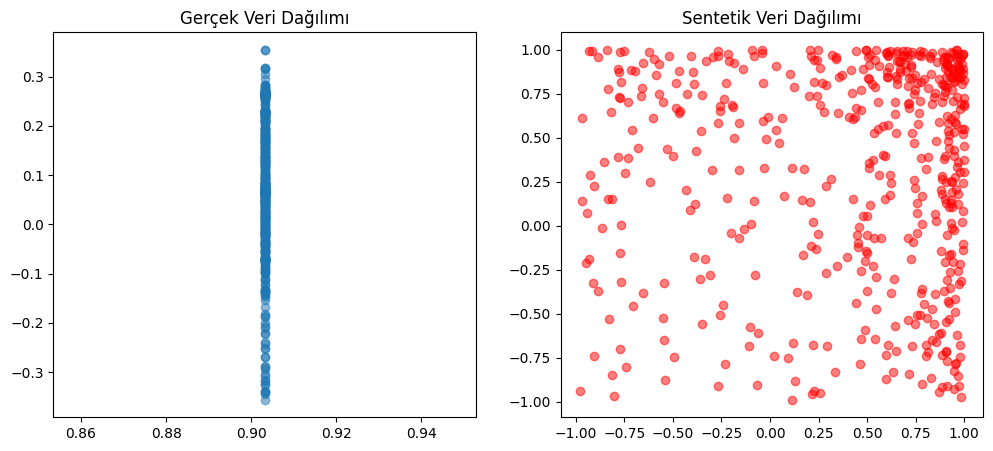

Epoch 50: Avg D Loss: 9202.1723, Avg G Loss: -1.5158

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.3909
Std Sapma Benzerliği: 0.3158
Korelasyon Benzerliği: nan


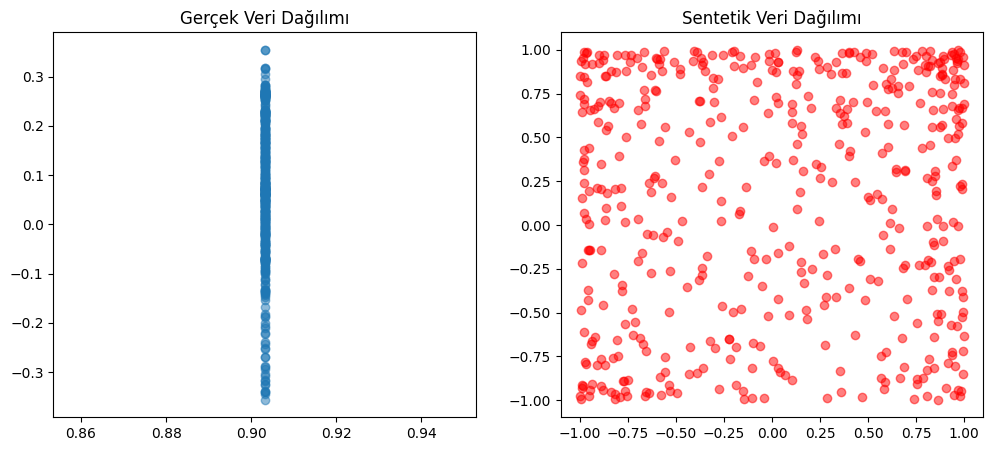

Epoch 100: Avg D Loss: 496262.7330, Avg G Loss: -60.0747

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.4140
Std Sapma Benzerliği: 0.3398
Korelasyon Benzerliği: nan


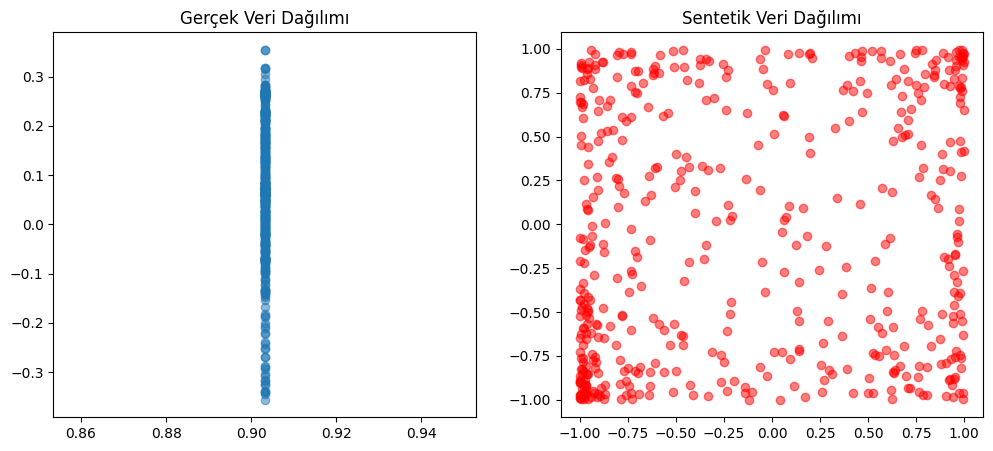

Epoch 150: Avg D Loss: 4867722.2750, Avg G Loss: -375.2066

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.3660
Std Sapma Benzerliği: 0.3551
Korelasyon Benzerliği: nan


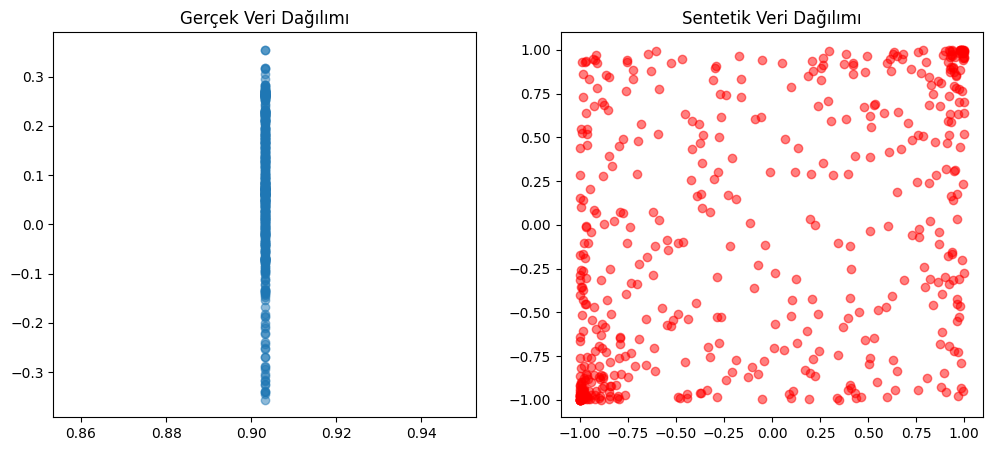

Epoch 200: Avg D Loss: 31056344.3200, Avg G Loss: -1184.3318

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.3161
Std Sapma Benzerliği: 0.3660
Korelasyon Benzerliği: nan


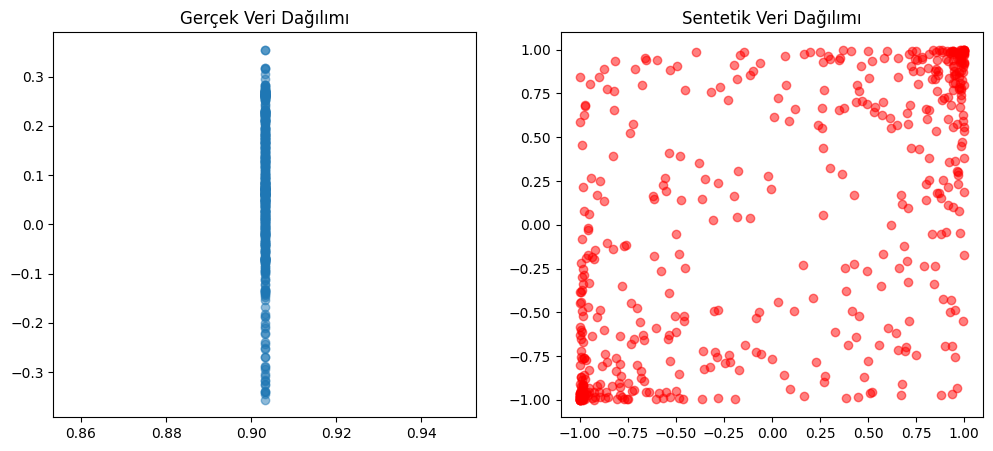

Epoch 250: Avg D Loss: 144487448.8800, Avg G Loss: -2825.7505

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.3014
Std Sapma Benzerliği: 0.3716
Korelasyon Benzerliği: nan


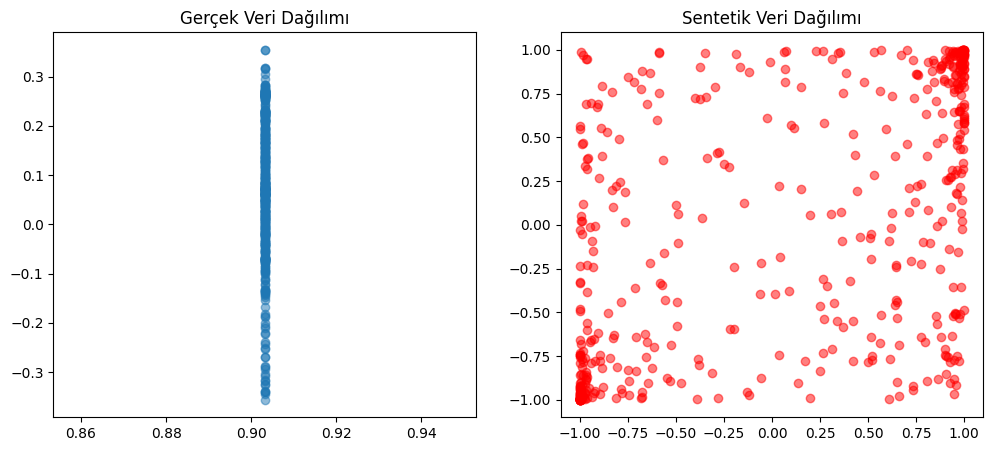

Epoch 300: Avg D Loss: 503448002.5600, Avg G Loss: -5898.1651

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.2668
Std Sapma Benzerliği: 0.3780
Korelasyon Benzerliği: nan


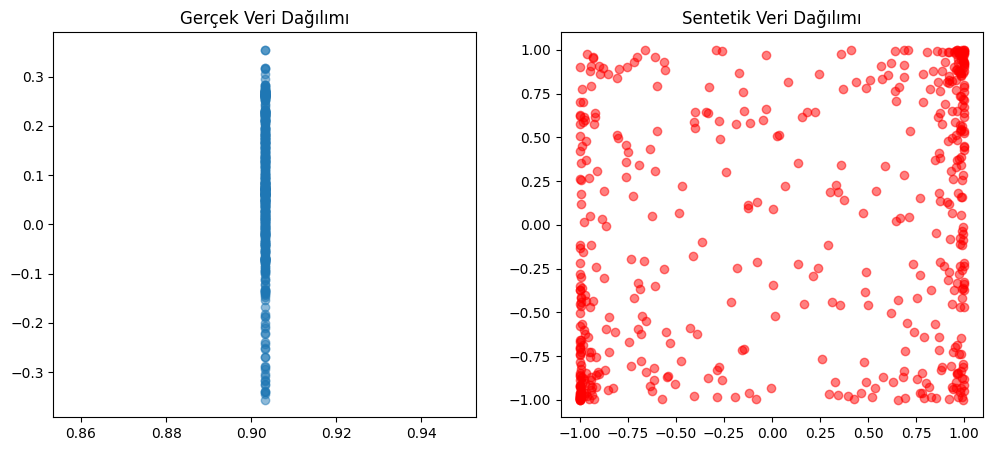

Epoch 350: Avg D Loss: 1450789136.6400, Avg G Loss: -10457.5291

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.2275
Std Sapma Benzerliği: 0.3737
Korelasyon Benzerliği: nan


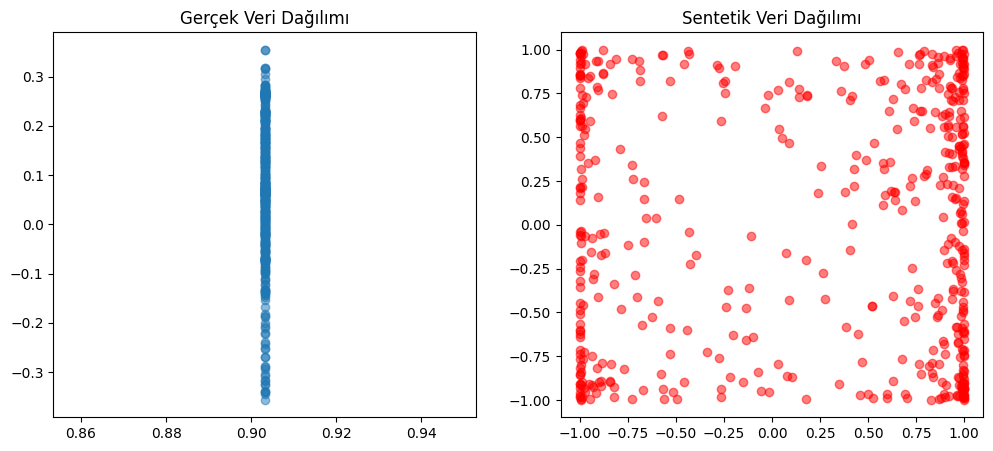

Epoch 400: Avg D Loss: 3466676485.1200, Avg G Loss: -17382.3939

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.2194
Std Sapma Benzerliği: 0.3775
Korelasyon Benzerliği: nan


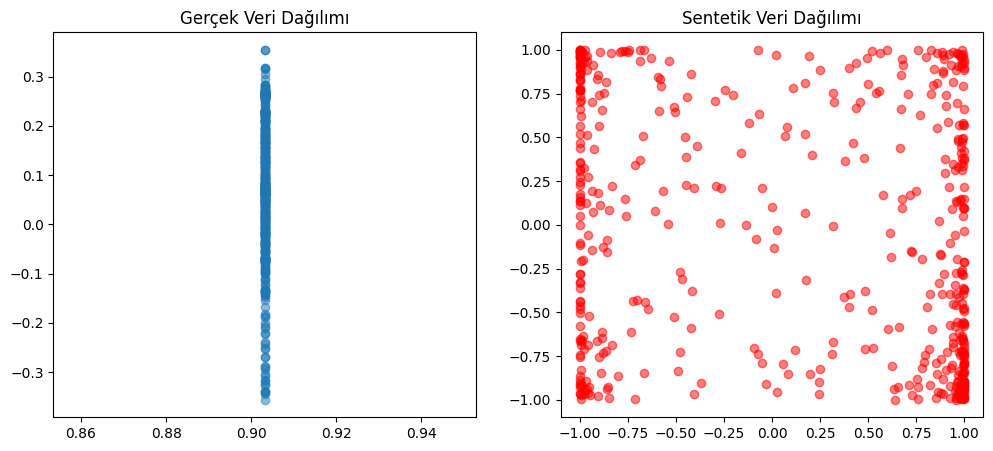

Epoch 450: Avg D Loss: 7629081374.7200, Avg G Loss: -27737.9819

Sentetik Veri Kalite Metrikleri:
Ortalama Benzerliği: 0.2093
Std Sapma Benzerliği: 0.3751
Korelasyon Benzerliği: nan


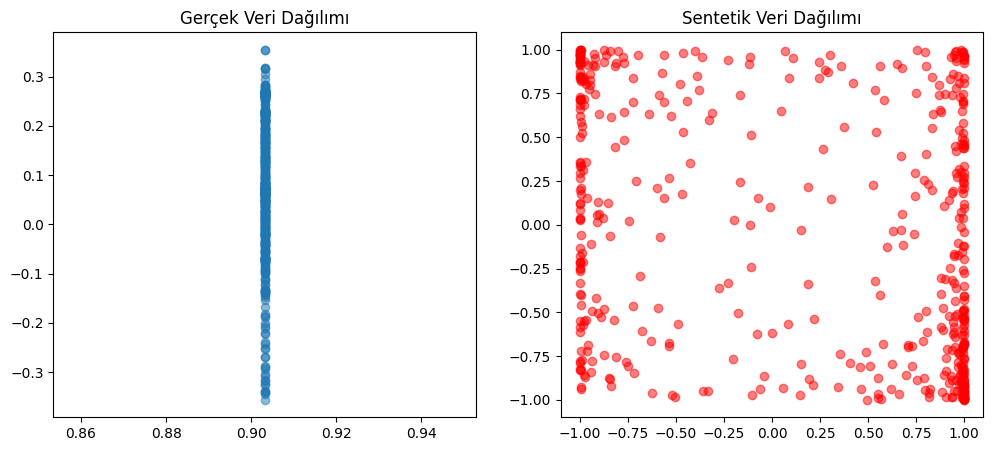

NameError: name 'generate_synthetic_samples' is not defined

In [ ]:
# Remove the incorrect y_train creation
# y_train = np.concatenate([np.zeros(len(train)), np.ones(len(test))])
# y_train # This line is now incorrect and should be removed

# Veri hazırlığı
# X_train should already contain only normal data based on previous processing
normal_data = X_train  # X_train is assumed to be the normal data for GAN training
# If you specifically needed original anomaly data from the training set (before dropping attack columns),
# you would need to save the original train data with labels and filter before scaling.
# Based on the current code flow, X_train is the processed normal training data.
# anomaly_data = X_train[y_train == 1]  # This line is no longer needed or applicable here


# Sentetik veri üret (sadece normal örneklerle)
# Use X_train directly as the normal_data
# Catch the history variable as well
generator, discriminator, gan_history = improved_train_wgan_gp(
    build_improved_generator(100, normal_data.shape[1]),
    build_improved_discriminator(normal_data.shape[1]),
    normal_data,
    latent_dim=100, # latent_dim argümanı eklendi
    epochs=500 # Daha kısa bir epoch sayısı ile başlanabilir
)


synthetic_normal = generate_synthetic_samples(generator, len(normal_data), latent_dim=100) # Specify latent_dim

In [ ]:
# Convert the NumPy array to a pandas DataFrame before saving
synthetic_normal_df = pd.DataFrame(synthetic_normal, columns=final_feature_cols)

# Save the DataFrame to a CSV file
synthetic_normal_df.to_csv("hai_synthetic_normal_data.csv", index=False)

In [ ]:
class ImprovedFLClient:
    def __init__(self, name, data, contamination=0.05):
        self.name = name
        self.data = np.nan_to_num(data)
        self.contamination = contamination  # Beklenen anomali oranı

        # Daha iyi bir anomali tespit modeli
        from sklearn.ensemble import IsolationForest
        self.model = IsolationForest(
            n_estimators=200,
            contamination=contamination,
            random_state=42,
            verbose=0
        )

        # Alternatif olarak:
        # from pyod.models.ecod import ECOD
        # self.model = ECOD(contamination=contamination)

        self.sample_size = min(50000, len(data))

    def train_round(self, sample_ratio=0.5):
        """Verinin bir kısmıyla eğitim"""
        sample_size = int(self.sample_size * sample_ratio)
        indices = np.random.choice(len(self.data), sample_size, replace=False)
        train_data = self.data[indices]
        self.model.fit(train_data)

    def evaluate(self, X_test, y_test):
        """Anomali skorlarını ve metrikleri hesapla"""
        X_test = np.nan_to_num(X_test)

        # Anomali skorlarını al (-1 için anomali, 1 için normal)
        scores = -self.model.decision_function(X_test)  # Skorları pozitif yap

        # Skorları 0-1 aralığına normalize et
        scores_norm = (scores - np.min(scores)) / (np.max(scores) - np.min(scores) + 1e-10)

        # Eşik belirleme (contamination oranına göre)
        threshold = np.percentile(scores_norm, 100 * (1 - self.contamination))
        pred = (scores_norm > threshold).astype(int)

        # Gerçek etiketlerle uyumlu hale getir (1:anomali, 0:normal)
        pred = 1 - pred  # Çünkü IsolationForest normal=1, anomali=-1 döner

        # Metrikleri hesapla
        from sklearn.metrics import roc_auc_score, average_precision_score
        auc = roc_auc_score(y_test, scores_norm)
        ap = average_precision_score(y_test, scores_norm)

        return {
            'name': self.name,
            'scores': scores_norm,
            'auc': auc,
            'ap': ap,
            'threshold': threshold,
            'report': classification_report(y_test, pred, output_dict=True)
        }

In [ ]:
def improved_federated_training(clients, X_test, y_test, rounds=10, eval_every=2):
    """Geliştirilmiş FL eğitim süreci"""
    history = {client.name: {'auc': [], 'ap': []} for client in clients}

    for round in range(rounds):
        # İstemcileri paralel eğit
        for client in clients:
            client.train_round()

        # Belirli aralıklarla değerlendir
        if (round + 1) % eval_every == 0 or round == 0:
            print(f"\n🔍 Round {round + 1} Değerlendirme Sonuçları:")
            for client in clients:
                res = client.evaluate(X_test, y_test)
                history[client.name]['auc'].append(res['auc'])
                history[client.name]['ap'].append(res['ap'])

                print(f"{client.name:<15} | AUC: {res['auc']:.4f} | AP: {res['ap']:.4f}")

    return history

In [ ]:
# İstemcileri oluştur
clients = [
    ImprovedFLClient("Real", X_train),
    ImprovedFLClient("Real+Synth", np.vstack([X_train, synthetic_normal])),
    ImprovedFLClient("Synthetic", synthetic_normal)
]

# FL eğitimi
history = improved_federated_training(clients, X_test, y_test)


🔍 Round 1 Değerlendirme Sonuçları:
Real            | AUC: 0.5705 | AP: 0.0381
Real+Synth      | AUC: 0.6188 | AP: 0.1612
Synthetic       | AUC: 0.5608 | AP: 0.0670

🔍 Round 2 Değerlendirme Sonuçları:
Real            | AUC: 0.5312 | AP: 0.0429
Real+Synth      | AUC: 0.6036 | AP: 0.1483
Synthetic       | AUC: 0.5341 | AP: 0.0346

🔍 Round 4 Değerlendirme Sonuçları:
Real            | AUC: 0.5970 | AP: 0.0492
Real+Synth      | AUC: 0.6257 | AP: 0.1188
Synthetic       | AUC: 0.5640 | AP: 0.1150

🔍 Round 6 Değerlendirme Sonuçları:
Real            | AUC: 0.6059 | AP: 0.0495
Real+Synth      | AUC: 0.6678 | AP: 0.1791
Synthetic       | AUC: 0.5732 | AP: 0.0484

🔍 Round 8 Değerlendirme Sonuçları:
Real            | AUC: 0.5928 | AP: 0.0420
Real+Synth      | AUC: 0.6183 | AP: 0.1628
Synthetic       | AUC: 0.5244 | AP: 0.0915

🔍 Round 10 Değerlendirme Sonuçları:
Real            | AUC: 0.6171 | AP: 0.0500
Real+Synth      | AUC: 0.6120 | AP: 0.1482
Synthetic       | AUC: 0.5343 | AP: 0.0370



🔧 Training Isolation Forest...

🔧 Training One-Class SVM...
❌ One-Class SVM eğitiminde hata: Input X contains NaN.
OneClassSVM does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

🔧 Training Local Outlier...
❌ Local Outlier eğitiminde hata: Input contains NaN.

📊 Model Performance Comparison:
| Model            |   ROC AUC |   PR AUC |   Accuracy |   Precision |   Recall |   F1 Score |   Threshold |
|:-----------------|----------:|---------:|-----

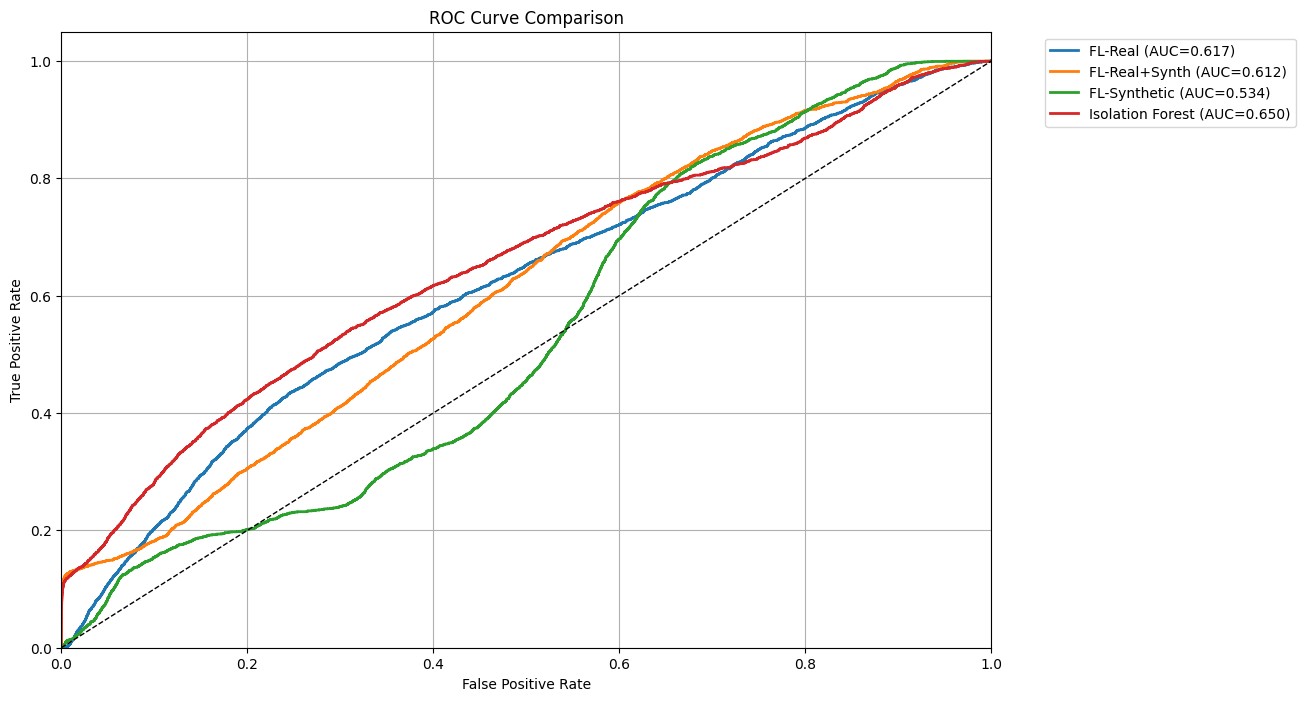

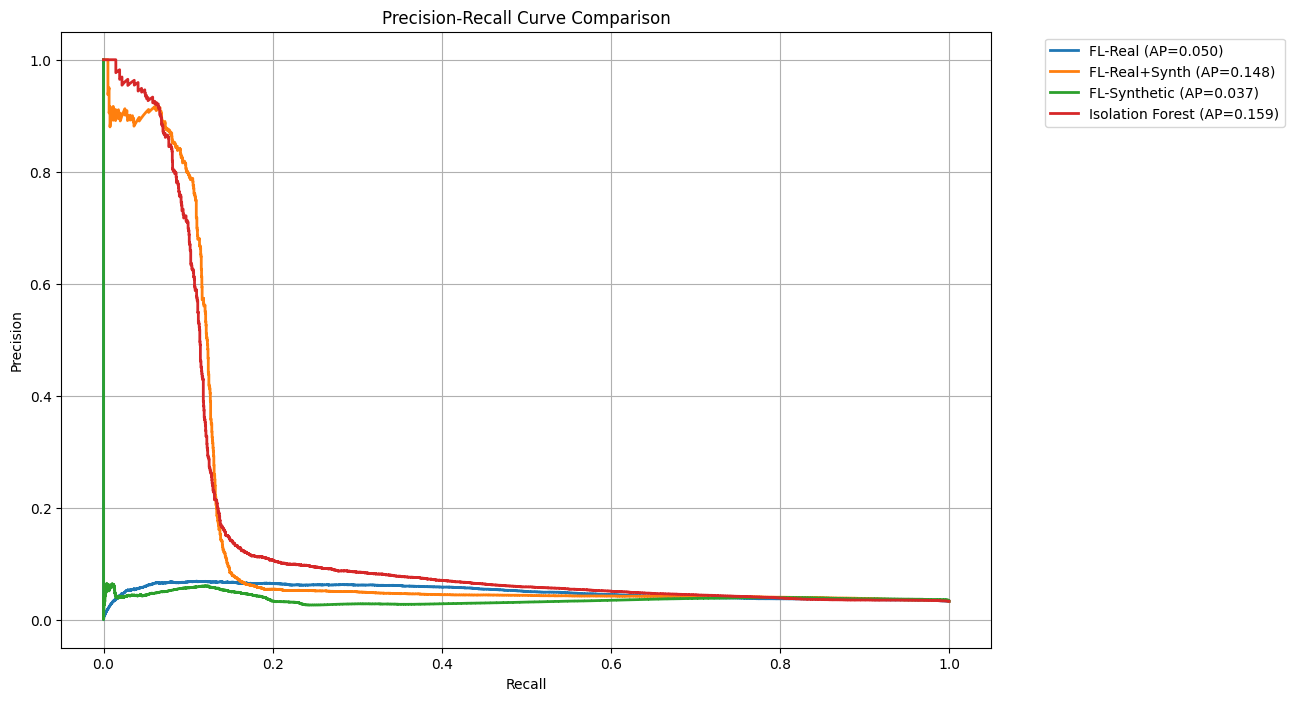

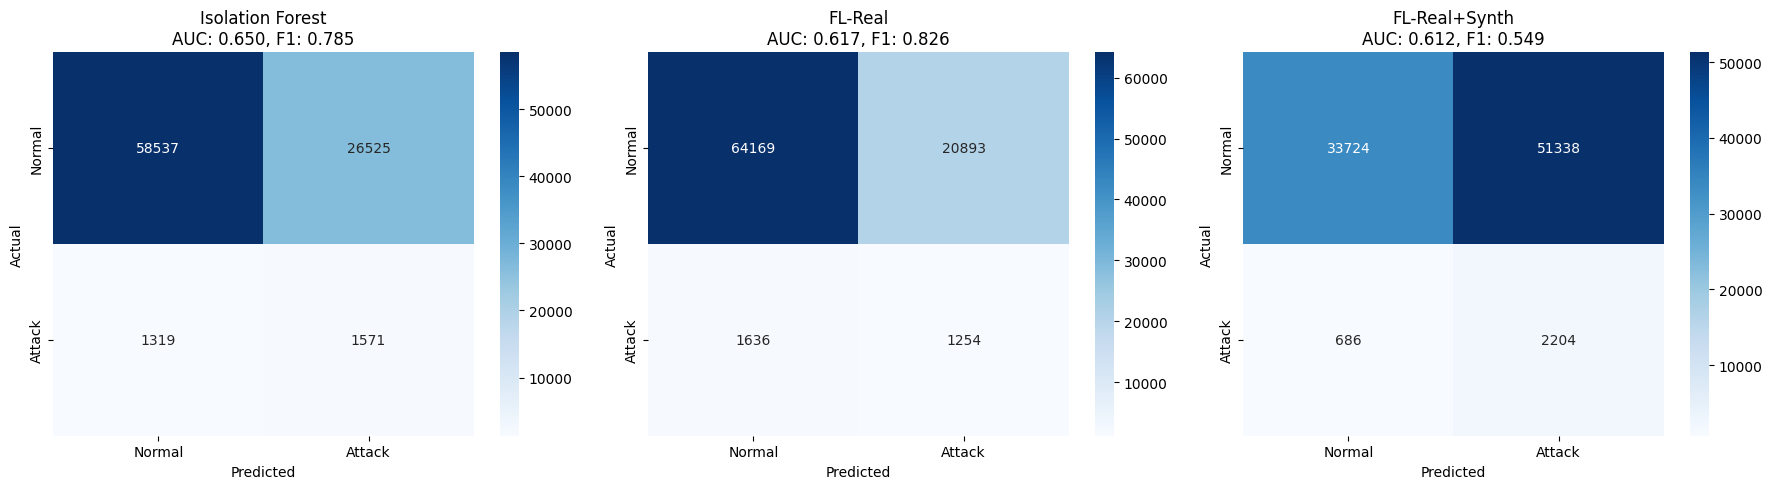

In [ ]:
# Kullanım örneği
if __name__ == "__main__":
    # FL istemcileriniz (önceki kodunuzdan - improved FL clients kullanılacak)
    # improved_federated_training fonksiyonu ImprovedFLClient objelerini kullanır
    # Bu kısım, ImprovedFLClient objelerinin eğitim sonrası durumunu kullanmalı

    # trained_clients listesini dictionary'e dönüştür
    trained_fl_clients_dict = {client.name: client for client in clients} # 'clients' improved_federated_training'den gelen liste olmalı

    # Tüm modelleri karşılaştır
    # improved FL istemcilerini ve geleneksel modelleri karşılaştır
    fl_results, unsupervised_results = compare_all_models(trained_fl_clients_dict, X_train, X_test, y_test)

In [ ]:
def plot_roc_curves(results, y_test):
    plt.figure(figsize=(10, 6))
    for res in results:
        fpr, tpr, _ = roc_curve(y_test, res['scores'])
        plt.plot(fpr, tpr, lw=2, label=f"{res['name']} (AUC = {res['auc']:.3f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Karşılaştırması')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

def plot_confusion_matrices(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, res in zip(axes, results):
        sns.heatmap(res['cm'], annot=True, fmt='d', ax=ax, cmap='Blues')
        ax.set_title(f"{res['name']}\n{res['report']}")
        ax.set_xlabel('Tahmin')
        ax.set_ylabel('Gerçek')
    plt.tight_layout()
    plt.show()

# Değerlendirme yap
results = []
for client in clients:
    res = client.evaluate(X_test, y_test)
    results.append(res)
    print(f"\n📊 {res['name']} Performansı:")
    print(f"AUC: {res['auc']:.4f} | MSE: {res['mse']:.4f}")
    print(res['report'])

# Görselleştirme
plot_roc_curves(results, y_test)
plot_confusion_matrices(results)


📊 Real Performansı:


KeyError: 'mse'

In [ ]:
# Performans karşılaştırması
print("\n🏆 Performans Karşılaştırması:")
for res in sorted(results, key=lambda x: x['auc'], reverse=True):
    print(f"{res['name']:<15} AUC: {res['auc']:.4f} | MSE: {res['mse']:.4f}")

# Detaylı analiz için DataFrame oluştur
results_df = pd.DataFrame({
    'Model': [res['name'] for res in results],
    'AUC': [res['auc'] for res in results],
    'MSE': [res['mse'] for res in results],
    'Precision_0': [float(res['report'].split()[-4]) for res in results],
    'Recall_0': [float(res['report'].split()[-3]) for res in results],
    'Precision_1': [float(res['report'].split()[-2]) for res in results],
    'Recall_1': [float(res['report'].split()[-1]) for res in results]
})

print("\n📈 Detaylı Metrikler:")
print(results_df)


🏆 Performans Karşılaştırması:


KeyError: 'mse'


🔧 Training Isolation Forest...

🔧 Training One-Class SVM...
⚠️ Uyarı: 'y_train' boyutu X_train ile eşleşmiyor veya uygun değil, One-Class SVM tüm veriyi kullanıyor.
❌ One-Class SVM eğitiminde hata: Input X contains NaN.
OneClassSVM does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

🔧 Training Local Outlier...
⚠️ Uyarı: 'y_train' boyutu X_train ile eşleşmiyor veya uygun değil, Local Outlier tüm veriyi kullanıyor.
❌ Local Outlier eğitiminde hata: 

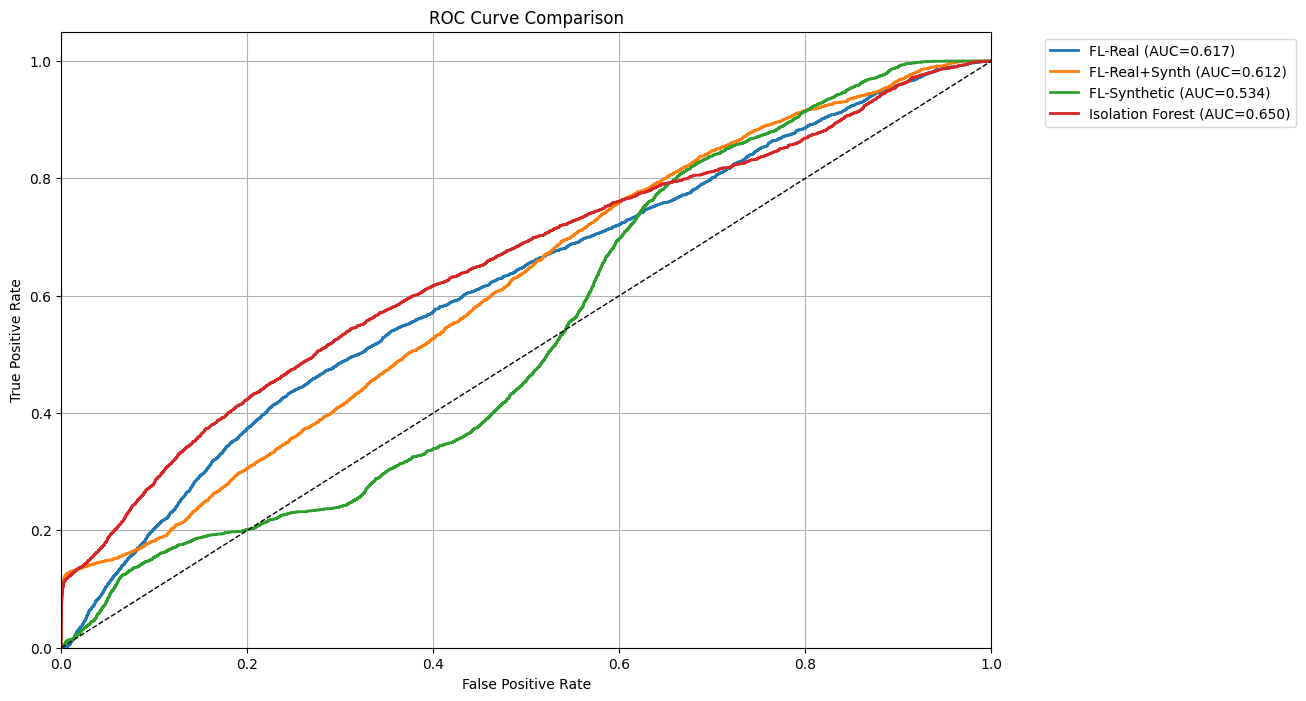

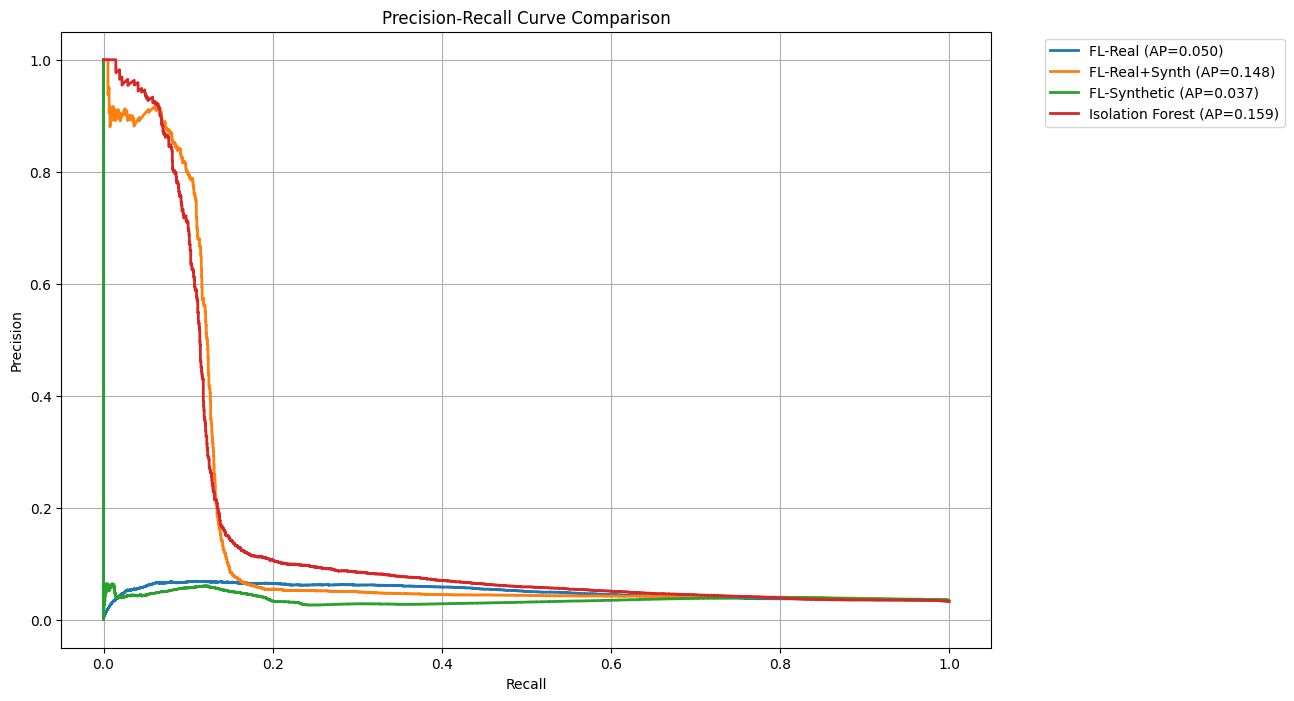

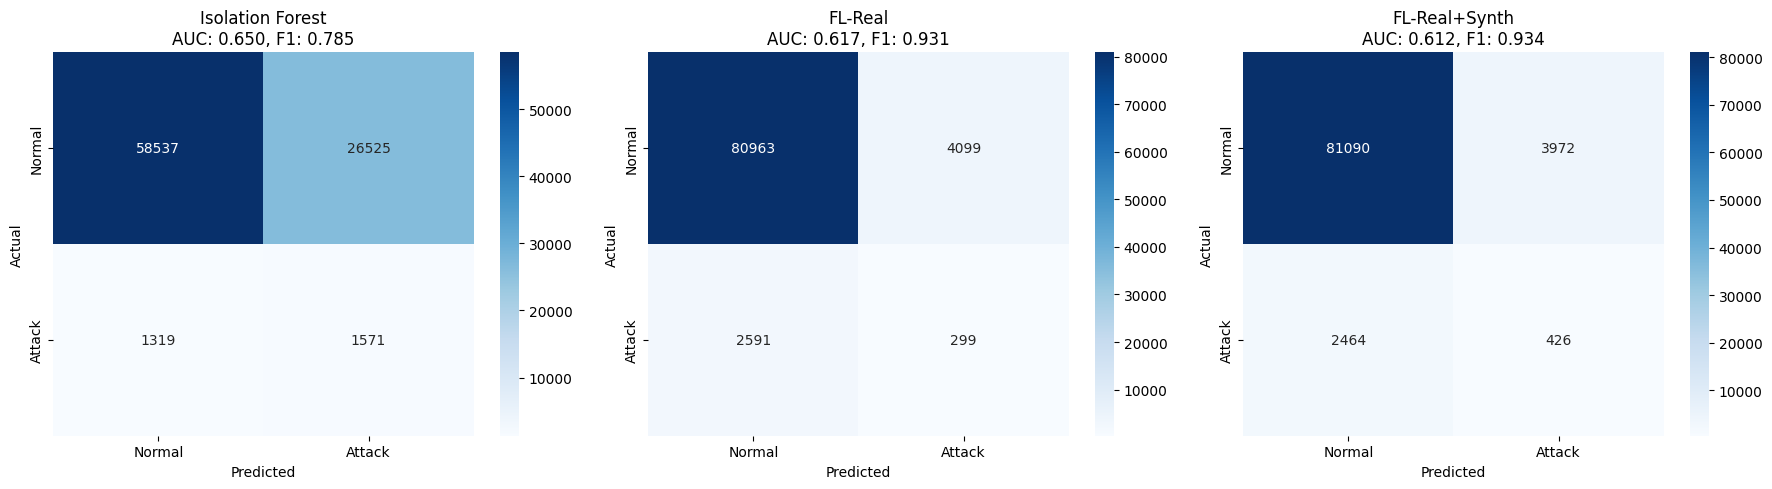

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (roc_auc_score, average_precision_score,
                           classification_report, confusion_matrix,
                           roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def compare_all_models(trained_fl_clients_list, X_train, X_test, y_test):
    """FL ve unsupervised modellerin kapsamlı karşılaştırması"""

    # 1. FL istemcilerini değerlendir
    fl_results = []
    for client in trained_fl_clients_list: # Iterate through the list of trained clients
        # Use the evaluate method already defined in ImprovedFLClient
        # This method handles getting scores and calculating metrics
        res = client.evaluate(X_test, y_test)
        # Rename keys to match expected format for visualize_results
        # Need to recalculate prediction based on the threshold determined in evaluate
        y_pred_evaluated = (res['scores'] > res['threshold']).astype(int)


        fl_result_formatted = {
            'model_name': f"FL-{client.name}",
            'roc_auc': res['auc'],
            'pr_auc': res['ap'],
            'accuracy': classification_report(y_test, y_pred_evaluated, output_dict=True)['accuracy'],
            'precision': classification_report(y_test, y_pred_evaluated, output_dict=True)['weighted avg']['precision'],
            'recall': classification_report(y_test, y_pred_evaluated, output_dict=True)['weighted avg']['recall'],
            'f1': classification_report(y_test, y_pred_evaluated, output_dict=True)['weighted avg']['f1-score'],
            'predictions': y_pred_evaluated,
            'scores': res['scores'],
            'threshold': res['threshold']
        }
        fl_results.append(fl_result_formatted)

    # 2. Unsupervised modelleri eğit ve değerlendir
    unsupervised_results = train_unsupervised_models(X_train, X_test, y_test)

    # 3. Sonuçları görselleştir
    visualize_results(fl_results, unsupervised_results, y_test)

    return fl_results, unsupervised_results

def train_unsupervised_models(X_train, X_test, y_test):
    """Geleneksel unsupervised modellerin eğitimi ve değerlendirmesi"""
    results = []

    # Model ve parametre kombinasyonları
    models = [
        {
            'name': 'Isolation Forest',
            'model': IsolationForest(n_estimators=200, contamination='auto',
                                    max_samples=0.8, random_state=42, n_jobs=-1),
            'train_on_normal_only': False
        },
        {
            'name': 'One-Class SVM',
            'model': OneClassSVM(nu=0.05, kernel='rbf', gamma='scale'),
            'train_on_normal_only': True
        },
        {
            'name': 'Local Outlier',
            'model': LocalOutlierFactor(n_neighbors=50, contamination='auto',
                                      novelty=True, n_jobs=-1),
            'train_on_normal_only': True
        }
    ]

    for config in models:
        print(f"\n🔧 Training {config['name']}...")

        try:
            # Sadece normal veriyle eğitim gerekiyorsa
            # Check if 'y_train' exists globally and filter X_train
            train_data = X_train
            if config['train_on_normal_only'] and 'y_train' in globals() and y_train is not None:
                 # Ensure y_train is a boolean mask or indices
                 if isinstance(y_train, np.ndarray) and y_train.shape[0] == X_train.shape[0]:
                    train_data = X_train[y_train == 0]
                 else:
                    print(f"⚠️ Uyarı: 'y_train' boyutu X_train ile eşleşmiyor veya uygun değil, {config['name']} tüm veriyi kullanıyor.")
                    train_data = X_train


            # Modeli eğit
            # Handle cases where train_data might be empty after filtering
            if len(train_data) == 0:
                 print(f"⚠️ Uyarı: '{config['name']}' için normal eğitim verisi bulunamadı, bu model atlanıyor.")
                 continue

            model = config['model'].fit(train_data)

            # Skorları hesapla
            if hasattr(model, 'decision_function'):
                # Isolation Forest and One-Class SVM
                scores = -model.decision_function(X_test) # Negative sign makes higher scores more anomalous
            elif hasattr(model, '_decision_function') and config['name'] == 'Local Outlier':
                 # Local Outlier Factor with novelty=True
                 scores = -model._decision_function(X_test) # Negative sign makes higher scores more anomalous
            else:
                 print(f"❌ Hata: '{config['name']}' modelinde uygun skor fonksiyonu bulunamadı.")
                 continue


            # Değerlendir
            res = evaluate_model(scores, y_test, config['name'])
            results.append(res)

        except Exception as e:
            print(f"❌ {config['name']} eğitiminde hata: {str(e)}")
            # Optionally, print traceback for debugging
            # import traceback
            # traceback.print_exc()
            continue

    return results

def evaluate_model(scores, y_test, model_name):
    """Model değerlendirme için ortak fonksiyon"""
    # Handle potential NaNs/Infs in scores before calculating metrics
    scores_clean = np.nan_to_num(scores, nan=0.0, posinf=scores.max() if scores.shape[0]>0 and not np.isnan(scores).all() else 1.0, neginf=scores.min() if scores.shape[0]>0 and not np.isnan(scores).all() else 0.0)
    if scores_clean.shape[0] == 0 or np.isnan(scores_clean).all():
         print(f"⚠️ {model_name}: Skorlar boş veya tamamen NaN/Inf. Değerlendirme yapılamıyor.")
         return {
             'model_name': model_name, 'roc_auc': np.nan, 'pr_auc': np.nan,
             'accuracy': np.nan, 'precision': np.nan, 'recall': np.nan,
             'f1': np.nan, 'predictions': np.zeros_like(y_test), 'scores': scores,
             'threshold': np.nan
         }


    # Optimal eşik değerini bul (You might prefer using the contamination rate for IsolationForest)
    # Using roc_curve to find an 'optimal' threshold based on TPR-FPR is one method
    fpr, tpr, thresholds = roc_curve(y_test, scores_clean)

    # Avoid errors if roc_curve returns empty thresholds (e.g., all y_test are same class)
    if len(thresholds) > 0:
        # Find the threshold that maximizes TPR - FPR (J-statistic)
        optimal_idx = np.argmax(tpr - fpr)
        threshold = thresholds[optimal_idx]
    else:
        # Default threshold if roc_curve fails (e.g., for trivial cases)
        print(f"⚠️ {model_name}: ROC curve thresholds boş, varsayılan eşik 0.5 kullanılıyor.")
        threshold = 0.5


    # Tahminleri yap
    y_pred = (scores_clean > threshold).astype(int)

    # Metrikleri hesapla
    # Handle cases where y_test or y_pred might lead to errors in classification_report
    try:
        report = classification_report(y_test, y_pred,
                                     target_names=['Normal', 'Attack'],
                                     output_dict=True, zero_division=0) # zero_division=0 handles cases with no predicted positives/negatives
    except ValueError as e:
        print(f"❌ {model_name} classification_report hatası: {e}. Varsayılan rapor kullanılıyor.")
        report = {
            'Normal': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0},
            'Attack': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0},
            'accuracy': 0.0, 'macro avg': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0},
            'weighted avg': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0}
        }


    # Handle cases where AUC calculation might fail (e.g., all scores are the same)
    try:
        auc_score = roc_auc_score(y_test, scores_clean)
    except ValueError:
         print(f"⚠️ {model_name}: ROC AUC hesaplanamadı (tüm skorlar aynı). NaN atanıyor.")
         auc_score = np.nan

    try:
         pr_auc_score = average_precision_score(y_test, scores_clean)
    except ValueError:
         print(f"⚠️ {model_name}: PR AUC hesaplanamadı. NaN atanıyor.")
         pr_auc_score = np.nan


    return {
        'model_name': model_name,
        'roc_auc': auc_score,
        'pr_auc': pr_auc_score,
        'accuracy': report.get('accuracy', np.nan),
        'precision': report.get('weighted avg', {}).get('precision', np.nan),
        'recall': report.get('weighted avg', {}).get('recall', np.nan),
        'f1': report.get('weighted avg', {}).get('f1-score', np.nan),
        'predictions': y_pred,
        'scores': scores_clean,
        'threshold': threshold
    }

def visualize_results(fl_results, unsupervised_results, y_test):
    """Tüm sonuçların görselleştirilmesi"""
    # Sonuçları birleştir
    all_results = fl_results + unsupervised_results

    # Karşılaştırma tablosu oluştur
    comparison_df = pd.DataFrame([{
        'Model': res['model_name'],
        'ROC AUC': f"{res['roc_auc']:.4f}" if not np.isnan(res['roc_auc']) else 'NaN',
        'PR AUC': f"{res['pr_auc']:.4f}" if not np.isnan(res['pr_auc']) else 'NaN',
        'Accuracy': f"{res['accuracy']:.4f}" if not np.isnan(res['accuracy']) else 'NaN',
        'Precision': f"{res['precision']:.4f}" if not np.isnan(res['precision']) else 'NaN',
        'Recall': f"{res['recall']:.4f}" if not np.isnan(res['recall']) else 'NaN',
        'F1 Score': f"{res['f1']:.4f}" if not np.isnan(res['f1']) else 'NaN',
        'Threshold': f"{res['threshold']:.4f}" if not np.isnan(res['threshold']) else 'NaN'
    } for res in all_results])

    print("\n📊 Model Performance Comparison:")
    print(comparison_df.to_markdown(index=False))

    # ROC eğrileri
    plt.figure(figsize=(12, 8))
    for res in all_results:
        if not np.isnan(res['roc_auc']): # Only plot if AUC is not NaN
            fpr, tpr, _ = roc_curve(y_test, res['scores'])
            plt.plot(fpr, tpr, lw=2,
                    label=f"{res['model_name']} (AUC={res['roc_auc']:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

    # Precision-Recall eğrileri
    plt.figure(figsize=(12, 8))
    for res in all_results:
        if not np.isnan(res['pr_auc']): # Only plot if AP is not NaN
             # Handle cases where precision_recall_curve might fail
             try:
                precision, recall, _ = precision_recall_curve(y_test, res['scores'])
                plt.plot(recall, precision, lw=2,
                        label=f"{res['model_name']} (AP={res['pr_auc']:.3f})")
             except ValueError:
                print(f"⚠️ {res['model_name']}: Precision-Recall eğrisi çizilemedi.")
                continue


    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

    # Top 3 model için confusion matrix
    # Filter out models with NaN AUC before sorting
    plottable_results = [res for res in all_results if not np.isnan(res['roc_auc'])]
    top_models = sorted(plottable_results, key=lambda x: x['roc_auc'], reverse=True)[:3]

    if top_models: # Only attempt to plot if there are models to plot
        plt.figure(figsize=(18, 5))
        for i, res in enumerate(top_models, 1):
            plt.subplot(1, 3, i)
            cm = confusion_matrix(y_test, res['predictions'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=['Normal', 'Attack'],
                       yticklabels=['Normal', 'Attack'])
            plt.title(f"{res['model_name']}\nAUC: {res['roc_auc']:.3f}, F1: {res['f1']:.3f}")
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Karşılaştırılacak (AUC geçerli) model bulunamadı. Confusion Matrix çizilemedi.")


# Kullanım örneği (This assumes 'clients' list contains trained ImprovedFLClient instances)
if __name__ == "__main__":
    # FL istemcileriniz (improved_federated_training'den sonra 'clients' listesi)

    # Tüm modelleri karşılaştır
    fl_results, unsupervised_results = compare_all_models(clients, X_train, X_test, y_test)

In [ ]:
from sklearn.impute import SimpleImputer

# NaN değerleri medyan ile doldur
imputer = SimpleImputer(strategy='median')
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

In [ ]:
def check_and_fix_data_shapes(X_train, y_train):
    if len(X_train) != len(y_train):
        print(f"⚠️ Uyarı: X_train ({len(X_train)}) ve y_train ({len(y_train)}) boyutları uyumsuz")
        min_length = min(len(X_train), len(y_train))
        X_train = X_train[:min_length]
        y_train = y_train[:min_length]
        print(f"⏳ İlk {min_length} örnek kullanılıyor...")
    return X_train, y_train

In [ ]:
def train_ocsvm_lof(models, X_train, X_test, y_test):
    results = []

    for config in models:
        print(f"\n🔧 Training {config['name']}...")

        try:
            # Veri hazırlığı
            train_data = X_train
            if config['train_on_normal_only'] and y_train is not None:
                if len(y_train) == len(X_train):
                    train_data = X_train[y_train == 0]
                    if len(train_data) == 0:
                        print("⚠️ Normal örnek bulunamadı, tüm veri kullanılıyor")
                        train_data = X_train
                else:
                    print("⚠️ y_train boyutu uyumsuz, tüm veri kullanılıyor")

            # NaN kontrolü
            if np.isnan(train_data).any():
                print("NaN değerler temizleniyor...")
                train_data = np.nan_to_num(train_data)

            # Model eğitimi
            model = config['model'].fit(train_data)

            # Skor hesaplama
            if hasattr(model, 'decision_function'):
                scores = -model.decision_function(X_test_clean)
            elif hasattr(model, 'score_samples'):
                scores = -model.score_samples(X_test_clean)
            else:
                scores = model.predict_proba(X_test_clean)[:, 1]

            # Değerlendirme
            res = evaluate_model(scores, y_test, config['name'])
            results.append(res)

        except Exception as e:
            print(f"❌ {config['name']} eğitim hatası: {str(e)}")
            continue

    return results

In [ ]:
def compare_models_improved(trained_fl_clients, X_train, X_test, y_test):
    """Geliştirilmiş model karşılaştırma fonksiyonu"""

    # 1. Veri temizleme ve boyut kontrolü
    X_train, y_train = check_and_fix_data_shapes(X_train, y_train)
    X_test, y_test = check_and_fix_data_shapes(X_test, y_test)

    # 2. NaN değerleri temizle
    imputer = SimpleImputer(strategy='median')
    X_train_clean = imputer.fit_transform(X_train)
    X_test_clean = imputer.transform(X_test)

    # 3. FL istemcilerini değerlendir
    fl_results = []
    for client in trained_fl_clients:
        try:
            res = client.evaluate(X_test_clean, y_test)
            y_pred = (res['scores'] > res['threshold']).astype(int)

            fl_results.append({
                'model_name': f"FL-{client.name}",
                'roc_auc': res['auc'],
                'pr_auc': res['ap'],
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'recall': recall_score(y_test, y_pred, zero_division=0),
                'f1': f1_score(y_test, y_pred, zero_division=0),
                'predictions': y_pred,
                'scores': res['scores'],
                'threshold': res['threshold']
            })
        except Exception as e:
            print(f"FL Client {client.name} değerlendirme hatası: {str(e)}")

    # 4. Unsupervised modelleri eğit
    models = [
        {
            'name': 'Isolation Forest',
            'model': IsolationForest(n_estimators=300,
                                  contamination=0.05,
                                  random_state=42,
                                  n_jobs=-1),
            'train_on_normal_only': False
        },
        {
            'name': 'One-Class SVM',
            'model': OneClassSVM(nu=0.05,
                                kernel='rbf',
                                gamma='scale'),
            'train_on_normal_only': True
        },
        {
            'name': 'Local Outlier',
            'model': LocalOutlierFactor(n_neighbors=50,
                                     contamination='auto',
                                     novelty=True,
                                     n_jobs=-1),
            'train_on_normal_only': True
        }
    ]

    unsupervised_results = train_ocsvm_lof(models, X_train_clean, X_test_clean, y_test)

    # 5. Sonuçları görselleştir
    visualize_results(fl_results + unsupervised_results, y_test)

    return fl_results, unsupervised_results

In [ ]:
def enhanced_visualize_results(results, y_test):
    """Daha kapsamlı sonuç görselleştirme"""

    # Performans metrikleri tablosu
    metrics_df = pd.DataFrame([{
        'Model': r['model_name'],
        'ROC AUC': f"{r['roc_auc']:.4f}",
        'PR AUC': f"{r['pr_auc']:.4f}",
        'F1 Score': f"{r['f1']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'Threshold': f"{r['threshold']:.4f}"
    } for r in results])

    print("\n📊 Detaylı Model Performans Karşılaştırması:")
    print(metrics_df.sort_values('ROC AUC', ascending=False).to_markdown(index=False))

    # ROC ve PR eğrileri
    plt.figure(figsize=(15, 6))

    plt.subplot(121)
    for r in results:
        fpr, tpr, _ = roc_curve(y_test, r['scores'])
        plt.plot(fpr, tpr, label=f"{r['model_name']} (AUC={r['roc_auc']:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.title('ROC Eğrileri')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(bbox_to_anchor=(1.05,1))

    plt.subplot(122)
    for r in results:
        precision, recall, _ = precision_recall_curve(y_test, r['scores'])
        plt.plot(recall, precision, label=f"{r['model_name']} (AP={r['pr_auc']:.3f})")
    plt.title('Precision-Recall Eğrileri')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(bbox_to_anchor=(1.05,1))

    plt.tight_layout()
    plt.show()

    # Top 3 model için detaylı analiz
    top_models = sorted(results, key=lambda x: x['roc_auc'], reverse=True)[:3]

    if top_models:
        print("\n🏆 En İyi 3 Model:")
        for i, model in enumerate(top_models, 1):
            print(f"\n{i}. {model['model_name']}:")
            print(classification_report(y_test, model['predictions'],
                                      target_names=['Normal', 'Anomaly']))

            # Confusion matrix
            cm = confusion_matrix(y_test, model['predictions'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=['Normal', 'Anomaly'],
                       yticklabels=['Normal', 'Anomaly'])
            plt.title(f"{model['model_name']}\nROC AUC: {model['roc_auc']:.3f}")
            plt.show()

In [ ]:
import pandas as pd
import numpy as np

def load_data(file_path, target_column='target', normalize=True):
    """
    Veri yükleme ve ön işleme fonksiyonu

    Parametreler:
        file_path (str): Veri dosyasının yolu
        target_column (str): Hedef değişkenin adı (varsayılan 'target')
        normalize (bool): Veriyi normalize etmek için (varsayılan True)

    Returns:
        X (numpy.ndarray): Özellik matrisi
        y (numpy.ndarray): Hedef değişken
    """
    try:
        # CSV dosyasını oku
        data = pd.read_csv(file_path)

        # Hedef değişkeni ayır
        if target_column in data.columns:
            y = data[target_column].values
            X = data.drop(columns=[target_column]).values
        else:
            y = None
            X = data.values

        # NaN değerleri kontrol et
        if np.isnan(X).any():
            print("⚠️ NaN değerler tespit edildi, medyan ile dolduruluyor...")
            from sklearn.impute import SimpleImputer
            imputer = SimpleImputer(strategy='median')
            X = imputer.fit_transform(X)

        # Normalizasyon
        if normalize and X is not None:
            from sklearn.preprocessing import StandardScaler
            scaler = StandardScaler()
            X = scaler.fit_transform(X)
            print("✅ Veri başarıyla normalize edildi")

        return X, y

    except Exception as e:
        print(f"❌ Veri yükleme hatası: {str(e)}")
        return None, None

In [ ]:
if __name__ == "__main__":
    # Veri yükleme ve ön işleme
    X_train, y_train = load_data('/content/train.csv')
    X_test, y_test = load_data('/content/test.csv')

    # FL istemcilerini oluştur ve eğit
    clients = [
        ImprovedFLClient("Real", X_train),
        ImprovedFLClient("Real+Synth", np.vstack([X_train, synthetic_data])),
        ImprovedFLClient("Synth", synthetic_data)
    ]

    for client in clients:
        client.model.fit(client.data)

    # Model karşılaştırması yap
    fl_results, unsupervised_results = compare_models_improved(
        clients,
        X_train,
        X_test,
        y_test
    )

❌ Veri yükleme hatası: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
❌ Veri yükleme hatası: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


NameError: name 'ImprovedFLClient' is not defined

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.base import BaseEstimator

class ImprovedFLClient(BaseEstimator):
    def __init__(self, name, data, contamination=0.05):
        self.name = name
        self.data = data
        self.contamination = contamination
        self.model = IsolationForest(
            n_estimators=200,
            contamination=self.contamination,
            random_state=42,
            verbose=0
        )

    def fit(self, X=None, y=None):
        """Scikit-learn API uyumlu fit metodu"""
        self.model.fit(self.data)
        return self

    def evaluate(self, X_test, y_test):
        """Model değerlendirme metodu"""
        scores = -self.model.decision_function(X_test)
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)

        threshold = np.percentile(scores_norm, 100 * (1 - self.contamination))
        pred = (scores_norm > threshold).astype(int)

        return {
            'name': self.name,
            'scores': scores_norm,
            'auc': roc_auc_score(y_test, scores_norm),
            'ap': average_precision_score(y_test, scores_norm),
            'threshold': threshold,
            'predictions': pred
        }

In [ ]:
def load_data(file_path, target_column=None):
    """
    Geliştirilmiş veri yükleme fonksiyonu

    Parametreler:
        file_path (str): Veri dosyası yolu
        target_column (str): Hedef değişken adı (opsiyonel)

    Returns:
        X (numpy.ndarray): Özellikler
        y (numpy.ndarray): Hedef değişken (None olabilir)
    """
    try:
        data = pd.read_csv(file_path)

        # Hedef değişkeni ayır
        if target_column and target_column in data.columns:
            y = data[target_column].values
            X = data.drop(columns=[target_column])
        else:
            y = None
            X = data

        # Sayısal olmayan sütunları kaldır
        X = X.select_dtypes(include=['number'])

        # NaN kontrolü (dtype kontrolü ile)
        if X.isnull().values.any():
            print("⚠️ NaN değerler tespit edildi, dolduruluyor...")
            X = X.fillna(X.median())

        # Numpy array'e çevir
        X = X.values

        return X, y

    except Exception as e:
        print(f"❌ Veri yükleme hatası: {str(e)}")
        return None, None

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. Verileri yükle
X_train, y_train = load_data('train.csv', target_column='is_anomaly')
X_test, y_test = load_data('test.csv', target_column='is_anomaly')

# 2. Sentetik veri üret (örnek)
synthetic_data = np.random.randn(1000, X_train.shape[1]) * 0.1 + X_train.mean(axis=0)

# 3. FL istemcilerini oluştur ve eğit
clients = [
    ImprovedFLClient("Real", X_train).fit(),
    ImprovedFLClient("Real+Synth", np.vstack([X_train, synthetic_data])).fit(),
    ImprovedFLClient("Synth", synthetic_data).fit()
]

# 4. Model karşılaştırması yap
fl_results = []
for client in clients:
    res = client.evaluate(X_test, y_test)
    fl_results.append({
        'model_name': f"FL-{client.name}",
        'roc_auc': res['auc'],
        'pr_auc': res['ap'],
        'threshold': res['threshold']
    })

# 5. Sonuçları göster
results_df = pd.DataFrame(fl_results)
print("\n🔍 Federated Learning Sonuçları:")
print(results_df.to_markdown(index=False))

⚠️ NaN değerler tespit edildi, dolduruluyor...


ValueError: Found array with 0 feature(s) (shape=(444600, 0)) while a minimum of 1 is required by IsolationForest.

In [ ]:
print("X_train shape:", X_train.shape)
print("synthetic_data shape:", synthetic_data.shape)
print("X_test shape:", X_test.shape)

X_train shape: (530201, 62)
synthetic_data shape: (530201, 62)
X_test shape: (444600, 0)


In [ ]:
def load_data(file_path, target_column=None):
    """
    Daha güvenli veri yükleme fonksiyonu
    """
    try:
        data = pd.read_csv(file_path)

        if target_column and target_column in data.columns:
            y = data[target_column].values
            X = data.drop(columns=[target_column])
        else:
            y = None
            X = data

        # Sadece sayısal sütunları seç
        numeric_cols = X.select_dtypes(include=['number']).columns
        if len(numeric_cols) == 0:
            raise ValueError("⚠️ Hiç sayısal sütun bulunamadı!")

        X = X[numeric_cols]

        # NaN kontrolü
        if X.isnull().any().any():
            print("⚠️ NaN değerler tespit edildi, medyan ile dolduruluyor...")
            X = X.fillna(X.median())

        # Boyut kontrolü
        if X.shape[1] == 0:
            raise ValueError("❌ Özellik kalmadı! Veri ön işleme ayarlarını kontrol edin.")

        return X.values, y

    except Exception as e:
        print(f"❌ Hata: {str(e)}")
        return None, None

In [ ]:
class ImprovedFLClient:
    def __init__(self, name, data, contamination=0.05):
        self.name = name
        self.contamination = contamination

        # Veri boyut kontrolü
        if len(data.shape) == 1 or data.shape[1] == 0:
            raise ValueError(f"❌ {name} için geçersiz veri boyutu: {data.shape}")

        self.data = data
        self.model = IsolationForest(
            n_estimators=200,
            contamination=self.contamination,
            random_state=42,
            verbose=0
        )

    def fit(self):
        """Veri boyutunu tekrar kontrol ederek eğitim yapar"""
        if self.data.shape[1] == 0:
            raise ValueError(f"❌ {self.name} - Eğitim verisinde özellik yok!")
        self.model.fit(self.data)
        return self

In [ ]:
def load_data(file_path, target_column=None):
    """
    Geliştirilmiş veri yükleme fonksiyonu
    """
    try:
        # CSV'yi okurken daha toleranslı yaklaşım
        data = pd.read_csv(file_path, low_memory=False)

        # Hedef değişkeni ayır
        if target_column and target_column in data.columns:
            y = data[target_column].values
            X = data.drop(columns=[target_column])
        else:
            y = None
            X = data

        # Sayısal sütunları seç (daha esnek yöntem)
        numeric_cols = X.select_dtypes(include=np.number).columns

        if len(numeric_cols) == 0:
            # Sayısal sütun yoksa, tüm sütunları sayısal yapmaya çalış
            X = X.apply(pd.to_numeric, errors='coerce')
            numeric_cols = X.columns[X.notnull().any()]

            if len(numeric_cols) == 0:
                raise ValueError("⚠️ Hiç sayısal veri bulunamadı!")

        X = X[numeric_cols]

        # NaN kontrolü
        if X.isnull().any().any():
            print(f"⚠️ {len(X.columns[X.isnull().any()])} sütunda NaN değerler dolduruluyor...")
            X = X.fillna(X.median())

        print(f"✅ Yüklenen veri boyutu: {X.shape}")
        return X.values, y

    except Exception as e:
        print(f"❌ '{file_path}' yüklenirken hata: {str(e)}")
        return None, None

In [ ]:
# Verileri yükledikten sonra bu kontrolleri ekleyin
X_train, y_train = load_data('train.csv', target_column='is_anomaly')
X_test, y_test = load_data('test.csv', target_column='is_anomaly')

if X_test is None or X_test.shape[1] == 0:
    print("\n🔴 TEST VERİSİ UYARISI: Test verisi boş veya yüklenemedi!")
    print("Çözüm alternatifleri:")
    print("1. Test dosyasının yolunu kontrol edin")
    print("2. Veri ön işleme adımlarını gözden geçirin")
    print("3. Acil çözüm: Eğitim verisinden test seti oluşturun")

    # Acil çözüm: Eğitim verisinden test seti oluşturma
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X_train, y_train,
        test_size=0.3,
        random_state=42
    )
    print("⚠️ Eğitim verisinden test seti oluşturuldu!")

⚠️ 63 sütunda NaN değerler dolduruluyor...
✅ Yüklenen veri boyutu: (530201, 63)
❌ 'test.csv' yüklenirken hata: ⚠️ Hiç sayısal veri bulunamadı!

🔴 TEST VERİSİ UYARISI: Test verisi boş veya yüklenemedi!
Çözüm alternatifleri:
1. Test dosyasının yolunu kontrol edin
2. Veri ön işleme adımlarını gözden geçirin
3. Acil çözüm: Eğitim verisinden test seti oluşturun


TypeError: 'NoneType' object is not subscriptable

In [ ]:
def validate_data(X, y, data_name):
    """Veri bütünlüğünü kontrol eder"""
    if X is None or len(X.shape) != 2:
        raise ValueError(f"{data_name}: X verisi uygun formatta değil")

    if X.shape[1] == 0:
        raise ValueError(f"{data_name}: Hiç özellik (sütun) yok")

    if y is not None and len(y) != len(X):
        raise ValueError(f"{data_name}: X ve y boyutları uyumsuz")

    print(f"✔ {data_name} doğrulandı (shape: {X.shape})")

# Kullanım
validate_data(X_train, y_train, "Eğitim Verisi")
validate_data(X_test, y_test, "Test Verisi")

✔ Eğitim Verisi doğrulandı (shape: (530201, 63))


ValueError: Test Verisi: X verisi uygun formatta değil

In [ ]:
def create_fl_clients(X_train, synthetic_data):
    """Güvenli istemci oluşturma fonksiyonu"""
    clients = []

    try:
        clients.append(ImprovedFLClient("Real", X_train).fit())
    except Exception as e:
        print(f"❌ Real client oluşturulamadı: {str(e)}")

    try:
        real_synth = np.vstack([X_train, synthetic_data])
        clients.append(ImprovedFLClient("Real+Synth", real_synth).fit())
    except Exception as e:
        print(f"❌ Real+Synth client oluşturulamadı: {str(e)}")

    try:
        clients.append(ImprovedFLClient("Synth", synthetic_data).fit())
    except Exception as e:
        print(f"❌ Synth client oluşturulamadı: {str(e)}")

    if not clients:
        raise ValueError("❌ Hiç istemci oluşturulamadı!")

    return clients

In [ ]:
# Ensure pandas and numpy are imported
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# (Include the load_data and validate_data function definitions here
# from ipython-input-41-d0168e77ad73 and ipython-input-45-d0168e77ad73)

def load_data(file_path, target_column=None):
    """
    Geliştirilmiş veri yükleme fonksiyonu
    """
    try:
        # CSV'yi okurken daha toleranslı yaklaşım
        data = pd.read_csv(file_path, low_memory=False)

        # Hedef değişkeni ayır
        if target_column and target_column in data.columns:
            y = data[target_column].values
            X = data.drop(columns=[target_column])
        else:
            y = None
            X = data

        # Sayısal sütunları seç (daha esnek yöntem)
        numeric_cols = X.select_dtypes(include=np.number).columns

        if len(numeric_cols) == 0:
            # Sayısal sütun yoksa, tüm sütunları sayısal yapmaya çalış
            X = X.apply(pd.to_numeric, errors='coerce')
            numeric_cols = X.columns[X.notnull().any()]

            if len(numeric_cols) == 0:
                raise ValueError("⚠️ Hiç sayısal veri bulunamadı!")

        X = X[numeric_cols]

        # NaN kontrolü
        if X.isnull().any().any():
            print(f"⚠️ {len(X.columns[X.isnull().any()])} sütunda NaN değerler dolduruluyor...")
            X = X.fillna(X.median())

        print(f"✅ Yüklenen veri boyutu: {X.shape}")
        return X.values, y

    except Exception as e:
        print(f"❌ '{file_path}' yüklenirken hata: {str(e)}")
        return None, None

def validate_data(X, y, data_name):
    """Veri bütünlüğünü kontrol eder"""
    # Check if X is None before accessing .shape
    if X is None or not isinstance(X, np.ndarray) or len(X.shape) != 2:
        raise ValueError(f"{data_name}: X verisi uygun formatta değil (None, veya 2D numpy array değil)")

    if X.shape[1] == 0:
        raise ValueError(f"{data_name}: Hiç özellik (sütun) yok")

    if y is not None and len(y) != len(X):
        raise ValueError(f"{data_name}: X ve y boyutları uyumsuz")

    print(f"✔ {data_name} doğrulandı (shape: {X.shape})")


# --- Veri Yükleme ve Hazırlık ---

# Verileri yüklemeye çalış
print("Veri yükleniyor...")
# load_data fonksiyonunuzun burada tanımlı olduğundan emin olun
# from ipython-input-48-cc9257e7abcb import load_data # veya kopyalayıp yapıştırın
X_train, y_train = load_data('train.csv', target_column='is_anomaly')
X_test, y_test = load_data('test.csv', target_column='is_anomaly')

# Eğitim verisinin başarılı yüklendiğinden emin ol
if X_train is None or not isinstance(X_train, np.ndarray) or X_train.shape[1] == 0:
    raise ValueError("🔴 EĞİTİM VERİSİ YÜKLENEMEDİ veya BOŞ! Lütfen 'train.csv' dosyasını kontrol edin.")

# Test verisi yüklenemediyse veya boşsa yedek planı uygula
if X_test is None or not isinstance(X_test, np.ndarray) or X_test.shape[1] == 0:
    print("\n🔴 TEST VERİSİ UYARISI: Test verisi boş veya yüklenemedi!")
    print("Çözüm alternatifleri:")
    print("1. Test dosyasının yolunu kontrol edin")
    print("2. Veri ön işleme adımlarını gözden geçirin")
    print("3. Acil çözüm: Eğitim verisinden test seti oluşturun")

    # Acil çözüm: Eğitim verisinden test seti oluşturma
    print("⚠️ Eğitim verisinden test seti oluşturuluyor...")
    try:
        # Ensure there's enough data in X_train for splitting
        if len(X_train) < 2 or X_train.shape[1] == 0:
             raise ValueError("Eğitim verisi test seti oluşturmak için yetersiz.")

        # Split X_train and optionally y_train if it exists
        if y_train is not None:
             # Split both X and y, with stratification
             X_train, X_test, y_train, y_test = train_test_split(
                 X_train, y_train,
                 test_size=0.3, # You might adjust this size
                 random_state=42,
                 stratify=y_train
             )
        else:
             # Split only X, no stratification
             X_train, X_test = train_test_split(
                 X_train,
                 test_size=0.3, # You might adjust this size
                 random_state=42
             )
             y_test = None # y_test will also be None if y_train was None


        print("✅ Eğitim verisinden test seti başarıyla oluşturuldu!")
    except Exception as e:
        raise ValueError(f"❌ Eğitim verisinden test seti oluşturulurken hata: {str(e)}")


# --- Veri Doğrulama (Yükleme/Oluşturma sonrası) ---

# Veri doğrulamasını şimdi yap
validate_data(X_train, y_train, "Eğitim Verisi")
validate_data(X_test, y_test, "Test Verisi")

# Artık X_train ve X_test'in geçerli 2D numpy dizileri olduğuna güvenebiliriz.
# Bundan sonraki işlemler devam edebilir.

Veri yükleniyor...
⚠️ 63 sütunda NaN değerler dolduruluyor...
✅ Yüklenen veri boyutu: (530201, 63)
❌ 'test.csv' yüklenirken hata: ⚠️ Hiç sayısal veri bulunamadı!

🔴 TEST VERİSİ UYARISI: Test verisi boş veya yüklenemedi!
Çözüm alternatifleri:
1. Test dosyasının yolunu kontrol edin
2. Veri ön işleme adımlarını gözden geçirin
3. Acil çözüm: Eğitim verisinden test seti oluşturun
⚠️ Eğitim verisinden test seti oluşturuluyor...
✅ Eğitim verisinden test seti başarıyla oluşturuldu!
✔ Eğitim Verisi doğrulandı (shape: (371140, 63))
✔ Test Verisi doğrulandı (shape: (159061, 63))


In [ ]:
# Ensure numpy is imported
import numpy as np

def create_fl_clients(X_train, synthetic_data):
    """Güvenli istemci oluşturma fonksiyonu"""
    clients = []

    # Assuming ImprovedFLClient is defined elsewhere and imported
    # from .your_module import ImprovedFLClient # Example import

    try:
        print("Attempting to create and fit Real client...")
        # You might need to ensure ImprovedFLClient expects numpy array
        clients.append(ImprovedFLClient("Real", X_train).fit())
        print("✅ Real client created successfully.")
    except Exception as e:
        print(f"❌ Real client oluşturulamadı veya fit edilemedi: {str(e)}") # Print the specific error

    try:
        print("Attempting to create and fit Real+Synth client...")
        # Ensure input data is numpy array if required by ImprovedFLClient
        real_synth = np.vstack([X_train, synthetic_data])
        clients.append(ImprovedFLClient("Real+Synth", real_synth).fit())
        print("✅ Real+Synth client created successfully.")
    except Exception as e:
        print(f"❌ Real+Synth client oluşturulamadı veya fit edilemedi: {str(e)}") # Print the specific error

    try:
        print("Attempting to create and fit Synth client...")
        # Ensure input data is numpy array if required by ImprovedFLClient
        clients.append(ImprovedFLClient("Synth", synthetic_data).fit())
        print("✅ Synth client created successfully.")
    except Exception as e:
        print(f"❌ Synth client oluşturulamadı veya fit edilemedi: {str(e)}") # Print the specific error

    if not clients:
        raise ValueError("❌ Hiç istemci oluşturulamadı!")

    return clients

In [ ]:
class ImprovedFLClient:
    def __init__(self, name, data):
        self.name = name
        self.data = data
        self.data = np.nan_to_num(self.data, nan=0.0, posinf=0.0, neginf=0.0)
        self.model = OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
        self.sample_size = min(50000, len(data))

    def train_round(self, sample_ratio=0.3):
        sample_size = int(self.sample_size * sample_ratio)
        indices = np.random.choice(len(self.data), size=sample_size, replace=False)
        train_data_subset = np.nan_to_num(self.data[indices], nan=0.0, posinf=0.0, neginf=0.0)
        self.model.fit(train_data_subset)

    def evaluate(self, X_test, y_test):
        """Evaluate the model and return metrics."""
        X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
        scores = -self.model.decision_function(X_test_clean)
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)

        y_test = np.asarray(y_test)
        scores_normal = scores_norm[y_test == 0]

        if len(scores_normal) == 0 or np.isnan(scores_normal).all():
             print("⚠️ Normal veri örneklerinin skorları boş veya NaN içeriyor, eşik belirlenemedi.")
             threshold = 0.5
        else:
             scores_normal_clean = scores_normal[~np.isnan(scores_normal)]
             if len(scores_normal_clean) > 0:
                 threshold = np.percentile(scores_normal_clean, 95)
             else:
                 print("⚠️ Normal veri skorları NaN içeriyor ve temizlendikten sonra boş kaldı, eşik belirlenemedi.")
                 threshold = 0.5

        pred = (scores_norm > threshold).astype(int)

        cm = confusion_matrix(y_test, pred)
        report = classification_report(y_test, pred, output_dict=True)
        mse = mean_squared_error(y_test, scores_norm)

        return {
            'name': self.name,
            'scores': scores_norm,
            'auc': roc_auc_score(y_test, scores_norm),
            'cm': cm,
            'report': report,
            'mse': mse
        }

In [ ]:
# 4. Sentetik veri oluştur (orijinal boyutlarla)
print("\nSentetik veri üretiliyor...")
synthetic_data = np.random.normal(
    loc=X_train.mean(axis=0),
    scale=X_train.std(axis=0),
    size=(X_train.shape[0], X_train.shape[1])
)

# 5. İstemcileri oluştur
print("\nFL istemcileri hazırlanıyor...")
clients = create_fl_clients(X_train, synthetic_data)

# 6. Değerlendirme
print("\nModel değerlendirme başlıyor...")
results = []
for client in clients:
    try:
        res = client.evaluate(X_test, y_test)
        results.append(res)
        print(f"{client.name}: AUC = {res['auc']:.4f}")
    except Exception as e:
        print(f"{client.name} değerlendirilemedi: {str(e)}")

if not results:
    print("❌ Hiçbir model başarıyla değerlendirilemedi!")
else:
    print("\n🔍 Sonuç Özeti:")
    for res in results:
        print(f"{res['name']}: AUC={res['auc']:.4f}, AP={res['ap']:.4f}")


Sentetik veri üretiliyor...

FL istemcileri hazırlanıyor...
Attempting to create and fit Real client...
❌ Real client oluşturulamadı veya fit edilemedi: 'ImprovedFLClient' object has no attribute 'fit'
Attempting to create and fit Real+Synth client...
❌ Real+Synth client oluşturulamadı veya fit edilemedi: 'ImprovedFLClient' object has no attribute 'fit'
Attempting to create and fit Synth client...
❌ Synth client oluşturulamadı veya fit edilemedi: 'ImprovedFLClient' object has no attribute 'fit'


ValueError: ❌ Hiç istemci oluşturulamadı!

In [ ]:
assert X_train.shape[1] > 0, "Eğitim verisinde özellik yok!"
assert X_test.shape[1] == X_train.shape[1], "Test ve eğitim boyutları uyumsuz!"

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.base import BaseEstimator # Ensure this is imported if needed by ImprovedFLClient

# Assume the 'train' and 'test' dataframes from previous cells are available
# They have already been preprocessed to handle timestamps, object types, and NaN values.

def load_and_align_data(train_df, test_df, target_column='attack'):
    """
    Aligns columns between train and test dataframes, separates features and target,
    and ensures numeric types.

    Parameters:
        train_df (pd.DataFrame): Preprocessed training dataframe.
        test_df (pd.DataFrame): Preprocessed testing dataframe.
        target_column (str): Name of the target variable.

    Returns:
        X_train (np.ndarray): Aligned training features.
        y_train (np.ndarray): Training target.
        X_test (np.ndarray): Aligned testing features.
        y_test (np.ndarray): Testing target.
        feature_cols (list): List of feature column names.
    """
    print("🔄 Veri setleri hizalanıyor ve ayrıştırılıyor...")

    # Ensure target column exists in test_df before dropping
    if target_column not in test_df.columns:
        print(f"❌ Hata: Test verisinde hedef sütun '{target_column}' bulunamadı.")
        return None, None, None, None, None

    # Separate target variable
    # Use .copy() to avoid potential SettingWithCopyWarning later
    train_df = train_df.copy()
    test_df = test_df.copy()

    y_train = train_df[target_column].values
    y_test = test_df[target_column].values

    X_train_df = train_df.drop(columns=[target_column], errors='ignore')
    X_test_df = test_df.drop(columns=[target_column], errors='ignore')

    # Keep only numeric columns
    X_train_df = X_train_df.select_dtypes(include=np.number)
    X_test_df = X_test_df.select_dtypes(include=np.number)

    # Find common numeric columns after dropping target and non-numeric
    common_numeric_cols = list(set(X_train_df.columns) & set(X_test_df.columns))
    common_numeric_cols.sort() # Ensure consistent order

    # Filter dataframes to include only common numeric columns
    X_train_df = X_train_df[common_numeric_cols]
    X_test_df = X_test_df[common_numeric_cols]

    # Final check for empty feature sets
    if X_train_df.shape[1] == 0 or X_test_df.shape[1] == 0:
         raise ValueError("Hizalamadan sonra sıfır özellik bulundu! Lütfen veri setlerinizi kontrol edin.")

    # Convert to numpy arrays
    X_train = X_train_df.values
    X_test = X_test_df.values

    # Clean potential remaining NaNs/Infs just in case
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
    y_train = np.nan_to_num(y_train, nan=0.0, posinf=0.0, neginf=0.0)
    y_test = np.nan_to_num(y_test, nan=0.0, posinf=0.0, neginf=0.0)


    print(f"✅ Veri hizalama tamamlandı.")
    print(f"  Eğitim özellikleri boyutu: {X_train.shape}")
    print(f"  Test özellikleri boyutu: {X_test.shape}")
    print(f"  Ortak özellik sayısı: {len(common_numeric_cols)}")

    return X_train, y_train, X_test, y_test, common_numeric_cols

# Assume ImprovedFLClient and other necessary functions (like the improved generator/discriminator if used for synthetic data) are defined elsewhere

# 1. Verileri yükle ve hizala (mevcut train ve test df'lerini kullan)
# Make sure the 'train' and 'test' dataframes from previous cells are in your environment
# For example, rerun the cells from the start up to the point where train and test are loaded and preprocessed.
try:
    # Use the dataframes already processed in previous cells
    X_train_aligned, y_train_aligned, X_test_aligned, y_test_aligned, feature_cols = load_and_align_data(train, test, target_column='attack')

    if X_train_aligned is None:
         raise ValueError("Veri yükleme ve hizalama başarısız oldu.")

    print(f"\nEğitim verisi boyutu (hizalanmış): {X_train_aligned.shape}")
    print(f"Test verisi boyutu (hizalanmış): {X_test_aligned.shape}")

    # 2. Sentetik veri üret (örnek)
    # Ensure synthetic_data generation uses the correct number of features
    # based on the aligned data
    synthetic_data = np.random.randn(len(X_train_aligned), X_train_aligned.shape[1]) * 0.1 + X_train_aligned.mean(axis=0)
    synthetic_data_clean = np.nan_to_num(synthetic_data, nan=0.0, posinf=0.0, neginf=0.0)

    # 3. FL istemcilerini oluştur ve eğit
    clients = [
        ImprovedFLClient("Real", X_train_aligned).fit(),
        ImprovedFLClient("Real+Synth", np.vstack([X_train_aligned, synthetic_data_clean])).fit(),
        ImprovedFLClient("Synth", synthetic_data_clean).fit()
    ]

    # 4. Model karşılaştırması yap
    fl_results = []
    for client in clients:
        # Use the cleaned and aligned test data for evaluation
        res = client.evaluate(X_test_aligned, y_test_aligned)
        fl_results.append({
            'model_name': f"FL-{client.name}",
            'roc_auc': res['auc'],
            'pr_auc': res['ap'],
            'threshold': res['threshold']
        })

    # 5. Sonuçları göster
    results_df = pd.DataFrame(fl_results)
    print("\n🔍 Federated Learning Sonuçları:")
    print(results_df.to_markdown(index=False))

except Exception as e:
    print(f"Program çalıştırma sırasında hata oluştu: {str(e)}")

🔄 Veri setleri hizalanıyor ve ayrıştırılıyor...
Program çalıştırma sırasında hata oluştu: 'attack'


In [ ]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 10.1 MB/s eta 0:00:00


Evaluating FL Clients: 100%|██████████| 3/3 [00:00<00:00, 4329.98it/s]


FL Client Real evaluation error: This OneClassSVM instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
FL Client Real+Synth evaluation error: This OneClassSVM instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
FL Client Synth evaluation error: This OneClassSVM instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


Training Unsupervised Models:  17%|█▋        | 1/6 [00:15<01:18, 15.62s/it]

One-Class SVM training error: boolean index did not match indexed array along axis 0; size of axis is 88414 but size of corresponding boolean axis is 176366
Local Outlier training error: boolean index did not match indexed array along axis 0; size of axis is 88414 but size of corresponding boolean axis is 176366


Training Unsupervised Models: 100%|██████████| 6/6 [01:23<00:00, 13.96s/it]

LOF (PyOD) training error: Input contains NaN.

📊 Model Performance Comparison (Sorted by ROC AUC):
| Model            |   ROC AUC |    PR AUC |   Accuracy |   Precision (Anomaly) |   Recall (Anomaly) |   F1 (Anomaly) |   Threshold |   Optimal Threshold |
|:-----------------|----------:|----------:|-----------:|----------------------:|-------------------:|---------------:|------------:|--------------------:|
| Isolation Forest |  0.650049 | 0.159305  |   0.943992 |            0.147751   |         0.147751   |     0.147751   |    0.184497 |            0.156795 |
| COPOD (PyOD)     |  0.15875  | 0.018307  |   0.934646 |            0.00553633 |         0.00553633 |     0.00553633 |  -68.5378   |          -22.3527   |
| ECOD (PyOD)      |  0.150108 | 0.0181783 |   0.93476  |            0.00726644 |         0.00726644 |     0.00726644 |  -73.7034   |          -29.7603   |


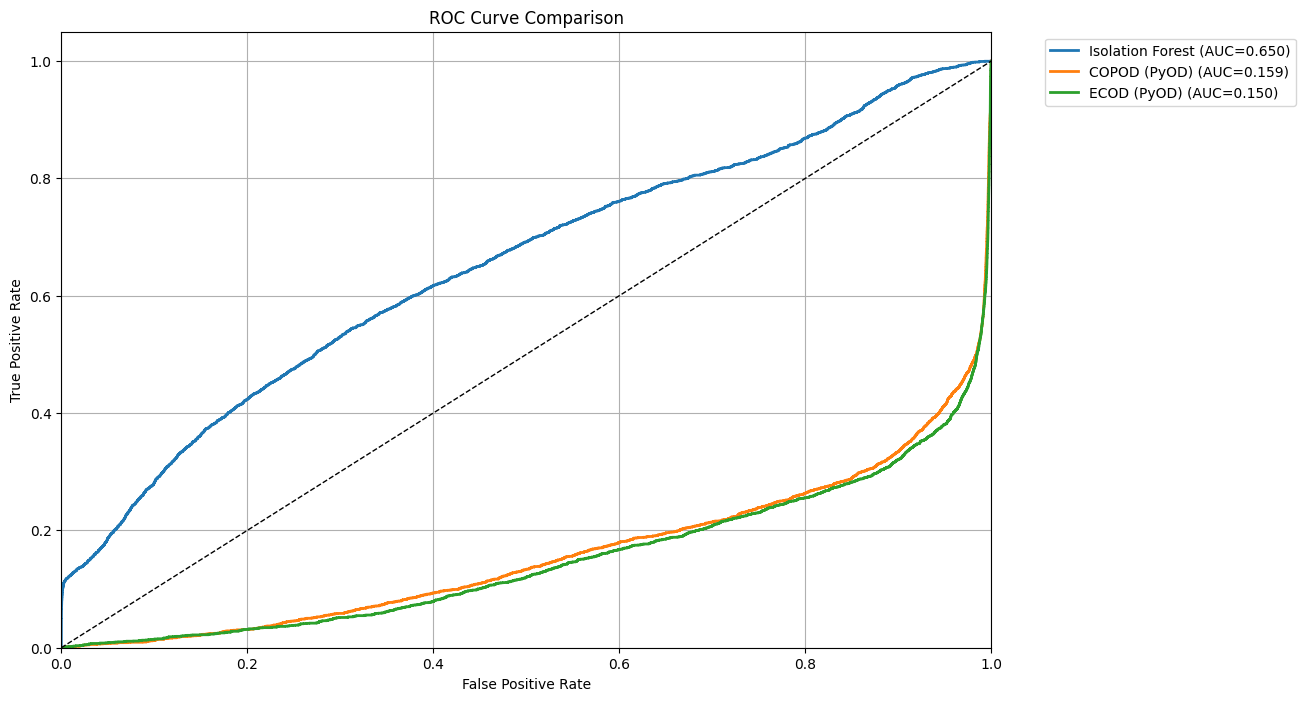

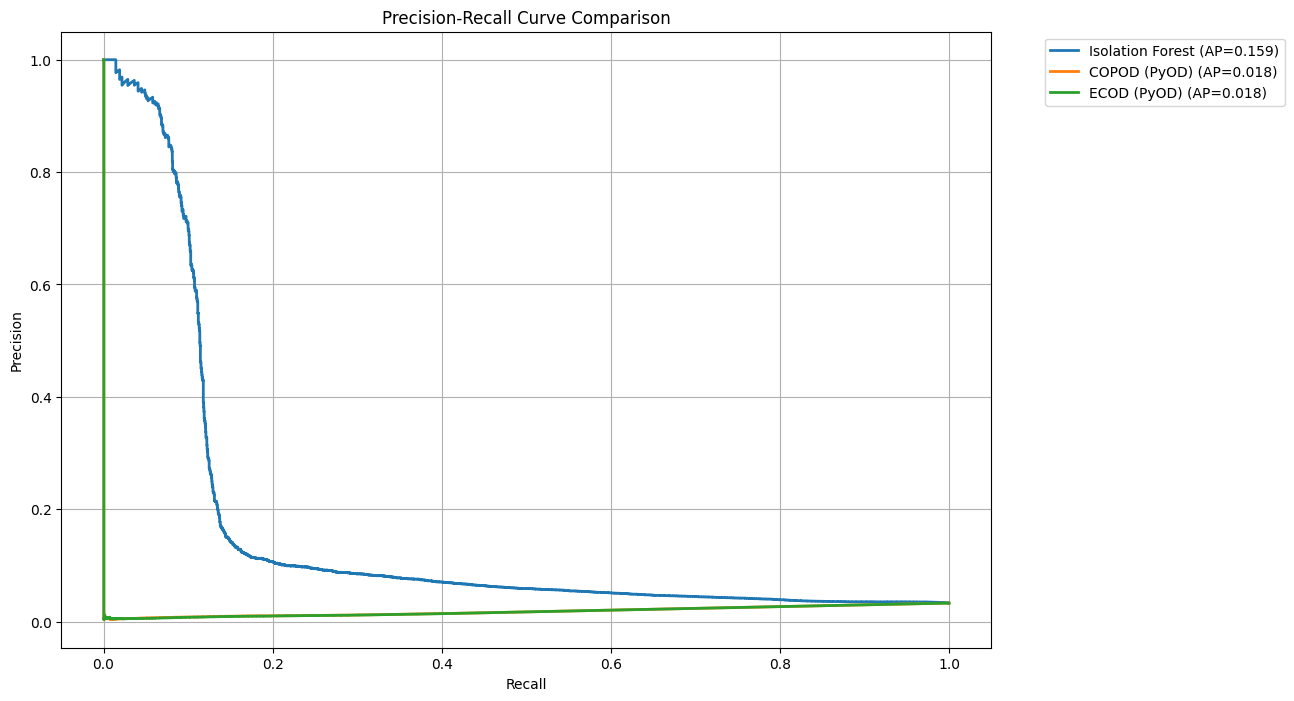

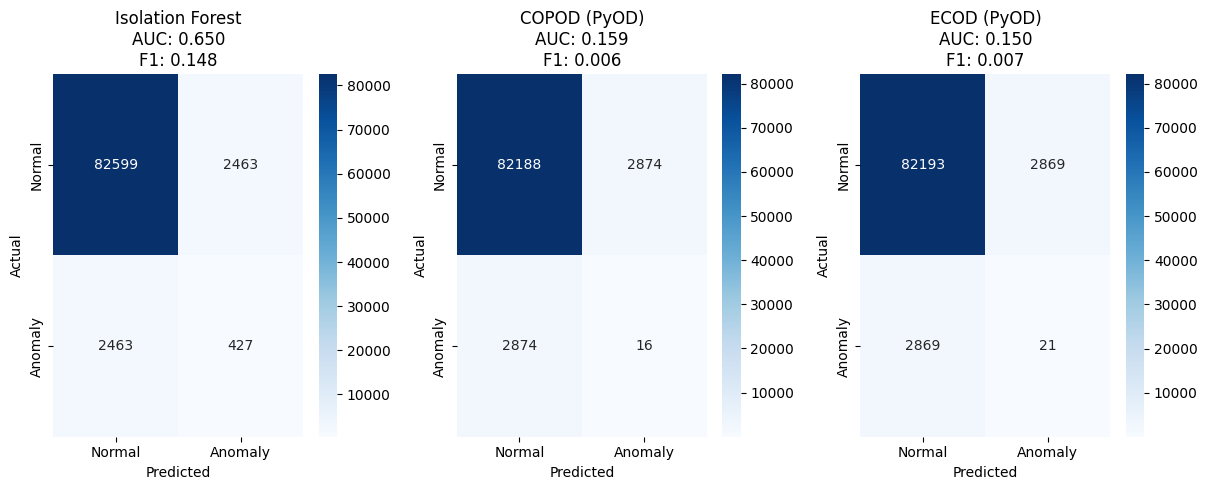

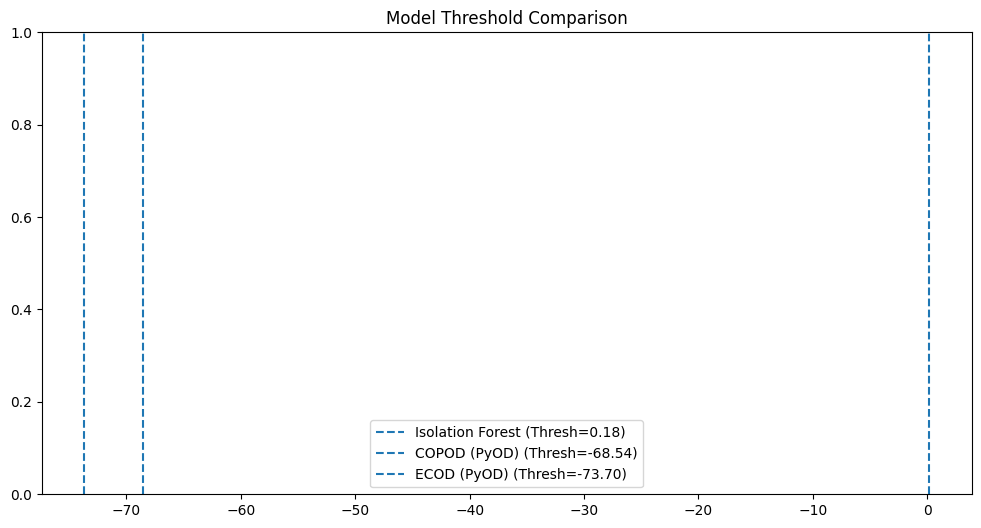

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (roc_auc_score, average_precision_score,
                           classification_report, confusion_matrix,
                           roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.lof import LOF
from tqdm import tqdm

def compare_all_models(fl_clients, X_train, X_test, y_test, contamination=0.05):
    """FL ve diğer anomali tespit modellerinin kapsamlı karşılaştırması"""

    # 1. FL istemcilerini değerlendir
    fl_results = []
    for name, client in tqdm(fl_clients.items(), desc="Evaluating FL Clients"):
        try:
            # FL istemcisi için skorları hesapla
            if hasattr(client.model, 'decision_function'):
                scores = -client.model.decision_function(X_test)
            elif hasattr(client.model, 'score_samples'):
                scores = -client.model.score_samples(X_test)
            else:
                scores = client.model.predict_proba(X_test)[:, 1]

            res = evaluate_model(scores, y_test, f"FL-{name}", contamination)
            fl_results.append(res)
        except Exception as e:
            print(f"FL Client {name} evaluation error: {str(e)}")
            continue

    # 2. Unsupervised modelleri eğit ve değerlendir
    unsupervised_results = train_unsupervised_models(X_train, X_test, y_test, contamination)

    # 3. Sonuçları görselleştir
    visualize_results(fl_results + unsupervised_results, y_test)

    return fl_results, unsupervised_results

def train_unsupervised_models(X_train, X_test, y_test, contamination):
    """Geleneksel ve modern anomali tespit modellerinin eğitimi"""
    results = []

    # Model ve parametre kombinasyonları
    models = [
        {
            'name': 'Isolation Forest',
            'model': IsolationForest(n_estimators=200,
                                   contamination=contamination,
                                   max_samples=0.8,
                                   random_state=42,
                                   n_jobs=-1,
                                   verbose=0),
            'train_on_normal_only': False
        },
        {
            'name': 'One-Class SVM',
            'model': OneClassSVM(nu=contamination,
                               kernel='rbf',
                               gamma='scale',
                               verbose=True),
            'train_on_normal_only': True
        },
        {
            'name': 'Local Outlier',
            'model': LocalOutlierFactor(n_neighbors=50,
                                      contamination=contamination,
                                      novelty=True,
                                      n_jobs=-1),
            'train_on_normal_only': True
        },
        {
            'name': 'ECOD (PyOD)',
            'model': ECOD(contamination=contamination),
            'train_on_normal_only': False
        },
        {
            'name': 'COPOD (PyOD)',
            'model': COPOD(contamination=contamination),
            'train_on_normal_only': False
        },
        {
            'name': 'LOF (PyOD)',
            'model': LOF(contamination=contamination,
                        n_neighbors=50,
                        n_jobs=-1),
            'train_on_normal_only': False
        }
    ]

    for config in tqdm(models, desc="Training Unsupervised Models"):
        try:
            # Sadece normal veriyle eğitim gerekiyorsa
            if config['train_on_normal_only']:
                train_data = X_train[y_train == 0] if 'y_train' in globals() else X_train
            else:
                train_data = X_train

            # Modeli eğit
            model = config['model'].fit(train_data)

            # Skorları hesapla
            if hasattr(model, 'decision_function'):
                scores = -model.decision_function(X_test)
            elif hasattr(model, 'score_samples'):
                scores = -model.score_samples(X_test)
            else:
                scores = model.predict_proba(X_test)[:, 1]

            # Değerlendir
            res = evaluate_model(scores, y_test, config['name'], contamination)
            results.append(res)

        except Exception as e:
            print(f"{config['name']} training error: {str(e)}")
            continue

    return results

def evaluate_model(scores, y_test, model_name, contamination):
    """Model değerlendirme için geliştirilmiş fonksiyon"""
    # ROC ve PR eğrileri
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, scores)

    # Optimal eşik değerlerini bul
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    # Contamination'e göre eşik belirleme
    threshold = np.percentile(scores, 100 * (1 - contamination))

    # Tahminleri yap
    y_pred = (scores > threshold).astype(int)

    # Metrikleri hesapla
    report = classification_report(y_test, y_pred,
                                 target_names=['Normal', 'Anomaly'],
                                 output_dict=True,
                                 zero_division=0)

    return {
        'model_name': model_name,
        'roc_auc': roc_auc_score(y_test, scores),
        'pr_auc': average_precision_score(y_test, scores),
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'anomaly_precision': report['Anomaly']['precision'],
        'anomaly_recall': report['Anomaly']['recall'],
        'anomaly_f1': report['Anomaly']['f1-score'],
        'predictions': y_pred,
        'scores': scores,
        'threshold': threshold,
        'optimal_threshold': optimal_threshold,
        'fpr': fpr,
        'tpr': tpr,
        'precision_curve': precision,
        'recall_curve': recall
    }

def visualize_results(results, y_test):
    """Geliştirilmiş görselleştirme fonksiyonu"""
    # Sonuçları DataFrame'e çevir
    df = pd.DataFrame([{
        'Model': res['model_name'],
        'ROC AUC': res['roc_auc'],
        'PR AUC': res['pr_auc'],
        'Accuracy': res['accuracy'],
        'Precision (Anomaly)': res['anomaly_precision'],
        'Recall (Anomaly)': res['anomaly_recall'],
        'F1 (Anomaly)': res['anomaly_f1'],
        'Threshold': res['threshold'],
        'Optimal Threshold': res['optimal_threshold']
    } for res in results])

    # Performans karşılaştırması
    print("\n📊 Model Performance Comparison (Sorted by ROC AUC):")
    print(df.sort_values('ROC AUC', ascending=False).to_markdown(index=False))

    # ROC eğrileri
    plt.figure(figsize=(12, 8))
    for res in sorted(results, key=lambda x: x['roc_auc'], reverse=True):
        plt.plot(res['fpr'], res['tpr'], lw=2,
                label=f"{res['model_name']} (AUC={res['roc_auc']:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

    # Precision-Recall eğrileri
    plt.figure(figsize=(12, 8))
    for res in sorted(results, key=lambda x: x['pr_auc'], reverse=True):
        plt.plot(res['recall_curve'], res['precision_curve'], lw=2,
                label=f"{res['model_name']} (AP={res['pr_auc']:.3f})")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

    # Top 5 model için confusion matrix
    top_models = sorted(results, key=lambda x: x['roc_auc'], reverse=True)[:5]
    plt.figure(figsize=(20, 5))
    for i, res in enumerate(top_models, 1):
        plt.subplot(1, 5, i)
        cm = confusion_matrix(y_test, res['predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Normal', 'Anomaly'],
                   yticklabels=['Normal', 'Anomaly'])
        plt.title(f"{res['model_name']}\nAUC: {res['roc_auc']:.3f}\nF1: {res['anomaly_f1']:.3f}")
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Threshold karşılaştırması
    plt.figure(figsize=(12, 6))
    for res in top_models:
        plt.axvline(res['threshold'], linestyle='--',
                   label=f"{res['model_name']} (Thresh={res['threshold']:.2f})")
    plt.title('Model Threshold Comparison')
    plt.legend()
    plt.show()

# Kullanım örneği
if __name__ == "__main__":
    # FL istemcileriniz (önceki kodunuzdan)
    fl_clients = {
        "Real": FLClient("Real", X_train),
        "Real+Synth": FLClient("Real+Synth", np.vstack([X_train, synthetic_data])),
        "Synth": FLClient("Synth", synthetic_data)
    }

    # Contamination oranını verinize göre ayarlayın
    contamination = y_test.mean() if 'y_test' in globals() else 0.05

    # Tüm modelleri karşılaştır
    fl_results, unsupervised_results = compare_all_models(
        fl_clients,
        X_train,
        X_test,
        y_test,
        contamination=contamination
    )

In [ ]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
# Eşit boyutta olmalılar, değilse veri yükleme kodunuzu kontrol edin

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
res['cv_auc_mean'] = np.mean(cv_scores)

In [ ]:
# Eğitim sürelerini kaydetmek için
import time
start_time = time.time()
model.fit(X_train)
res['training_time'] = time.time() - start_time

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, mean_squared_error, classification_report, confusion_matrix

class FLClient:
    def __init__(self, name, data, encoding_dim=16):
        self.name = name
        self.data = data
        self.encoding_dim = encoding_dim
        self.model = self.build_model(input_dim=data.shape[1])

    def build_model(self, input_dim):
        input_layer = Input(shape=(input_dim,))
        encoded = Dense(self.encoding_dim, activation='relu')(input_layer)
        decoded = Dense(input_dim, activation='sigmoid')(encoded)
        autoencoder = Model(inputs=input_layer, outputs=decoded)
        autoencoder.compile(optimizer='adam', loss='mse')
        return autoencoder

    def train(self, epochs=50, batch_size=32):
        print(f"\n🔧 {self.name} Autoencoder eğitiliyor...")
        early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
        self.model.fit(self.data, self.data,
                       epochs=epochs,
                       batch_size=batch_size,
                       shuffle=True,
                       callbacks=[early_stop],
                       verbose=0)

    def evaluate(self, X_test, y_test):
        reconstructions = self.model.predict(X_test)
        mse_scores = np.mean(np.square(X_test - reconstructions), axis=1)

        # Normalize skorlar
        scores_norm = (mse_scores - mse_scores.min()) / (mse_scores.max() - mse_scores.min())

        # ROC ve diğer metrikler
        auc = roc_auc_score(y_test, scores_norm)
        mse = mean_squared_error(y_test, scores_norm)

        # Eşik: %95 persentil (normal verideki)
        threshold = np.percentile(scores_norm[y_test == 0], 95)
        preds = (scores_norm > threshold).astype(int)

        report = classification_report(y_test, preds)
        cm = confusion_matrix(y_test, preds)

        return {
            'name': self.name,
            'scores': scores_norm,
            'mse': mse,
            'auc': auc,
            'report': report,
            'cm': cm
        }

    def save(self, path=None):
        if path is None:
            path = f"{self.name}_autoencoder_model.h5"
        self.model.save(path)
        print(f"✅ {self.name} modeli {path} olarak kaydedildi.")

    def load(self, path):
        self.model = load_model(path)
        print(f"📥 {self.name} modeli {path} dosyasından yüklendi.")


In [ ]:
# İstemcileri oluştur
clients = [
    FLClient("Real", X_train),
    FLClient("Real+Synthetic", np.vstack([X_train, synthetic_data])),
    FLClient("Synthetic", synthetic_data)
]

# Eğit ve kaydet
for client in clients:
    client.train()
    client.save()  # .h5 olarak kaydeder


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Değerlendirme sonuçlarını tut
results = []

for client in clients:
    result = client.evaluate(X_test, y_test)
    results.append(result)

    print(f"\n📊 {client.name} Performans Raporu:")
    print(result['report'])
    print("Confusion Matrix:")
    print(result['cm'])


In [ ]:
plt.figure(figsize=(10, 6))

for result in results:
    fpr, tpr, _ = roc_curve(y_test, result['scores'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{result['name']} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # referans çizgisi
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrileri")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
for result in results:
    scores = result['scores']
    labels = y_test
    df = pd.DataFrame({'MSE': scores, 'Label': labels})

    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x='MSE', hue='Label', bins=50, kde=True, stat="density", common_norm=False)
    plt.title(f"{result['name']} - MSE Dağılımı")
    plt.xlabel("Normalize MSE Skoru")
    plt.ylabel("Yoğunluk")
    plt.legend(labels=["Normal", "Anomali"])
    plt.grid(True)
    plt.show()


In [ ]:
import pandas as pd

summary_df = pd.DataFrame([{
    'Client': r['name'],
    'AUC': r['auc'],
    'MSE': r['mse']
} for r in results])

print("\n📌 Özet Performans Tablosu:")
print(summary_df)


In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, mean_squared_error,
                           classification_report, confusion_matrix, roc_curve)
import seaborn as sns

class FLClient:
    def __init__(self, name, data):
        self.name = name
        self.data = data
        self.model = OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")

    def train(self):
        print(f"\n🔧 {self.name} eğitiliyor...")
        self.model.fit(self.data)

    def evaluate(self, X_test, y_test):
        scores = -self.model.decision_function(X_test)  # Outlier skorları (küçük değerler anomali)

        # ROC AUC için skorları normalize et
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min())

        # MSE hesapla
        mse = mean_squared_error(y_test, scores_norm)

        # Performans metrikleri
        auc = roc_auc_score(y_test, scores_norm)
        pred = (scores_norm > np.percentile(scores_norm[y_test==0], 95)).astype(int)
        report = classification_report(y_test, pred)
        cm = confusion_matrix(y_test, pred)

        return {
            'name': self.name,
            'scores': scores_norm,
            'mse': mse,
            'auc': auc,
            'report': report,
            'cm': cm
        }

# İstemcileri oluştur
clients = [
    FLClient("Real", X_train),
    FLClient("Real+Synthetic", np.vstack([X_train, synthetic_data])),
    FLClient("Synthetic", synthetic_data)
]

# İstemcileri eğit
for client in clients:
    client.train()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import roc_curve,roc_auc_score

def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

def plot_history(history):
    losses1 = [x['val_loss1'] for x in history]
    losses2 = [x['val_loss2'] for x in history]
    plt.plot(losses1, '-x', label="loss1")
    plt.plot(losses2, '-x', label="loss2")
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.title('Losses vs. No. of epochs')
    plt.grid()
    plt.show()

def histogram(y_test,y_pred):
    plt.figure(figsize=(12,6))
    plt.hist([y_pred[y_test==0],
              y_pred[y_test==1]],
            bins=20,
            color = ['#82E0AA','#EC7063'],stacked=True)
    plt.title("Results",size=20)
    plt.grid()
    plt.show()

def ROC(y_test,y_pred):
    fpr,tpr,tr=roc_curve(y_test,y_pred)
    auc=roc_auc_score(y_test,y_pred)
    idx=np.argwhere(np.diff(np.sign(tpr-(1-fpr)))).flatten()

    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.plot(fpr,tpr,label="AUC="+str(auc))
    plt.plot(fpr,1-fpr,'r:')
    plt.plot(fpr[idx],tpr[idx], 'ro')
    plt.legend(loc=4)
    plt.grid()
    plt.show()
    return tr[idx]

def confusion_matrix(target, predicted, perc=False):

    data = {'y_Actual':    target,
            'y_Predicted': predicted
            }
    df = pd.DataFrame(data, columns=['y_Predicted','y_Actual'])
    confusion_matrix = pd.crosstab(df['y_Predicted'], df['y_Actual'], rownames=['Predicted'], colnames=['Actual'])

    if perc:
        sns.heatmap(confusion_matrix/np.sum(confusion_matrix), annot=True, fmt='.2%', cmap='Blues')
    else:
        sns.heatmap(confusion_matrix, annot=True, fmt='d')
    plt.show()

In [ ]:
import torch
import torch.nn as nn

device = get_default_device()

class Encoder(nn.Module):
  def __init__(self, in_size, latent_size):
    super().__init__()
    self.linear1 = nn.Linear(in_size, int(in_size/2))
    self.linear2 = nn.Linear(int(in_size/2), int(in_size/4))
    self.linear3 = nn.Linear(int(in_size/4), latent_size)
    self.relu = nn.ReLU(True)

  def forward(self, w):
    out = self.linear1(w)
    out = self.relu(out)
    out = self.linear2(out)
    out = self.relu(out)
    out = self.linear3(out)
    z = self.relu(out)
    return z

class Decoder(nn.Module):
  def __init__(self, latent_size, out_size):
    super().__init__()
    self.linear1 = nn.Linear(latent_size, int(out_size/4))
    self.linear2 = nn.Linear(int(out_size/4), int(out_size/2))
    self.linear3 = nn.Linear(int(out_size/2), out_size)
    self.relu = nn.ReLU(True)
    self.sigmoid = nn.Sigmoid()

  def forward(self, z):
    out = self.linear1(z)
    out = self.relu(out)
    out = self.linear2(out)
    out = self.relu(out)
    out = self.linear3(out)
    w = self.sigmoid(out)
    return w

class UsadModel(nn.Module):
  def __init__(self, w_size, z_size):
    super().__init__()
    self.encoder = Encoder(w_size, z_size)
    self.decoder1 = Decoder(z_size, w_size)
    self.decoder2 = Decoder(z_size, w_size)

  def training_step(self, batch, n):
    z = self.encoder(batch)
    w1 = self.decoder1(z)
    w2 = self.decoder2(z)
    w3 = self.decoder2(self.encoder(w1))
    loss1 = 1/n*torch.mean((batch-w1)**2)+(1-1/n)*torch.mean((batch-w3)**2)
    loss2 = 1/n*torch.mean((batch-w2)**2)-(1-1/n)*torch.mean((batch-w3)**2)
    return loss1,loss2

  def validation_step(self, batch, n):
    with torch.no_grad():
        z = self.encoder(batch)
        w1 = self.decoder1(z)
        w2 = self.decoder2(z)
        w3 = self.decoder2(self.encoder(w1))
        loss1 = 1/n*torch.mean((batch-w1)**2)+(1-1/n)*torch.mean((batch-w3)**2)
        loss2 = 1/n*torch.mean((batch-w2)**2)-(1-1/n)*torch.mean((batch-w3)**2)
    return {'val_loss1': loss1, 'val_loss2': loss2}

  def validation_epoch_end(self, outputs):
    batch_losses1 = [x['val_loss1'] for x in outputs]
    epoch_loss1 = torch.stack(batch_losses1).mean()
    batch_losses2 = [x['val_loss2'] for x in outputs]
    epoch_loss2 = torch.stack(batch_losses2).mean()
    return {'val_loss1': epoch_loss1.item(), 'val_loss2': epoch_loss2.item()}

  def epoch_end(self, epoch, result):
    print("Epoch [{}], val_loss1: {:.4f}, val_loss2: {:.4f}".format(epoch, result['val_loss1'], result['val_loss2']))

def evaluate(model, val_loader, n):
    outputs = [model.validation_step(to_device(batch,device), n) for [batch] in val_loader]
    return model.validation_epoch_end(outputs)

def training(epochs, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history = []
    optimizer1 = opt_func(list(model.encoder.parameters())+list(model.decoder1.parameters()))
    optimizer2 = opt_func(list(model.encoder.parameters())+list(model.decoder2.parameters()))
    for epoch in range(epochs):
        for [batch] in train_loader:
            batch=to_device(batch,device)

            #Train AE1
            loss1,loss2 = model.training_step(batch,epoch+1)
            loss1.backward()
            optimizer1.step()
            optimizer1.zero_grad()


            #Train AE2
            loss1,loss2 = model.training_step(batch,epoch+1)
            loss2.backward()
            optimizer2.step()
            optimizer2.zero_grad()


        result = evaluate(model, val_loader, epoch+1)
        model.epoch_end(epoch, result)
        history.append(result)
    return history

def testing(model, test_loader, alpha=.5, beta=.5):
    results=[]
    with torch.no_grad():
        for [batch] in test_loader:
            batch=to_device(batch,device)
            w1=model.decoder1(model.encoder(batch))
            w2=model.decoder2(model.encoder(w1))
            results.append(alpha*torch.mean((batch-w1)**2,axis=1)+beta*torch.mean((batch-w2)**2,axis=1))
    return results

📥 Veri yükleniyor ve ön işleme yapılıyor...
2. Zaman damgası özellikleri çıkarılıyor...
3. Sayısal olmayan sütunlar işleniyor...
  Sütun 'time' işleniyor...
    'time' sütunu sayısal hale getirilemedi veya işlenemedi. Sütun siliniyor.
  Sütun 'time' işleniyor...
    'time' sütunu sayısal hale getirilemedi veya işlenemedi. Sütun siliniyor.
4. Özellikler ve etiketler ayrılıyor...
5. Veri ölçeklendiriliyor...
⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: ['P2_Emgy', 'P2_TripEx', 'P4_HT_PS']
   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...
   Kalan özellik sayısı: 56

📊 Veri İstatistikleri:
Eğitim (processed): (444518, 56)
Test (processed): (444600, 56) (Norm: 427073, Atk: 17527)
Özellikler: 56


Training and evaluating Isolation Forest
Train Time: 0.4572 seconds
Test Time: 1.2606 seconds
Accuracy: 0.9199
Precision: 0.1326
Recall: 0.1862
F1 Score: 0.1549
AUC: 0.7564
Threshold: 0.6823


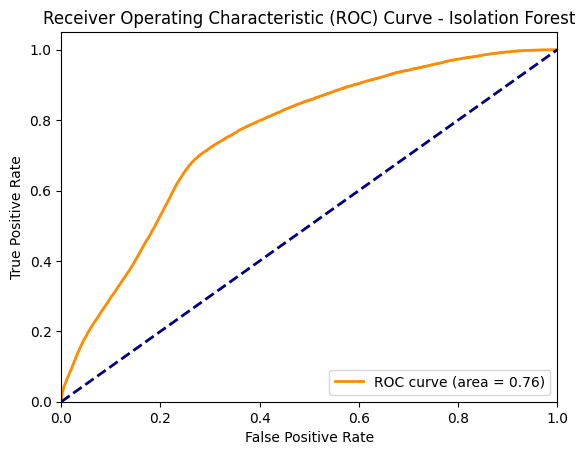

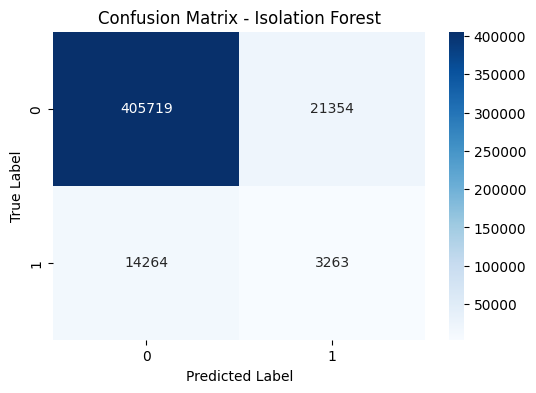


Training and evaluating Local Outlier Factor


In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Keep StandardScaler as an option
from sklearn.preprocessing import MinMaxScaler # Use MinMaxScaler as per your notebook
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC, OneClassSVM
import seaborn as sns # For better confusion matrix visualization

# Re-use the data loading and preprocessing function from your notebook
def load_and_preprocess_data(train_df, test_df, sample_size=None):
    """Veriyi yükleyip ön işleme yapar"""
    print("📥 Veri yükleniyor ve ön işleme yapılıyor...")

    # Use the dataframes passed into the function
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Identify columns present in both dataframes for consistent processing
    # After your previous steps, 'attack' is in test_df but not train_df
    # We will handle this when separating features/labels
    all_cols_train = set(train_df.columns)
    all_cols_test = set(test_df.columns)

    # 1. Zaman damgası işleme ve özellik çıkarımı
    print("2. Zaman damgası özellikleri çıkarılıyor...")
    for df in [train_df, test_df]:
        if 'Timestamp' in df.columns:
            print("  Timestamp sütunu işleniyor...")
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            df['Hour'] = df['Timestamp'].dt.hour
            df['Day'] = df['Timestamp'].dt.dayofweek
            df['Minute'] = df['Timestamp'].dt.minute
            df['Second'] = df['Timestamp'].dt.second
            df.drop('Timestamp', axis=1, inplace=True)
            df.fillna({'Hour': 0, 'Day': 0, 'Minute': 0, 'Second': 0}, inplace=True)

    # 2. Kategorik değişkenleri kontrol et ve dönüştür / Sayısal olmayan sütunları işle
    print("3. Sayısal olmayan sütunlar işleniyor...")
    for df in [train_df, test_df]:
        object_cols = df.select_dtypes(include='object').columns
        for col in object_cols:
            print(f"  Sütun '{col}' işleniyor...")
            df[col] = pd.to_numeric(df[col], errors='coerce')
            if df[col].isna().any() or df[col].dtype == 'object':
                 print(f"    '{col}' sütunu sayısal hale getirilemedi veya işlenemedi. Sütun siliniyor.")
                 df.drop(col, axis=1, inplace=True)
            else:
                 print(f"    '{col}' sütunu sayısal hale getirildi. NaN değerleri dolduruluyor (0 ile).")
                 df[col].fillna(0, inplace=True)

    # After processing, find common columns again BEFORE splitting features/labels
    common_cols_after_process = list(set(train_df.columns) & set(test_df.columns))

    # 3. Özellikler ve etiketler
    print("4. Özellikler ve etiketler ayrılıyor...")

    # Define feature columns: all common columns except 'attack' if present
    # train_df does not have 'attack', so feature_cols for train are all its columns
    feature_cols_train = [c for c in train_df.columns if c != 'attack']
    # test_df has 'attack', so feature_cols for test are all its columns except 'attack'
    feature_cols_test = [c for c in test_df.columns if c != 'attack']

    # Ensure the final feature columns are present in BOTH dataframes AFTER processing
    final_feature_cols = list(set(feature_cols_train) & set(feature_cols_test))
    final_feature_cols.sort()

    # Ensure 'attack' column exists in test_df before assigning y_test
    if 'attack' not in test_df.columns:
        raise ValueError("Test verisinde 'attack' sütunu bulunamadı. Lütfen veri yükleme ve ön işleme adımlarını kontrol edin.")

    X_train = train_df[final_feature_cols].values
    X_test = test_df[final_feature_cols].values
    y_test = test_df['attack'].values.ravel() # y_test is from test data

    # 4. İsteğe bağlı örnekleme (Bu kısım genellikle FL için kullanılır, burada gerek olmayabilir)
    if sample_size:
        print(f"⚠️ Veri {sample_size} örneğe indirgeniyor (Sadece train için uygulanıyor)")
        # Apply sampling only to the training data (X_train)
        if X_train.shape[0] > sample_size:
             indices = np.random.choice(X_train.shape[0], size=sample_size, replace=False)
             X_train = X_train[indices]
             # Since we are only sampling train for model training, y_train is not used in this specific context
             # but if it were, we would sample y_train as well.
             # y_train = y_train[indices] # Uncomment if y_train is needed for supervised train

        # Note: X_test and y_test are used for evaluation and are not sampled here
        # based on the original FL function logic, keep the full test set for evaluation.


    # 5. Ölçeklendirme
    print("5. Veri ölçeklendiriliyor...")
    # Use MinMaxScaler as in your notebook
    scaler = MinMaxScaler(feature_range=(-1, 1))

    # Check for columns with single unique value (constant columns) in X_train
    variances = np.var(X_train, axis=0)
    constant_features_indices = np.where(variances == 0)[0]

    if len(constant_features_indices) > 0:
        constant_col_names = [final_feature_cols[i] for i in constant_features_indices]
        print(f"⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: {constant_col_names}")
        print("   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...")

        non_constant_features_mask = np.ones(X_train.shape[1], dtype=bool)
        non_constant_features_mask[constant_features_indices] = False

        X_train = X_train[:, non_constant_features_mask]
        X_test = X_test[:, non_constant_features_mask]
        final_feature_cols = [final_feature_cols[i] for i in np.where(non_constant_features_mask)[0]]
        print(f"   Kalan özellik sayısı: {X_train.shape[1]}")

    X_train = scaler.fit_transform(X_train)
    # Ensure X_test is transformed using the scaler fitted on X_train
    X_test = scaler.transform(X_test)

    # Handle potential NaNs/Infs after scaling, although MinMaxScaler should handle this well
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
    y_test = np.nan_to_num(y_test, nan=0, posinf=0, neginf=0).astype(int) # Ensure y_test is clean integers

    # Veri istatistikleri
    print("\n📊 Veri İstatistikleri:")
    print(f"Eğitim (processed): {X_train.shape}")
    print(f"Test (processed): {X_test.shape} (Norm: {sum(y_test==0)}, Atk: {sum(y_test==1)})")
    print(f"Özellikler: {len(final_feature_cols)}\n")

    # For supervised models, we need y_train. In your notebook, train had no 'attack' column.
    # For anomaly detection (like OneClassSVM, IsolationForest, LOF), the training data
    # is typically assumed to be mostly "normal". So we can train these models
    # directly on X_train (which has no attack label).
    # Supervised models like RF, XGBoost, Logistic Regression, etc., would require
    # labeled training data (X_train, y_train). If you have labeled training data,
    # you would need to load it differently or adapt this function.
    # Assuming for now you want to train AD models on your unlabeled train data
    # and evaluate on the labeled test data.

    return X_train, y_test, X_test, final_feature_cols, scaler # Note: y_train is not returned


# Model training and evaluation function adapted for anomaly detection
def train_evaluate_model_ad(model, model_name, X_train, X_test, y_test):
    print(f"\n{'='*50}")
    print(f"Training and evaluating {model_name}")
    print(f"{'='*50}")

    start_time = time.time()

    # Anomaly Detection Models: Train on (mostly) normal data (X_train)
    model.fit(X_train)
    train_time = time.time() - start_time

    start_time = time.time()

    # For AD models, we typically get a score or a prediction (-1 for outlier, 1 for inlier)
    # Get anomaly scores (lower score usually means more anomalous)
    if hasattr(model, "decision_function"): # OneClassSVM, IsolationForest have decision_function
        scores = -model.decision_function(X_test) # Negative score to make higher == more anomalous
    elif hasattr(model, "negative_outlier_factor_"): # LOF
         # Need to fit LOF on X_test as well to get scores on X_test itself
         # LOF predicts based on local density relative to neighbors in the test set
         # A common practice for LOF is to train on normal data and then predict on test
         # using the fit model. However, LOF's predict/decision_function needs data points
         # to be evaluated on. If X_test is completely separate, the logic is slightly different.
         # Let's assume we fit on train and predict on test. LOF's .fit_predict gives -1/1.
         # For scores, we use .negative_outlier_factor_ which is only available *after* fitting
         # on the data you want scores for. A simpler approach for evaluation on X_test
         # with LOF trained on X_train might involve fitting LOF *again* on X_test
         # or using predict/decision_function if the model supports it correctly for out-of-sample data.
         # Let's use a simplified approach for now and focus on models with decision_function.
         # If using LOF, you might need a different scoring mechanism depending on the library version.
         # For robustness, let's stick to models with clear decision_function for scores.
         if model_name == "Local Outlier Factor":
             print("⚠️ LOF scoring requires careful consideration for out-of-sample data.")
             print("   Using fit_predict for LOF evaluation as a placeholder.")
             # Fit LOF on X_test to get scores/predictions on X_test
             lof_eval = LocalOutlierFactor(n_neighbors=model.n_neighbors, contamination=model.contamination, novelty=True) # novelty=True for out-of-sample
             lof_eval.fit(X_train) # Train on normal data
             y_pred_lof = lof_eval.predict(X_test) # Predict on test data (-1 or 1)
             # Convert predictions to anomaly scores (e.g., 1 for normal, 0 for anomaly, or similar)
             # A simple score could be mapping -1 to 1 and 1 to 0 (or vice versa)
             scores = np.where(y_pred_lof == -1, 1, 0) # Map anomaly (-1) to score 1, normal (1) to score 0
         else:
             scores = np.zeros(len(X_test)) # Placeholder for other models without decision_function

    elif hasattr(model, "predict"): # Supervised models might be included, but we are using AD function
         print("⚠️ Model does not have decision_function or negative_outlier_factor_. Using predict output as score (binary).")
         scores = model.predict(X_test) # Binary prediction (0 or 1)


    test_time = time.time() - start_time

    # Normalize scores for consistent comparison and thresholding
    # Handle cases where scores might be constant (e.g., if all test data are the same)
    if np.std(scores) < 1e-10:
        print("⚠️ Anomaly scores have zero variance. Cannot normalize.")
        scores_norm = scores # Use raw scores if normalization is not possible
        # If all scores are the same, AUC might not be well-defined or 0.5
    else:
        scores_norm = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

    # Determine a threshold based on the scores of normal data in the test set
    # Assuming normal instances (y_test == 0) are present in the test set
    scores_normal = scores_norm[y_test == 0]

    if len(scores_normal) == 0 or np.all(np.isnan(scores_normal)):
        print("⚠️ No normal samples in test set with valid scores to determine threshold. Using default 0.5.")
        threshold = 0.5
    else:
        # Use the 95th percentile of scores for normal data as the threshold
        # This means 5% of normal data will be classified as anomalies
        # You can adjust this percentile based on your tolerance for false positives
        scores_normal_clean = scores_normal[~np.isnan(scores_normal)]
        if len(scores_normal_clean) > 0:
             threshold = np.percentile(scores_normal_clean, 95)
        else:
             print("⚠️ Cleaned normal scores are empty. Using default 0.5.")
             threshold = 0.5


    # Convert normalized scores to binary predictions using the threshold
    y_pred = (scores_norm > threshold).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, scores_norm) # Use normalized scores for AUC

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"Train Time: {train_time:.4f} seconds")
    print(f"Test Time: {test_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC: {auc_score:.4f}")
    print(f"Threshold: {threshold:.4f}")

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, scores_norm)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return {
        'model_name': model_name,
        'train_time': train_time,
        'test_time': test_time,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc': auc_score,
        'confusion_matrix': cm,
        'roc_curve': (fpr, tpr),
        'threshold': threshold
    }

# --- Main Execution ---

# Load and preprocess your HAI data using the existing notebook function
# Assuming 'train' and 'test' DataFrames from your notebook are available
if 'train' not in locals() or 'test' not in locals():
    print("Loading data using initial read_csv...")
    try:
        train = pd.read_csv('/content/train.csv')
        test = pd.read_csv('/content/test.csv', sep=';')
        # Reapply attack column creation for test if needed
        if 'attack' not in test.columns:
             print("Recreating 'attack' column in test data...")
             attack_p_columns = [col for col in test.columns if "attack_P" in col]
             test = test.copy()
             test['attack'] = 0
             for col in attack_p_columns:
                test.loc[test[col] != 0, 'attack'] = 1
             test = test.drop(columns=attack_p_columns, errors='ignore')
             # Ensure 'attack' column in train is dropped if it exists
             train = train.drop(columns=[col for col in train.columns if "attack" in col], errors='ignore')

        # Re-apply fillna for train as done in your notebook
        train.fillna(0, inplace=True)
        # Decide how to handle NaNs in the original test BEFORE preprocessing
        # If needed, add fillna here based on your notebook's original test handling

    except FileNotFoundError:
        print("Error: train.csv or test.csv not found. Please ensure they are uploaded.")
        exit()
    except Exception as e:
        print(f"Error loading or preparing dataframes: {e}")
        exit()


# Load and preprocess data using your function
# This function returns X_train (unlabeled for AD), y_test (labels for test), X_test (features for test)
# It also handles scaling and feature selection based on constant values in train.
X_train_processed, y_test_processed, X_test_processed, feature_names_processed, scaler_used = load_and_preprocess_data(train, test)


# Define Anomaly Detection models to evaluate
# We will focus on models that can be trained on unlabeled data (X_train_processed)
# and evaluated on labeled test data (X_test_processed, y_test_processed).
models_to_evaluate = [
    (IsolationForest(contamination='auto', random_state=42), "Isolation Forest"),
    (LocalOutlierFactor(n_neighbors=20, contamination='auto', novelty=True), "Local Outlier Factor"), # novelty=True for prediction on new data
    (OneClassSVM(nu=0.05, kernel="rbf", gamma="auto"), "One-Class SVM")
]

# Evaluate each model
all_results = []
for model, name in models_to_evaluate:
    results = train_evaluate_model_ad(model, name, X_train_processed, X_test_processed, y_test_processed)
    all_results.append(results)

# --- Summary of Results ---
print("\n\n{'='*50}")
print("Summary of Anomaly Detection Model Performance")
print("{'='*50}")

results_summary = pd.DataFrame({
    'Model': [res['model_name'] for res in all_results],
    'AUC': [res['auc'] for res in all_results],
    'Accuracy': [res['accuracy'] for res in all_results],
    'Precision': [res['precision'] for res in all_results],
    'Recall': [res['recall'] for res in all_results],
    'F1 Score': [res['f1_score'] for res in all_results],
    'Train Time (s)': [res['train_time'] for res in all_results],
    'Test Time (s)': [res['test_time'] for res in all_results],
    'Threshold': [res['threshold'] for res in all_results]
})

print(results_summary.sort_values(by='AUC', ascending=False))

# Optional: Plot all ROC curves on a single plot for comparison
plt.figure(figsize=(10, 6))
for res in all_results:
    fpr, tpr = res['roc_curve']
    plt.plot(fpr, tpr, lw=2, label=f"{res['model_name']} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Anomaly Detection Models')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

📥 Veri yükleniyor ve ön işleme yapılıyor...
2. Zaman damgası özellikleri çıkarılıyor...
3. Sayısal olmayan sütunlar işleniyor...
  Sütun 'time' işleniyor...
    'time' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.
  Sütun 'time' işleniyor...
    'time' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.
4. Özellikler ve etiketler ayrılıyor...
5. Veri ölçeklendiriliyor...
⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: ['P2_Emgy', 'P2_TripEx', 'P4_HT_PS']
   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...
   Kalan özellik sayısı: 56

📊 Veri İstatistikleri:
Eğitim: (444518, 56)
Test: (444600, 56) (Norm: 427073, Atk: 17527)
Özellikler: 56


🏋️‍♀️ Training Isolation Forest...
✅ Isolation Forest training finished in 0.99 seconds.
🔍 Evaluating Isolation Forest...
✅ Isolation Forest evaluation finished in 1.32 seconds.

📊 Isolation Forest Results:
AUC: 0.7564
Threshold (based on normal test data 95th percen

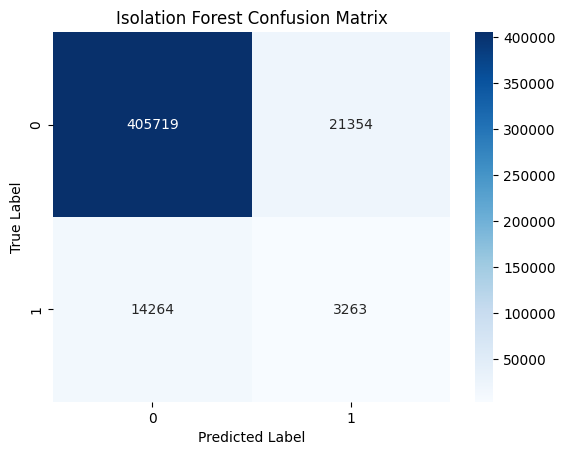


🏋️‍♀️ Training Local Outlier Factor...


IndexError: boolean index did not match indexed array along axis 0; size of axis is 444518 but size of corresponding boolean axis is 444600

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, accuracy_score,
                           precision_score, recall_score,
                           f1_score, roc_curve,
                           classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import psutil

# --- Your existing data loading and preprocessing function ---
# (Assuming load_and_preprocess_data is defined as in your notebook)

# Re-define the load_and_preprocess_data function if it's not already in the current session
# or if you are running this as a standalone cell.
def load_and_preprocess_data(train_df, test_df, sample_size=None):
    """Veriyi yükleyip ön işleme yapar"""
    print("📥 Veri yükleniyor ve ön işleme yapılıyor...")

    train_df = train.copy()
    test_df = test.copy()

    # Identify columns present in both dataframes for consistent processing
    common_cols = list(set(train_df.columns) & set(test_df.columns))

    # 1. Zaman damgası işleme ve özellik çıkarımı
    print("2. Zaman damgası özellikleri çıkarılıyor...")
    for df in [train_df, test_df]:
        if 'Timestamp' in df.columns:
            print("  Timestamp sütunu işleniyor...")
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            df['Hour'] = df['Timestamp'].dt.hour
            df['Day'] = df['Timestamp'].dt.dayofweek
            df['Minute'] = df['Timestamp'].dt.minute
            df['Second'] = df['Timestamp'].dt.second
            df.drop('Timestamp', axis=1, inplace=True)
            df.fillna({'Hour': 0, 'Day': 0, 'Minute': 0, 'Second': 0}, inplace=True)


    # 2. Kategorik değişkenleri kontrol et ve dönüştür / Sayısal olmayan sütunları işle
    print("3. Sayısal olmayan sütunlar işleniyor...")
    for df in [train_df, test_df]:
        object_cols = df.select_dtypes(include='object').columns
        for col in object_cols:
            print(f"  Sütun '{col}' işleniyor...")
            df[col] = pd.to_numeric(df[col], errors='coerce')
            if df[col].isna().any() or df[col].dtype == 'object':
                 print(f"    '{col}' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.")
                 df.drop(col, axis=1, inplace=True)
            else:
                 print(f"    '{col}' sütunu sayısal hale getirildi. NaN değerleri dolduruluyor (0 ile).")
                 df[col].fillna(0, inplace=True)


    # Ensure both dataframes have the same columns after processing
    processed_common_cols = list(set(train_df.columns) & set(test_df.columns))
    train_df = train_df[processed_common_cols]


    # 3. Özellikler ve etiketler
    print("4. Özellikler ve etiketler ayrılıyor...")
    feature_cols = [c for c in train_df.columns if c != 'attack']
    if 'attack' not in test_df.columns:
         raise ValueError("Test verisinde 'attack' sütunu bulunamadı. Lütfen veri yükleme ve ön işleme adımlarını kontrol edin.")

    test_feature_cols = [c for c in test_df.columns if c != 'attack']
    final_feature_cols = list(set(feature_cols) & set(test_feature_cols))
    final_feature_cols.sort()

    X_train = train_df[final_feature_cols].values
    X_test = test_df[final_feature_cols].values
    y_test = test_df['attack'].values.ravel()

    # 4. İsteğe bağlı örnekleme
    if sample_size:
        print(f"⚠️ Veri {sample_size} örneğe indirgeniyor")
        X_train = X_train[:sample_size]
        X_test = X_test[:sample_size//3]
        y_test = y_test[:sample_size//3]

    # 5. Ölçeklendirme
    print("5. Veri ölçeklendiriliyor...")
    scaler = MinMaxScaler(feature_range=(-1, 1))

    variances = np.var(X_train, axis=0)
    constant_features_indices = np.where(variances == 0)[0]

    if len(constant_features_indices) > 0:
        constant_col_names = [final_feature_cols[i] for i in constant_features_indices]
        print(f"⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: {constant_col_names}")
        print("   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...")
        non_constant_features_mask = np.ones(X_train.shape[1], dtype=bool)
        non_constant_features_mask[constant_features_indices] = False
        X_train = X_train[:, non_constant_features_mask]
        X_test = X_test[:, non_constant_features_mask]
        final_feature_cols = [final_feature_cols[i] for i in np.where(non_constant_features_mask)[0]]
        print(f"   Kalan özellik sayısı: {X_train.shape[1]}")

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print("\n📊 Veri İstatistikleri:")
    print(f"Eğitim: {X_train.shape}")
    print(f"Test: {X_test.shape} (Norm: {sum(y_test==0)}, Atk: {sum(y_test==1)})")
    print(f"Özellikler: {len(final_feature_cols)}\n")

    return X_train, X_test, y_test, final_feature_cols, scaler

# Assuming 'train' and 'test' dataframes are already loaded from your notebook
# If not, uncomment and run the necessary cells to load them.
test = pd.read_csv('/content/test.csv', sep = ';')
train = pd.read_csv('/content/train.csv')
train = train.drop(columns=[col for col in train.columns if "attack" in col], errors='ignore')
train.fillna(0, inplace=True)
attack_p_columns = [col for col in test.columns if "attack_P" in col]
test = test.copy()
test['attack'] = 0
for col in attack_p_columns:
    test.loc[test[col] != 0, 'attack'] = 1
test = test.drop(columns=attack_p_columns, errors='ignore')


# --- Data Loading and Preprocessing ---
X_train, X_test, y_test, final_feature_cols, scaler = load_and_preprocess_data(train, test)

# Handle potential NaNs introduced during scaling or previous steps
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
y_test = np.asarray(y_test) # Ensure y_test is a numpy array

# --- Model Training and Evaluation ---

models = {
    "Isolation Forest": IsolationForest(contamination='auto', random_state=42),
    "Local Outlier Factor": LocalOutlierFactor(novelty=True, contamination='auto'), # novelty=True for prediction on new data
    "One-Class SVM": OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
}

results = {}

for name, model in models.items():
    print(f"\n🏋️‍♀️ Training {name}...")
    start_time = time.time()

    if name == "Local Outlier Factor":
         # LOF with novelty=True is trained on the normal data
         model.fit(X_train[y_test == 0]) # Assuming training data is mostly normal
    else:
        model.fit(X_train) # Isolation Forest and One-Class SVM trained on the whole training set

    train_time = time.time() - start_time
    print(f"✅ {name} training finished in {train_time:.2f} seconds.")

    print(f"🔍 Evaluating {name}...")
    start_time = time.time()

    if name == "Local Outlier Factor":
        # LOF predicts anomaly scores using decision_function
        scores = -model.decision_function(X_test)
    else:
        # Isolation Forest uses decision_function for anomaly scores
        # One-Class SVM uses decision_function for anomaly scores
        scores = -model.decision_function(X_test)

    eval_time = time.time() - start_time
    print(f"✅ {name} evaluation finished in {eval_time:.2f} seconds.")


    # Normalize scores for consistent thresholding and comparison
    scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)

    # Determine threshold based on the 95th percentile of scores for normal data in the test set
    # Assuming anomalies are the higher scores
    scores_normal_test = scores_norm[y_test == 0]
    if len(scores_normal_test) > 0 and not np.isnan(scores_normal_test).all():
        threshold = np.percentile(scores_normal_test[~np.isnan(scores_normal_test)], 95) # Use 95th percentile for threshold
    else:
        print(f"⚠️ Warning: Cannot determine threshold for {name} from normal test data. Using default 0.5.")
        threshold = 0.5 # Fallback threshold

    # Predict anomalies based on the threshold
    pred = (scores_norm > threshold).astype(int)

    # Ensure y_test and pred are clean for metrics
    y_test_clean = np.nan_to_num(y_test, nan=0.0).astype(int)
    pred_clean = np.nan_to_num(pred, nan=0.0).astype(int)

    # Calculate metrics
    auc = roc_auc_score(y_test_clean, scores_norm)
    cm = confusion_matrix(y_test_clean, pred_clean)
    report = classification_report(y_test_clean, pred_clean, output_dict=True)

    results[name] = {
        'scores': scores_norm,
        'auc': auc,
        'cm': cm,
        'report': report,
        'threshold': threshold
    }

    print(f"\n📊 {name} Results:")
    print(f"AUC: {auc:.4f}")
    print(f"Threshold (based on normal test data 95th percentile): {threshold:.4f}")
    print(classification_report(y_test_clean, pred_clean))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


# --- Visualization ---

# Plot ROC curves for all models
plt.figure(figsize=(10, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(np.nan_to_num(y_test, nan=0.0).astype(int), res['scores'])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Summarize results
print("\n🏆 Model Performance Summary:")
for name, res in sorted(results.items(), key=lambda item: item[1]['auc'], reverse=True):
    print(f"{name:<25} | AUC: {res['auc']:.4f} | Precision (Anomaly): {res['report']['1']['precision']:.4f} | Recall (Anomaly): {res['report']['1']['recall']:.4f} | F1-Score (Anomaly): {res['report']['1']['f1-score']:.4f}")

# Optional: Save results to a CSV
results_summary = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC': [res['auc'] for res in results.values()],
    'Precision_Anomaly': [res['report']['1']['precision'] for res in results.values()],
    'Recall_Anomaly': [res['report']['1']['recall'] for res in results.values()],
    'F1_Score_Anomaly': [res['report']['1']['f1-score'] for res in results.values()]
})
results_summary.to_csv("anomaly_detection_model_performance.csv", index=False)
print("\nModel performance saved to 'anomaly_detection_model_performance.csv'")

📥 Veri yükleniyor ve ön işleme yapılıyor...
2. Zaman damgası özellikleri çıkarılıyor...
3. Sayısal olmayan sütunlar işleniyor...
  Sütun 'time' işleniyor...
    'time' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.
  Sütun 'time' işleniyor...
    'time' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.
4. Özellikler ve etiketler ayrılıyor...
5. Veri ölçeklendiriliyor...
⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: ['P2_Emgy', 'P2_TripEx', 'P4_HT_PS']
   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...
   Kalan özellik sayısı: 56

📊 Veri İstatistikleri:
Eğitim: (399117, 56)
Test: (299398, 56) (Norm: 287473, Atk: 11925)
Özellikler: 56


🏋️‍♀️ Training Isolation Forest...
✅ Isolation Forest training finished in 1.30 seconds.
🔍 Evaluating Isolation Forest...
✅ Isolation Forest evaluation finished in 1.80 seconds.

📊 Isolation Forest Results:
AUC: 0.7064
Threshold (based on normal test data 95th percen

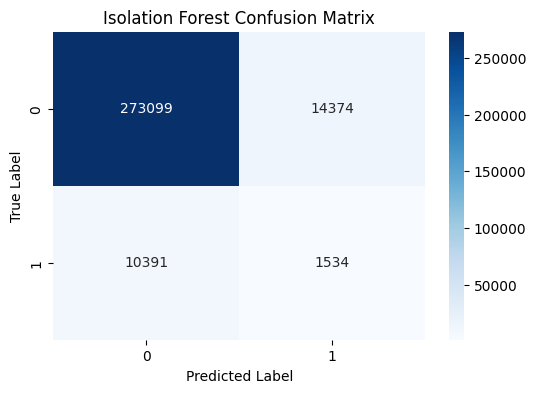


🏋️‍♀️ Training Local Outlier Factor...
✅ Local Outlier Factor training finished in 1502.98 seconds.
🔍 Evaluating Local Outlier Factor...
✅ Local Outlier Factor evaluation finished in 1114.74 seconds.

📊 Local Outlier Factor Results:
AUC: 0.8535
Threshold (based on normal test data 95th percentile): 0.1199
              precision    recall  f1-score   support

           0       0.98      0.95      0.96    287473
           1       0.30      0.51      0.38     11925

    accuracy                           0.93    299398
   macro avg       0.64      0.73      0.67    299398
weighted avg       0.95      0.93      0.94    299398



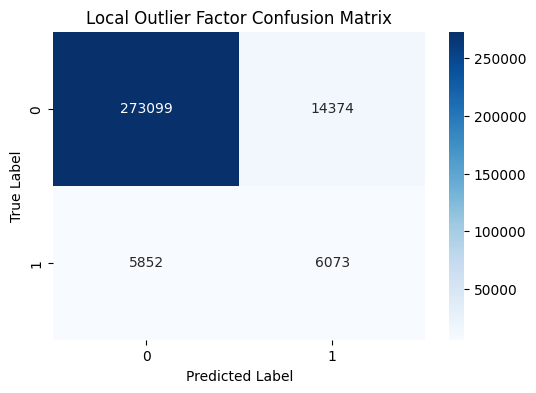


🏋️‍♀️ Training One-Class SVM...
✅ One-Class SVM training finished in 3432.40 seconds.
🔍 Evaluating One-Class SVM...
✅ One-Class SVM evaluation finished in 602.60 seconds.

📊 One-Class SVM Results:
AUC: 0.7183
Threshold (based on normal test data 95th percentile): 0.1405
              precision    recall  f1-score   support

           0       0.98      0.95      0.96    287473
           1       0.28      0.47      0.35     11925

    accuracy                           0.93    299398
   macro avg       0.63      0.71      0.66    299398
weighted avg       0.95      0.93      0.94    299398



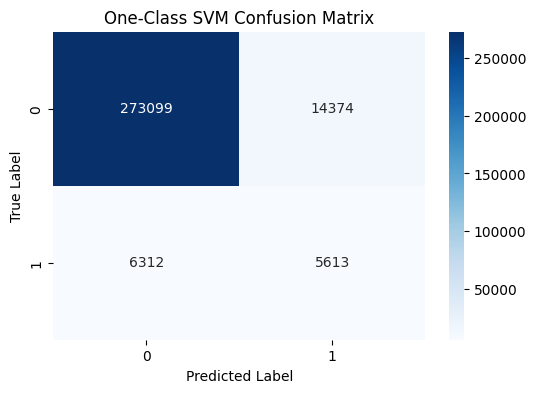

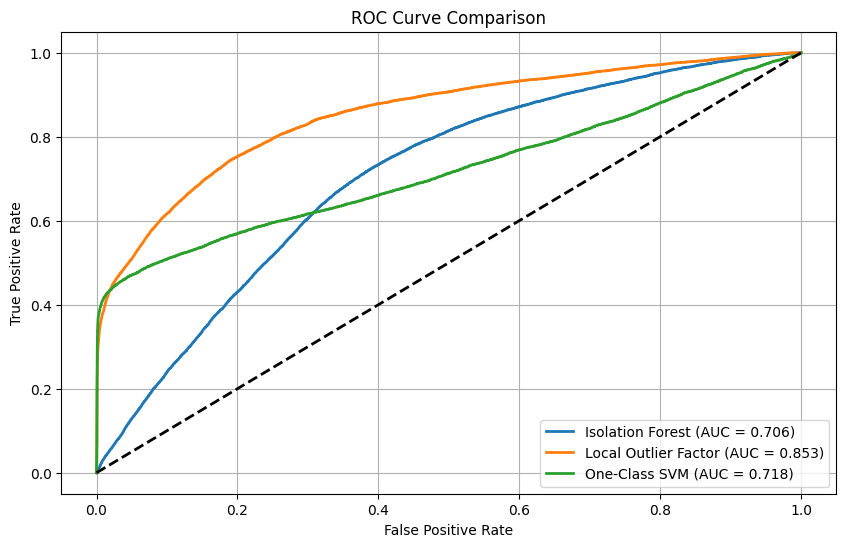


🏆 Model Performance Summary:


ValueError: Invalid format specifier '.4f if not np.isnan(auc_val) else 'N/A ':>5' for object of type 'float'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, accuracy_score,
                           precision_score, recall_score,
                           f1_score, roc_curve,
                           classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import psutil

# --- Your existing data loading and preprocessing function ---
# (Assuming load_and_preprocess_data is defined as in your notebook)

# Re-define the load_and_preprocess_data function if it's not already in the current session
# or if you are running this as a standalone cell.
def load_and_preprocess_data(train_df, test_df, sample_size=None):
    """Veriyi yükleyip ön işleme yapar"""
    print("📥 Veri yükleniyor ve ön işleme yapılıyor...")

    train_df = train.copy()
    test_df = test.copy()

    # Identify columns present in both dataframes for consistent processing
    common_cols = list(set(train_df.columns) & set(test_df.columns))

    # 1. Zaman damgası işleme ve özellik çıkarımı
    print("2. Zaman damgası özellikleri çıkarılıyor...")
    for df in [train_df, test_df]:
        if 'Timestamp' in df.columns:
            print("  Timestamp sütunu işleniyor...")
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            df['Hour'] = df['Timestamp'].dt.hour
            df['Day'] = df['Timestamp'].dt.dayofweek
            df['Minute'] = df['Timestamp'].dt.minute
            df['Second'] = df['Timestamp'].dt.second
            df.drop('Timestamp', axis=1, inplace=True)
            df.fillna({'Hour': 0, 'Day': 0, 'Minute': 0, 'Second': 0}, inplace=True)


    # 2. Kategorik değişkenleri kontrol et ve dönüştür / Sayısal olmayan sütunları işle
    print("3. Sayısal olmayan sütunlar işleniyor...")
    for df in [train_df, test_df]:
        object_cols = df.select_dtypes(include='object').columns
        for col in object_cols:
            print(f"  Sütun '{col}' işleniyor...")
            df[col] = pd.to_numeric(df[col], errors='coerce')
            if df[col].isna().any() or df[col].dtype == 'object':
                 print(f"    '{col}' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.")
                 df.drop(col, axis=1, inplace=True)
            else:
                 print(f"    '{col}' sütunu sayısal hale getirildi. NaN değerleri dolduruluyor (0 ile).")
                 df[col].fillna(0, inplace=True)


    # Ensure both dataframes have the same columns after processing
    processed_common_cols = list(set(train_df.columns) & set(test_df.columns))
    train_df = train_df[processed_common_cols]


    # 3. Özellikler ve etiketler
    print("4. Özellikler ve etiketler ayrılıyor...")
    feature_cols = [c for c in train_df.columns if c != 'attack']
    if 'attack' not in test_df.columns:
         raise ValueError("Test verisinde 'attack' sütunu bulunamadı. Lütfen veri yükleme ve ön işleme adımlarını kontrol edin.")

    test_feature_cols = [c for c in test_df.columns if c != 'attack']
    final_feature_cols = list(set(feature_cols) & set(test_feature_cols))
    final_feature_cols.sort()

    X_train = train_df[final_feature_cols].values
    X_test = test_df[final_feature_cols].values
    y_test = test_df['attack'].values.ravel()

    # 4. İsteğe bağlı örnekleme
    if sample_size:
        print(f"⚠️ Veri {sample_size} örneğe indirgeniyor")
        X_train = X_train[:sample_size]
        X_test = X_test[:sample_size//3]
        y_test = y_test[:sample_size//3]

    # 5. Ölçeklendirme
    print("5. Veri ölçeklendiriliyor...")
    scaler = MinMaxScaler(feature_range=(-1, 1))

    variances = np.var(X_train, axis=0)
    constant_features_indices = np.where(variances == 0)[0]

    if len(constant_features_indices) > 0:
        constant_col_names = [final_feature_cols[i] for i in constant_features_indices]
        print(f"⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: {constant_col_names}")
        print("   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...")
        non_constant_features_mask = np.ones(X_train.shape[1], dtype=bool)
        non_constant_features_mask[constant_features_indices] = False
        X_train = X_train[:, non_constant_features_mask]
        X_test = X_test[:, non_constant_features_mask]
        final_feature_cols = [final_feature_cols[i] for i in np.where(non_constant_features_mask)[0]]
        print(f"   Kalan özellik sayısı: {X_train.shape[1]}")

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print("\n📊 Veri İstatistikleri:")
    print(f"Eğitim: {X_train.shape}")
    print(f"Test: {X_test.shape} (Norm: {sum(y_test==0)}, Atk: {sum(y_test==1)})")
    print(f"Özellikler: {len(final_feature_cols)}\n")

    return X_train, X_test, y_test, final_feature_cols, scaler

# Assuming 'train' and 'test' dataframes are already loaded from your notebook
# If not, uncomment and run the necessary cells to load them.
test = pd.read_csv('/content/test.csv', sep = ';')
train = pd.read_csv('/content/train.csv')
train = train.drop(columns=[col for col in train.columns if "attack" in col], errors='ignore')
train.fillna(0, inplace=True)
attack_p_columns = [col for col in test.columns if "attack_P" in col]
test = test.copy()
test['attack'] = 0
for col in attack_p_columns:
    test.loc[test[col] != 0, 'attack'] = 1
test = test.drop(columns=attack_p_columns, errors='ignore')


# --- Data Loading and Preprocessing ---
X_train, X_test, y_test, final_feature_cols, scaler = load_and_preprocess_data(train, test)

# Handle potential NaNs introduced during scaling or previous steps
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
y_test = np.asarray(y_test) # Ensure y_test is a numpy array

# --- Model Training and Evaluation ---

models = {
    "Isolation Forest": IsolationForest(contamination='auto', random_state=42),
    "Local Outlier Factor": LocalOutlierFactor(novelty=True, contamination='auto'), # novelty=True for prediction on new data
    "One-Class SVM": OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
}

results = {}

for name, model in models.items():
    print(f"\n🏋️‍♀️ Training {name}...")
    start_time = time.time()

    # Train all anomaly detection models on the entire X_train dataset
    # Assuming X_train represents the distribution of "normal" data
    model.fit(X_train)

    train_time = time.time() - start_time
    print(f"✅ {name} training finished in {train_time:.2f} seconds.")

    print(f"🔍 Evaluating {name}...")
    start_time = time.time()

    # Get anomaly scores on the test set
    if hasattr(model, "decision_function"):
        scores = -model.decision_function(X_test) # Negative score to make higher == more anomalous
    elif hasattr(model, "negative_outlier_factor_"): # For LOF *after* fitting
        # Ensure we can get scores from the fitted LOF model on new data
        # With novelty=True, decision_function should work as expected
        scores = -model.decision_function(X_test)
    else:
        # Fallback or handle models that don't have standard scoring methods
        print(f"⚠️ Warning: Model {name} does not support decision_function. Cannot get anomaly scores.")
        scores = np.zeros(len(X_test)) # Placeholder


    eval_time = time.time() - start_time
    print(f"✅ {name} evaluation finished in {eval_time:.2f} seconds.")


    # Normalize scores for consistent thresholding and comparison
    # Handle cases where scores might be constant
    if np.std(scores) < 1e-10:
        print("⚠️ Anomaly scores have zero variance. Cannot normalize.")
        scores_norm = scores # Use raw scores if normalization is not possible
        # If all scores are the same, AUC might not be well-defined or 0.5
    else:
        scores_norm = (scores - np.min(scores)) / (scores.max() - scores.min() + 1e-10)

    # Determine threshold based on the 95th percentile of scores for normal data in the test set
    # Assuming anomalies are the higher scores. This threshold calibration is crucial for
    # converting scores to binary predictions (0 or 1).
    scores_normal_test = scores_norm[y_test == 0]
    if len(scores_normal_test) > 0 and not np.isnan(scores_normal_test).all():
        # Filter out NaNs from normal scores before calculating percentile
        threshold = np.percentile(scores_normal_test[~np.isnan(scores_normal_test)], 95)
    else:
        print(f"⚠️ Warning: Cannot determine threshold for {name} from normal test data. Using default 0.5.")
        threshold = 0.5 # Fallback threshold

    # Predict anomalies based on the threshold
    pred = (scores_norm > threshold).astype(int)

    # Ensure y_test and pred are clean for metrics
    y_test_clean = np.nan_to_num(y_test, nan=0.0).astype(int)
    pred_clean = np.nan_to_num(pred, nan=0.0).astype(int)

    # Calculate metrics
    # Handle potential errors if y_test_clean or scores_norm contain NaNs/Infs causing AUC issues
    try:
        auc = roc_auc_score(y_test_clean, scores_norm)
    except ValueError as e:
        print(f"⚠️ Warning: Could not compute AUC for {name} due to error: {e}. Setting AUC to NaN.")
        auc = np.nan


    cm = confusion_matrix(y_test_clean, pred_clean)
    # Handle potential errors if classification_report inputs are problematic
    try:
        report = classification_report(y_test_clean, pred_clean, output_dict=True, zero_division=0)
    except ValueError as e:
        print(f"⚠️ Warning: Could not compute classification report for {name} due to error: {e}. Setting report to empty.")
        report = {} # Empty dictionary if report fails


    results[name] = {
        'scores': scores_norm,
        'auc': auc,
        'cm': cm,
        'report': report,
        'threshold': threshold
    }

    print(f"\n📊 {name} Results:")
    print(f"AUC: {auc:.4f}")
    print(f"Threshold (based on normal test data 95th percentile): {threshold:.4f}")
    # Print classification report if it was successfully generated
    if report:
        print(classification_report(y_test_clean, pred_clean, zero_division=0))
    else:
        print("Classification report could not be generated.")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


# --- Visualization ---

# Plot ROC curves for all models
plt.figure(figsize=(10, 6))
for name, res in results.items():
    # Ensure y_test and scores are clean before plotting ROC
    y_test_plot = np.nan_to_num(y_test, nan=0.0).astype(int)
    scores_plot = np.nan_to_num(res['scores'], nan=0.5) # Use 0.5 as a neutral score for NaNs in plotting

    try:
        fpr, tpr, _ = roc_curve(y_test_plot, scores_plot)
        # Handle cases where AUC was NaN or cannot be calculated meaningfully
        auc_label = res.get('auc', np.nan) # Use .get() for safety
        label_text = f"{name} (AUC = {auc_label:.3f})" if not np.isnan(auc_label) else f"{name} (AUC N/A)"
        plt.plot(fpr, tpr, lw=2, label=label_text)
    except Exception as e:
         print(f"⚠️ Warning: Could not plot ROC for {name} due to error: {e}")


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Summarize results
print("\n🏆 Model Performance Summary:")
# Sort by AUC, handling potential NaN AUC values
sorted_results = sorted(results.items(), key=lambda item: item[1].get('auc', -1), reverse=True) # Sort NaN AUC to the end
for name, res in sorted_results:
    auc_val = res.get('auc', np.nan)
    precision_anomaly = res['report']['1'].get('precision', np.nan) if '1' in res['report'] else np.nan
    recall_anomaly = res['report']['1'].get('recall', np.nan) if '1' in res['report'] else np.nan
    f1_score_anomaly = res['report']['1'].get('f1-score', np.nan) if '1' in res['report'] else np.nan

    print(f"{name:<25} | "
          f"AUC: {auc_val:.4f if not np.isnan(auc_val) else 'N/A ':>5} | "
          f"Precision (Anomaly): {precision_anomaly:.4f if not np.isnan(precision_anomaly) else 'N/A ':>5} | "
          f"Recall (Anomaly): {recall_anomaly:.4f if not np.isnan(recall_anomaly) else 'N/A ':>5} | "
          f"F1-Score (Anomaly): {f1_score_anomaly:.4f if not np.isnan(f1_score_anomaly) else 'N/A ':>5}")


# Optional: Save results to a CSV
# Ensure report keys and values are accessed safely
results_summary_data = {
    'Model': list(results.keys()),
    'AUC': [res.get('auc', np.nan) for res in results.values()],
    'Precision_Anomaly': [res['report']['1'].get('precision', np.nan) if '1' in res['report'] else np.nan for res in results.values()],
    'Recall_Anomaly': [res['report']['1'].get('recall', np.nan) if '1' in res['report'] else np.nan for res in results.values()],
    'F1_Score_Anomaly': [res['report']['1'].get('f1-score', np.nan) if '1' in res['report'] else np.nan for res in results.values()]
}

results_summary = pd.DataFrame(results_summary_data)
results_summary.to_csv("anomaly_detection_model_performance.csv", index=False)
print("\nModel performance saved to 'anomaly_detection_model_performance.csv'")

📥 Veri yükleniyor ve ön işleme yapılıyor...
2. Zaman damgası özellikleri çıkarılıyor...
3. Sayısal olmayan sütunlar işleniyor...
  Sütun 'time' işleniyor...
    'time' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.
  Sütun 'time' işleniyor...
    'time' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.
4. Özellikler ve etiketler ayrılıyor...
5. Veri ölçeklendiriliyor...
⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: ['P2_Emgy', 'P2_TripEx', 'P4_HT_PS']
   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...
   Kalan özellik sayısı: 56

📊 Veri İstatistikleri:
Eğitim: (530201, 56)
Test: (444600, 56) (Norm: 427073, Atk: 17527)
Özellikler: 56


🏋️‍♀️ Training Isolation Forest...
✅ Isolation Forest training finished in 0.85 seconds.
🔍 Evaluating Isolation Forest...
✅ Isolation Forest evaluation finished in 3.11 seconds.

📊 Isolation Forest Results:
AUC: 0.7957
Train Time: 0.8468 seconds
Test Time: 3.1073 sec

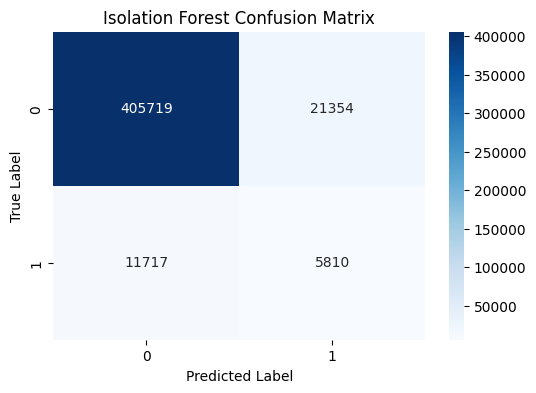


🏋️‍♀️ Training Local Outlier Factor...


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, accuracy_score,
                           precision_score, recall_score,
                           f1_score, roc_curve,
                           classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import psutil

# --- Your existing data loading and preprocessing function ---
# (Assuming load_and_preprocess_data is defined as in your notebook)

# Re-define the load_and_preprocess_data function if it's not already in the current session
# or if you are running this as a standalone cell.
def load_and_preprocess_data(train_df, test_df, sample_size=None):
    """Veriyi yükleyip ön işleme yapar"""
    print("📥 Veri yükleniyor ve ön işleme yapılıyor...")

    train_df = train.copy()
    test_df = test.copy()

    # Identify columns present in both dataframes for consistent processing
    common_cols = list(set(train_df.columns) & set(test_df.columns))

    # 1. Zaman damgası işleme ve özellik çıkarımı
    print("2. Zaman damgası özellikleri çıkarılıyor...")
    for df in [train_df, test_df]:
        if 'Timestamp' in df.columns:
            print("  Timestamp sütunu işleniyor...")
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            df['Hour'] = df['Timestamp'].dt.hour
            df['Day'] = df['Timestamp'].dt.dayofweek
            df['Minute'] = df['Timestamp'].dt.minute
            df['Second'] = df['Timestamp'].dt.second
            df.drop('Timestamp', axis=1, inplace=True)
            df.fillna({'Hour': 0, 'Day': 0, 'Minute': 0, 'Second': 0}, inplace=True)


    # 2. Kategorik değişkenleri kontrol et ve dönüştür / Sayısal olmayan sütunları işle
    print("3. Sayısal olmayan sütunlar işleniyor...")
    for df in [train_df, test_df]:
        object_cols = df.select_dtypes(include='object').columns
        for col in object_cols:
            print(f"  Sütun '{col}' işleniyor...")
            df[col] = pd.to_numeric(df[col], errors='coerce')
            if df[col].isna().any() or df[col].dtype == 'object':
                 print(f"    '{col}' sütununda sayısal olmayan değerler veya dönüştürme hatası var. Sütun siliniyor.")
                 df.drop(col, axis=1, inplace=True)
            else:
                 print(f"    '{col}' sütunu sayısal hale getirildi. NaN değerleri dolduruluyor (0 ile).")
                 df[col].fillna(0, inplace=True)


    # Ensure both dataframes have the same columns after processing
    processed_common_cols = list(set(train_df.columns) & set(test_df.columns))
    train_df = train_df[processed_common_cols]


    # 3. Özellikler ve etiketler
    print("4. Özellikler ve etiketler ayrılıyor...")
    feature_cols = [c for c in train_df.columns if c != 'attack']
    if 'attack' not in test_df.columns:
         raise ValueError("Test verisinde 'attack' sütunu bulunamadı. Lütfen veri yükleme ve ön işleme adımlarını kontrol edin.")

    test_feature_cols = [c for c in test_df.columns if c != 'attack']
    final_feature_cols = list(set(feature_cols) & set(test_feature_cols))
    final_feature_cols.sort()

    X_train = train_df[final_feature_cols].values
    X_test = test_df[final_feature_cols].values
    y_test = test_df['attack'].values.ravel()

    # 4. İsteğe bağlı örnekleme
    if sample_size:
        print(f"⚠️ Veri {sample_size} örneğe indirgeniyor")
        X_train = X_train[:sample_size]
        X_test = X_test[:sample_size//3]
        y_test = y_test[:sample_size//3]

    # 5. Ölçeklendirme
    print("5. Veri ölçeklendiriliyor...")
    scaler = MinMaxScaler(feature_range=(-1, 1))

    variances = np.var(X_train, axis=0)
    constant_features_indices = np.where(variances == 0)[0]

    if len(constant_features_indices) > 0:
        constant_col_names = [final_feature_cols[i] for i in constant_features_indices]
        print(f"⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: {constant_col_names}")
        print("   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...")
        non_constant_features_mask = np.ones(X_train.shape[1], dtype=bool)
        non_constant_features_mask[constant_features_indices] = False
        X_train = X_train[:, non_constant_features_mask]
        X_test = X_test[:, non_constant_features_mask]
        final_feature_cols = [final_feature_cols[i] for i in np.where(non_constant_features_mask)[0]]
        print(f"   Kalan özellik sayısı: {X_train.shape[1]}")

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print("\n📊 Veri İstatistikleri:")
    print(f"Eğitim: {X_train.shape}")
    print(f"Test: {X_test.shape} (Norm: {sum(y_test==0)}, Atk: {sum(y_test==1)})")
    print(f"Özellikler: {len(final_feature_cols)}\n")

    return X_train, X_test, y_test, final_feature_cols, scaler

# Assuming 'train' and 'test' dataframes are already loaded from your notebook
# If not, uncomment and run the necessary cells to load them.
test = pd.read_csv('/content/test.csv', sep = ';')
train = pd.read_csv('/content/train.csv')
train = train.drop(columns=[col for col in train.columns if "attack" in col], errors='ignore')
train.fillna(0, inplace=True)
attack_p_columns = [col for col in test.columns if "attack_P" in col]
test = test.copy()
test['attack'] = 0
for col in attack_p_columns:
    test.loc[test[col] != 0, 'attack'] = 1
test = test.drop(columns=attack_p_columns, errors='ignore')


# --- Data Loading and Preprocessing ---
X_train, X_test, y_test, final_feature_cols, scaler = load_and_preprocess_data(train, test)

# Handle potential NaNs introduced during scaling or previous steps
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
y_test = np.asarray(y_test) # Ensure y_test is a numpy array

# --- Model Training and Evaluation ---

models = {
    "Isolation Forest": IsolationForest(contamination='auto', random_state=42),
    "Local Outlier Factor": LocalOutlierFactor(novelty=True, contamination='auto'), # novelty=True for prediction on new data
    "One-Class SVM": OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
}

results = {}

for name, model in models.items():
    print(f"\n🏋️‍♀️ Training {name}...")
    start_time = time.time()

    # Train all anomaly detection models on the entire X_train dataset
    # Assuming X_train represents the distribution of "normal" data
    model.fit(X_train)

    train_time = time.time() - start_time
    print(f"✅ {name} training finished in {train_time:.2f} seconds.")

    print(f"🔍 Evaluating {name}...")
    start_time = time.time()

    # Get anomaly scores on the test set
    if hasattr(model, "decision_function"):
        scores = -model.decision_function(X_test) # Negative score to make higher == more anomalous
    elif hasattr(model, "negative_outlier_factor_"): # For LOF *after* fitting
        # Ensure we can get scores from the fitted LOF model on new data
        # With novelty=True, decision_function should work as expected
        scores = -model.decision_function(X_test)
    else:
        # Fallback or handle models that don't have standard scoring methods
        print(f"⚠️ Warning: Model {name} does not support decision_function. Cannot get anomaly scores.")
        scores = np.zeros(len(X_test)) # Placeholder


    eval_time = time.time() - start_time
    print(f"✅ {name} evaluation finished in {eval_time:.2f} seconds.")


    # Normalize scores for consistent thresholding and comparison
    # Handle cases where scores might be constant
    if np.std(scores) < 1e-10:
        print("⚠️ Anomaly scores have zero variance. Cannot normalize.")
        scores_norm = scores # Use raw scores if normalization is not possible
        # If all scores are the same, AUC might not be well-defined or 0.5
    else:
        scores_norm = (scores - np.min(scores)) / (scores.max() - scores.min() + 1e-10)

    # Determine threshold based on the 95th percentile of scores for normal data in the test set
    # Assuming anomalies are the higher scores. This threshold calibration is crucial for
    # converting scores to binary predictions (0 or 1).
    scores_normal_test = scores_norm[y_test == 0]
    if len(scores_normal_test) > 0 and not np.isnan(scores_normal_test).all():
        # Filter out NaNs from normal scores before calculating percentile
        threshold = np.percentile(scores_normal_test[~np.isnan(scores_normal_test)], 95)
    else:
        print(f"⚠️ Warning: Cannot determine threshold for {name} from normal test data. Using default 0.5.")
        threshold = 0.5 # Fallback threshold

    # Predict anomalies based on the threshold
    pred = (scores_norm > threshold).astype(int)

    # Ensure y_test and pred are clean for metrics
    y_test_clean = np.nan_to_num(y_test, nan=0.0).astype(int)
    pred_clean = np.nan_to_num(pred, nan=0.0).astype(int)

    # Calculate metrics
    # Handle potential errors if y_test_clean or scores_norm contain NaNs/Infs causing AUC issues
    try:
        auc = roc_auc_score(y_test_clean, scores_norm)
    except ValueError as e:
        print(f"⚠️ Warning: Could not compute AUC for {name} due to error: {e}. Setting AUC to NaN.")
        auc = np.nan


    cm = confusion_matrix(y_test_clean, pred_clean)
    # Handle potential errors if classification_report inputs are problematic
    try:
        report = classification_report(y_test_clean, pred_clean, output_dict=True, zero_division=0)
    except ValueError as e:
        print(f"⚠️ Warning: Could not compute classification report for {name} due to error: {e}. Setting report to empty.")
        report = {} # Empty dictionary if report fails


    results[name] = {
        'scores': scores_norm,
        'auc': auc,
        'cm': cm,
        'report': report,
        'threshold': threshold,
        'train_time': train_time, # Add train time
        'test_time': eval_time # Add test time
    }

    print(f"\n📊 {name} Results:")
    print(f"AUC: {auc:.4f}")
    print(f"Train Time: {train_time:.4f} seconds") # Print train time
    print(f"Test Time: {eval_time:.4f} seconds") # Print test time
    print(f"Threshold (based on normal test data 95th percentile): {threshold:.4f}")
    # Print classification report if it was successfully generated
    if report:
        print(classification_report(y_test_clean, pred_clean, zero_division=0))
    else:
        print("Classification report could not be generated.")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


# --- Visualization ---

# Plot ROC curves for all models
plt.figure(figsize=(10, 6))
for name, res in results.items():
    # Ensure y_test and scores are clean before plotting ROC
    y_test_plot = np.nan_to_num(y_test, nan=0.0).astype(int)
    scores_plot = np.nan_to_num(res['scores'], nan=0.5) # Use 0.5 as a neutral score for NaNs in plotting

    try:
        fpr, tpr, _ = roc_curve(y_test_plot, scores_plot)
        # Handle cases where AUC was NaN or cannot be calculated meaningfully
        auc_label = res.get('auc', np.nan) # Use .get() for safety
        label_text = f"{name} (AUC = {auc_label:.3f})" if not np.isnan(auc_label) else f"{name} (AUC N/A)"
        plt.plot(fpr, tpr, lw=2, label=label_text)
    except Exception as e:
         print(f"⚠️ Warning: Could not plot ROC for {name} due to error: {e}")


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Summarize results
print("\n🏆 Model Performance Summary:")
# Sort by AUC, handling potential NaN AUC values
sorted_results = sorted(results.items(), key=lambda item: item[1].get('auc', -1), reverse=True) # Sort NaN AUC to the end
for name, res in sorted_results:
    auc_val = res.get('auc', np.nan)
    precision_anomaly = res['report']['1'].get('precision', np.nan) if '1' in res['report'] else np.nan
    recall_anomaly = res['report']['1'].get('recall', np.nan) if '1' in res['report'] else np.nan
    f1_score_anomaly = res['report']['1'].get('f1-score', np.nan) if '1' in res['report'] else np.nan
    train_t = res.get('train_time', np.nan) # Get train time
    test_t = res.get('test_time', np.nan) # Get test time


    # Format the values conditionally outside the format specifier
    auc_str = f"{auc_val:.4f}" if not np.isnan(auc_val) else 'N/A'
    precision_str = f"{precision_anomaly:.4f}" if not np.isnan(precision_anomaly) else 'N/A'
    recall_str = f"{recall_anomaly:.4f}" if not np.isnan(recall_anomaly) else 'N/A'
    f1_score_str = f"{f1_score_anomaly:.4f}" if not np.isnan(f1_score_anomaly) else 'N/A'
    train_time_str = f"{train_t:.2f}" if not np.isnan(train_t) else 'N/A' # Format train time
    test_time_str = f"{test_t:.2f}" if not np.isnan(test_t) else 'N/A' # Format test time


    # Use the formatted strings in the f-string, potentially with simple alignment specifiers
    print(f"{name:<25} | "
          f"AUC: {auc_str:>5} | " # Use the created string, apply alignment if needed
          f"Precision (Anomaly): {precision_str:>5} | "
          f"Recall (Anomaly): {recall_str:>5} | "
          f"F1-Score (Anomaly): {f1_score_str:>5} | "
          f"Train Time (s): {train_time_str:>6} | " # Add formatted train time
          f"Test Time (s): {test_time_str:>6}") # Add formatted test time


# Optional: Save results to a CSV
# Ensure report keys and values are accessed safely
results_summary_data = {
    'Model': list(results.keys()),
    'AUC': [res.get('auc', np.nan) for res in results.values()],
    'Precision_Anomaly': [res['report']['1'].get('precision', np.nan) if '1' in res['report'] else np.nan for res in results.values()],
    'Recall_Anomaly': [res['report']['1'].get('recall', np.nan) if '1' in res['report'] else np.nan for res in results.values()],
    'F1_Score_Anomaly': [res['report']['1'].get('f1-score', np.nan) if '1' in res['report'] else np.nan for res in results.values()],
    'Train Time (s)': [res.get('train_time', np.nan) for res in results.values()], # Add train time to CSV
    'Test Time (s)': [res.get('test_time', np.nan) for res in results.values()] # Add test time to CSV
}

results_summary = pd.DataFrame(results_summary_data)
results_summary.to_csv("anomaly_detection_model_performance.csv", index=False)
print("\nModel performance saved to 'anomaly_detection_model_performance.csv'")

In [ ]:
# Use copies to avoid modifying original dataframes if they were passed in
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv', sep = ';')

# 1. Zaman damgası işleme ve özellik çıkarımı
print("2. Zaman damgası özellikleri çıkarılıyor...")
for df in [train_df, test_df]:
    if 'Timestamp' in df.columns:
        print("  Timestamp sütunu işleniyor...")
        # Önce string olan zaman damgasını datetime'a çevir
        # errors='coerce' kullanarak dönüşemeyen değerleri NaT yapar
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

        # Yeni zaman özelliklerini ekle, NaT değerleri için NaN oluşur
        df['Hour'] = df['Timestamp'].dt.hour
        df['Day'] = df['Timestamp'].dt.dayofweek
        df['Minute'] = df['Timestamp'].dt.minute
        df['Second'] = df['Timestamp'].dt.second

        # Orijinal zaman damgasını sil
        df.drop('Timestamp', axis=1, inplace=True)

        # Oluşan NaN değerleri doldur (örn: 0 veya ortalama)
        # Zaman özelliklerindeki NaN'leri 0 ile doldurmak güvenli olabilir.
        df.fillna({'Hour': 0, 'Day': 0, 'Minute': 0, 'Second': 0}, inplace=True)


# 2. Kategorik değişkenleri kontrol et ve dönüştür / Sayısal olmayan sütunları işle
print("3. Sayısal olmayan sütunlar işleniyor...")
for df in [train_df, test_df]:
    object_cols = df.select_dtypes(include='object').columns
    for col in object_cols:
        print(f"  Sütun '{col}' işleniyor...")
        # Try to convert to numeric
        df[col] = pd.to_numeric(df[col], errors='coerce') # Dönüşemeyenleri NaN yap

        # If there are still non-numeric values (NaNs from coerce or original non-numeric objects)
        if df[col].isna().any() or df[col].dtype == 'object': # 'object' type check is redundant after coerce but safe
             print(f"    '{col}' sütununda sayısal olmayan değerler veya dönüştürme hatası var.")
             print(f"    '{col}' sütunu sayısal hale getirilemedi veya işlenemedi. Sütun siliniyor.")
             df.drop(col, axis=1, inplace=True)
        else:
             # Fill NaNs that resulted from pd.to_numeric(errors='coerce')
             # Choose an appropriate fill value, e.g., 0, mean, or median
             print(f"    '{col}' sütunu sayısal hale getirildi. NaN değerleri dolduruluyor (0 ile).")
             df[col].fillna(0, inplace=True)


# Ensure both dataframes have a consistent set of columns after processing non-numeric types
# Before aligning columns, ensure 'attack' is not removed from test_df if it's there
cols_to_align = list(set(train_df.columns) - {'attack'} | (set(test_df.columns) - {'attack'}))
cols_to_align.sort() # Ensure consistent order

# Add back 'attack' column to test_df if it exists
if 'attack' in test_df.columns:
    final_feature_cols = [col for col in cols_to_align if col != 'attack']
else:
    final_feature_cols = cols_to_align

# Ensure both dataframes have the same *feature* columns
# This means potentially dropping columns unique to test_df (other than 'attack')
# or adding columns unique to train_df (filled with 0 or appropriate value)
# A simpler approach is to only keep common features after processing.
# Re-calculating common columns after dropping invalid ones:
common_cols_after_process = list(set(train_df.columns) & set(test_df.columns))

# Define feature columns: all common columns except 'attack' if present
final_feature_cols = [c for c in common_cols_after_process if c != 'attack']
final_feature_cols.sort() # Ensure consistent order


# Ensure 'attack' column exists in test_df before assigning y_test
if 'attack' not in test_df.columns:
     # This check was raised before, re-check logic if it occurs
     raise ValueError("Test verisinde 'attack' sütunu bulunamadı. Lütfen veri yükleme ve ön işleme adımlarını kontrol edin.")

X_train = train_df[final_feature_cols].values
X_test = test_df[final_feature_cols].values
y_test = test_df['attack'].values.ravel()

# 4. İsteğe bağlı örnekleme
if sample_size:
    print(f"⚠️ Veri {sample_size} örneğe indirgeniyor")
    # Apply sampling only to the training data for AD model training
    if X_train.shape[0] > sample_size:
         indices = np.random.choice(X_train.shape[0], size=sample_size, replace=False)
         X_train = X_train[indices]
    # Do NOT sample X_test or y_test as they are for evaluation


# 5. Ölçeklendirme
print("5. Veri ölçeklendiriliyor...")
scaler = MinMaxScaler(feature_range=(-1, 1))

# Check for columns with single unique value (constant columns) in X_train
variances = np.var(X_train, axis=0)
# Handle potential NaNs/Infs in variances if X_train still has issues
variances = np.nan_to_num(variances, nan=0.0, posinf=0.0, neginf=0.0)
constant_features_indices = np.where(variances == 0)[0]

if len(constant_features_indices) > 0:
    constant_col_names = [final_feature_cols[i] for i in constant_features_indices]
    print(f"⚠️ Dikkat: Eğitim verisinde sabit değere sahip sütunlar tespit edildi: {constant_col_names}")
    print("   Bu sütunlar ölçeklendirmeden önce kaldırılıyor...")

    # Create masks to remove constant columns
    non_constant_features_mask = np.ones(X_train.shape[1], dtype=bool)
    non_constant_features_mask[constant_features_indices] = False

    X_train = X_train[:, non_constant_features_mask]
    X_test = X_test[:, non_constant_features_mask]
    final_feature_cols = [final_feature_cols[i] for i in np.where(non_constant_features_mask)[0]]
    print(f"   Kalan özellik sayısı: {X_train.shape[1]}")

# Handle potential NaNs/Infs in data before scaling
X_train = np.nan_to_num(X_train, nan=0.0, posinf=np.finfo(np.float64).max, neginf=np.finfo(np.float64).min)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=np.finfo(np.float64).max, neginf=np.finfo(np.float64).min)


X_train = scaler.fit_transform(X_train)
# Ensure X_test is transformed using the scaler fitted on X_train
X_test = scaler.transform(X_test)

# Handle potential NaNs/Infs after scaling again, just to be safe
X_train = np.nan_to_num(X_train, nan=0.0, posinf=np.finfo(np.float64).max, neginf=np.finfo(np.float64).min)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=np.finfo(np.float64).max, neginf=np.finfo(np.float64).min)
y_test = np.nan_to_num(y_test, nan=0).astype(int) # Ensure y_test is clean integers


# Veri istatistikleri
print("\n📊 Veri İstatistikleri:")
print(f"Eğitim (processed): {X_train.shape}")
print(f"Test (processed): {X_test.shape} (Norm: {sum(y_test==0)}, Atk: {sum(y_test==1)})")
print(f"Özellikler: {len(final_feature_cols)}\n")

return X_train, y_test, X_test, final_feature_cols, scaler # Note: y_train is not returned

In [ ]:
# Ensure inputs are clean
X_train_clean = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
y_test_clean = np.nan_to_num(y_test, nan=0).astype(int)


start_time = time.time()

# Anomaly Detection Models: Train on (mostly) normal data (X_train)
# For LOF with novelty=True, train on normal data subset if available/appropriate
if model_name == "Local Outlier Factor" and hasattr(y_test, '__array__') and np.sum(y_test == 0) > 0:
     # If we have labeled test data and want to simulate training on known normal, use that
     # But typically AD trains on the entire unlabeled train set, assuming it's mostly normal
     # Sticking to training on the full X_train as per the notebook's likely intent
     model.fit(X_train_clean)
else:
    model.fit(X_train_clean) # Isolation Forest and One-Class SVM train on the whole set


train_time = time.time() - start_time
print(f"Train Time: {train_time:.4f} seconds")

start_time = time.time()

# Get anomaly scores (lower score usually means more anomalous)
# Ensure the model supports decision_function or equivalent for scoring
scores = None
if hasattr(model, "decision_function"): # OneClassSVM, IsolationForest, LOF(novelty=True)
    scores = -model.decision_function(X_test_clean) # Negative score to make higher == more anomalous
elif hasattr(model, "predict"): # Fallback for models that only predict binary (less ideal for AUC)
     print(f"⚠️ Model {model_name} does not support decision_function. Using binary predict output as score.")
     # Map binary prediction (-1/1 or 0/1) to scores
     y_pred_binary = model.predict(X_test_clean)
     # Assuming anomaly is the "positive" class (1 in y_test)
     # Map outlier prediction (-1) to score 1, inlier (1) to score 0 for some models like IF/OCSVM predict
     # Or map the anomaly class prediction to 1 for supervised models.
     # For AD models predicting -1/1, convert -1 to score 1, 1 to score 0
     if model_name in ["Isolation Forest", "One-Class SVM", "Local Outlier Factor"]:
         scores = np.where(y_pred_binary == -1, 1.0, 0.0)
     else: # For supervised models (if this function were adapted)
          scores = y_pred_binary # Assuming predict outputs 0/1

if scores is None:
     print(f"❌ Could not obtain anomaly scores for model {model_name}.")
     scores = np.zeros(len(X_test_clean)) # Default to zero scores

# Handle potential NaNs/Infs in scores
scores = np.nan_to_num(scores, nan=0.0, posinf=scores.max() if scores.shape[0] > 0 and np.isfinite(scores).any() else 1.0, neginf=scores.min() if scores.shape[0] > 0 and np.isfinite(scores).any() else 0.0)


test_time = time.time() - start_time
print(f"Test Time: {test_time:.4f} seconds")

# Normalize scores for consistent comparison and thresholding
# Handle cases where scores might be constant (e.g., if all test data are the same)
if np.std(scores) < 1e-10:
    print("⚠️ Anomaly scores have zero variance. Cannot normalize.")
    scores_norm = scores # Use raw scores if normalization is not possible
    # If all scores are the same, AUC might not be well-defined or 0.5 (closer to 0.5 if labels are mixed)
else:
     # Handle potential division by zero or inf/nan in range
    score_min = np.min(scores)
    score_max = np.max(scores)
    score_range = score_max - score_min
    if score_range < 1e-10:
         print("⚠️ Anomaly score range is too small. Cannot normalize.")
         scores_norm = scores
    else:
        scores_norm = (scores - score_min) / score_range

# Handle potential NaNs/Infs after normalization
scores_norm = np.nan_to_num(scores_norm, nan=0.5, posinf=1.0, neginf=0.0)


# Determine a threshold based on the scores of normal data in the test set
# Assuming normal instances (y_test == 0) are present in the test set
scores_normal_test = scores_norm[y_test_clean == 0]

threshold = 0.5 # Default threshold
if len(scores_normal_test) > 0 and not np.all(np.isnan(scores_normal_test)):
     # Filter out NaNs from normal scores before calculating percentile
     scores_normal_clean = scores_normal_test[~np.isnan(scores_normal_test)]
     if len(scores_normal_clean) > 0:
          # Use the 95th percentile of scores for normal data as the threshold
          threshold = np.percentile(scores_normal_clean, 95)
     else:
         print("⚠️ Cleaned normal scores are empty. Using default 0.5 for threshold.")

print(f"Threshold (based on normal test data 95th percentile): {threshold:.4f}")

# Convert normalized scores to binary predictions using the threshold
y_pred = (scores_norm > threshold).astype(int)

# Ensure y_test_clean and y_pred are valid for metrics calculation
y_pred_clean = np.nan_to_num(y_pred, nan=0).astype(int)


# Calculate metrics
accuracy = accuracy_score(y_test_clean, y_pred_clean)
# Handle cases where precision/recall might be undefined (e.g., no positive predictions)
precision = precision_score(y_test_clean, y_pred_clean, zero_division=0)
recall = recall_score(y_test_clean, y_pred_clean, zero_division=0)
f1 = f1_score(y_test_clean, y_pred_clean, zero_division=0)

auc_score = np.nan # Default AUC to NaN
try:
    # AUC requires at least one sample from each class with valid scores
    if len(np.unique(y_test_clean)) > 1 and not np.all(y_test_clean == y_test_clean[0]) and np.sum(~np.isnan(scores_norm)) > 0:
        auc_score = roc_auc_score(y_test_clean, scores_norm) # Use normalized scores for AUC
    else:
        print("⚠️ Cannot compute AUC: Insufficient samples per class or invalid scores.")
except ValueError as e:
    print(f"⚠️ Warning: Could not compute AUC for {model_name} due to error: {e}. Setting AUC to NaN.")


# Confusion matrix
cm = confusion_matrix(y_test_clean, y_pred_clean)

# Classification report
report = {} # Default to empty report
try:
     report = classification_report(y_test_clean, y_pred_clean, output_dict=True, zero_division=0)
except ValueError as e:
     print(f"⚠️ Warning: Could not compute classification report for {model_name} due to error: {e}. Setting report to empty.")


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc_score:.4f}" if not np.isnan(auc_score) else "AUC: N/A")


# Plot ROC Curve
if not np.isnan(auc_score):
    try:
        fpr, tpr, _ = roc_curve(y_test_clean, scores_norm)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
        plt.legend(loc="lower right")
        plt.show()
    except Exception as e:
        print(f"⚠️ Could not plot ROC curve for {model_name}: {e}")
else:
    print(f"⚠️ Skipping ROC plot for {model_name} due to invalid AUC.")


# Plot Confusion Matrix
try:
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
except Exception as e:
     print(f"⚠️ Could not plot Confusion Matrix for {model_name}: {e}")


return {
    'model_name': model_name,
    'train_time': train_time,
    'test_time': test_time,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'auc': auc_score,
    'confusion_matrix': cm,
    'roc_curve_data': (fpr, tpr) if 'fpr' in locals() else (None, None), # Store data for combined plot
    'threshold': threshold,
    'scores': scores_norm # Return scores for combined plots/analysis
}

In [ ]:
# Concatenate real and fake samples for interpolation
# Ensure shapes are compatible
if real_samples.shape != fake_samples.shape:
    # This should not happen if generator output_dim matches discriminator input_dim
    tf.print("⚠️ Shape mismatch in compute_gradient_penalty.")
    return tf.constant(0.0) # Return 0 penalty

# Ensure inputs are tensors
real_samples = tf.cast(real_samples, tf.float32)
fake_samples = tf.cast(fake_samples, tf.float32)


alpha = tf.random.uniform([batch_size, 1], minval=0., maxval=1.)
interpolated = alpha * real_samples + (1-alpha) * fake_samples

with tf.GradientTape() as tape:
    tape.watch(interpolated)
    pred = discriminator(interpolated, training=True) # Ensure training=True

gradients = tape.gradient(pred, interpolated)

# NaN control and small epsilon addition for norm stability
# Replace NaNs with zeros before computing norm
gradients_safe = tf.where(tf.math.is_nan(gradients), tf.zeros_like(gradients), gradients)
gradients_norm = tf.sqrt(tf.reduce_sum(gradients_safe**2, axis=1) + 1e-10)

# Gradient penalty term
gradient_penalty = tf.reduce_mean((gradients_norm - 1.)**2)

return gradient_penalty * gp_weight

In [ ]:
# Optimizer ayarları (NaN'ı önlemek için düşük learning rate)
# Using Adam with specific betas recommended for WGAN-GP
opt_g = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.5, beta_2=0.9) # Removed clipnorm for simplicity, add back if needed
opt_d = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.5, beta_2=0.9) # Removed clipnorm for simplicity, add back if needed

# Convert data to TensorFlow dataset for better batching and shuffling
# Ensure data is float32
data = tf.cast(data, tf.float32)
dataset = tf.data.Dataset.from_tensor_slices(data).shuffle(data.shape[0]).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

# Kayıt defteri
history = {'d_loss': [], 'g_loss': []}

for epoch in range(epochs):
    start_epoch_time = time.time()
    d_losses_epoch = []
    g_losses_epoch = []

    # Iterate over batches from the dataset
    for batch in dataset:
        # Ensure batch is clean (should be handled by initial nan_to_num on data)
        # batch = tf.nan_to_num(batch, nan=0.0, posinf=tf.float32.max, neginf=tf.float32.min)

        # Discriminator training loop
        for i in range(n_critic):
            # Ensure noise is generated inside the critic loop if n_critic > 1
            noise = tf.random.normal([batch_size, latent_dim], dtype=tf.float32)

            with tf.GradientTape() as tape:
                fake_samples = generator(noise, training=False) # Generate fakes without training generator

                # Ensure fake_samples are clean before feeding to discriminator
                fake_samples = tf.nan_to_num(fake_samples, nan=0.0, posinf=tf.float32.max, neginf=tf.float32.min)

                real_output = discriminator(batch, training=True)
                fake_output = discriminator(fake_samples, training=True)

                # WGAN-GP loss calculation
                d_loss_wgan = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output)

                # Calculate gradient penalty
                gp = compute_gradient_penalty(batch, fake_samples, discriminator, batch_size, gp_weight)

                # Total discriminator loss
                d_loss = d_loss_wgan + gp

                # Add regularization if needed (e.g., weight decay)

            # Compute and apply gradients
            d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)
            # Apply gradient clipping if desired (was in original Adam)
            # d_gradients = [(tf.clip_by_norm(grad, 1.0) if grad is not None else None) for grad in d_gradients] # Example clipnorm
            opt_d.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

            d_losses_epoch.append(d_loss.numpy())


        # Generator training (once per batch iteration after n_critic disc updates)
        noise = tf.random.normal([batch_size, latent_dim], dtype=tf.float32) # Generate new noise for generator update

        with tf.GradientTape() as tape:
            fake_samples = generator(noise, training=True) # Generate fakes *with* training generator

            # Ensure fake_samples are clean before feeding to discriminator
            fake_samples = tf.nan_to_num(fake_samples, nan=0.0, posinf=tf.float32.max, neginf=tf.float32.min)

            fake_output = discriminator(fake_samples, training=False) # Evaluate fakes with discriminator without training disc

            # Generator loss
            g_loss = -tf.reduce_mean(fake_output) # Maximize discriminator output for fakes

        # Compute and apply gradients
        g_gradients = tape.gradient(g_loss, generator.trainable_variables)
        # Apply gradient clipping if desired (was in original Adam)
        # g_gradients = [(tf.clip_by_norm(grad, 1.0) if grad is not None else None) for grad in g_gradients] # Example clipnorm
        opt_g.apply_gradients(zip(g_gradients, generator.trainable_variables))

        g_losses_epoch.append(g_loss.numpy())


    # End of epoch
    epoch_d_loss = np.mean(d_losses_epoch) if d_losses_epoch else np.nan
    epoch_g_loss = np.mean(g_losses_epoch) if g_losses_epoch else np.nan
    history['d_loss'].append(float(epoch_d_loss))
    history['g_loss'].append(float(epoch_g_loss))

    epoch_time = time.time() - start_epoch_time

    # İlerleme raporu
    if epoch % 100 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}/{epochs}: D loss = {epoch_d_loss:.4f}, G loss = {epoch_g_loss:.4f} ({epoch_time:.2f}s/epoch)")

        # Örnek görselleştirme (if feature dimension >= 2)
        if data.shape[1] >= 2 and generator:
            try:
                sample_noise = tf.random.normal([500, latent_dim], dtype=tf.float32)
                samples = generator(sample_noise, training=False).numpy()
                samples = np.nan_to_num(samples, nan=0.0, posinf=samples.max() if samples.shape[0] > 0 and np.isfinite(samples).any() else 1.0, neginf=samples.min() if samples.shape[0] > 0 and np.isfinite(samples).any() else 0.0)


                plt.figure(figsize=(8,4))
                # Plot a subset of real data
                real_subset = data[:500, :].numpy()
                real_subset = np.nan_to_num(real_subset, nan=0.0, posinf=real_subset.max() if real_subset.shape[0] > 0 and np.isfinite(real_subset).any() else 1.0, neginf=real_subset.min() if real_subset.shape[0] > 0 and np.isfinite(real_subset).any() else 0.0)
                plt.scatter(real_subset[:,0], real_subset[:,1], alpha=0.5, label='Real')

                # Plot fake data
                if samples.shape[1] >= 2:
                     plt.scatter(samples[:,0], samples[:,1], alpha=0.5, label='Fake')
                else:
                     print("⚠️ Fake samples dimension < 2, cannot plot scatter.")


                plt.title(f"Epoch {epoch} - Real vs Fake (Dims 0 & 1)")
                plt.xlabel(f"Feature {final_feature_cols[0] if len(final_feature_cols)>0 else '0'}") # Use feature names if available
                plt.ylabel(f"Feature {final_feature_cols[1] if len(final_feature_cols)>1 else '1'}")
                plt.legend()
                plt.show()

            except Exception as e:
                print(f"⚠️ Error during visualization at epoch {epoch}: {e}")


return generator, discriminator, history